# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

## Use LaTeX font.
# plt.rc('text', usetex=True)
# plt.rc('font',**{'family':'serif','serif':['DejaVu Serif'],'size':20})
# Use LaTeX-like font, but do NOT use external LaTeX
plt.rc('text', usetex=False)
plt.rc('font', **{
    'family': 'serif',
    'serif': ['DejaVu Serif'],
    'size': 20
})
plt.rcParams['mathtext.fontset'] = 'dejavuserif'


import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)
Q2plot=1000

In [2]:
## Dipole FF
Lambda2 = 0.71
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2

GEp0 = 1
GMp0 = 2.792847356
GEn0 = 1.0 #should be zero but we normalized to GD so I set it to be 1
GMn0 = -1.91304272
Mass_p = 0.938272
Mass_n = 0.939566

In [3]:
Q2_max= 50
Q2_min = 1e-2

# Load 2017 Proton World+Pol+Mainz Sum-Rules Fitting Results (set 1)

In [4]:
##Load Q2max=1000 Fitting results#{{{
filename='./plotdata/proton_lookup.dat'
# filename='out_org_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat'

if os.path.isfile(filename):
    print('file exist', filename)

fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2 = np.zeros(N, dtype=float)
# Z = np.zeros(N, dtype=float)
GE_fit = np.zeros(N, dtype=float)
GE_pos = np.zeros(N, dtype=float)
GE_neg = np.zeros(N, dtype=float)
GM_fit = np.zeros(N, dtype=float)
GM_pos = np.zeros(N, dtype=float)
GM_neg = np.zeros(N, dtype=float)
GE_fit_rat = np.zeros(N, dtype=float)
GE_pos_rat = np.zeros(N, dtype=float)
GE_neg_rat = np.zeros(N, dtype=float)
GM_fit_rat = np.zeros(N, dtype=float)
GM_pos_rat = np.zeros(N, dtype=float)
GM_neg_rat = np.zeros(N, dtype=float)
GEGM_fit_rat = np.zeros(N, dtype=float)
GEGM_pos_rat = np.zeros(N, dtype=float)
GEGM_neg_rat = np.zeros(N, dtype=float)
GE_err_rat = np.zeros(N, dtype=float)
GM_err_rat = np.zeros(N, dtype=float)
GEGM_err = np.zeros(N, dtype=float)
GEd = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)

dGEGD = np.zeros(N, dtype=float)
dGMGD = np.zeros(N, dtype=float)
dGEGM = np.zeros(N, dtype=float)

from GetFF import *

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2[i]=float(values[0])
#    Z[i]=float(values[1])
    GE_fit_rat[i]=float(values[1])
    GE_err_rat[i] = abs(float(values[2]) ) #/ abs(float(values[2]))
    dGEGD[i] = abs(float(values[3]) )
    GM_fit_rat[i]=float(values[4])
    GM_err_rat[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    dGMGD[i] = abs(float(values[6]) )  
       
    GE_fit_rat[i], dGEGD[i] = GetFF(1, Q2[i]) 
    GM_fit_rat[i], dGMGD[i] = GetFF(2, Q2[i]) 
        
    #dGEGD[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp5, c_GEp5, d_GEp5, L_GEp5 ) 
    #dGMGD[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp5, c_GMp5, d_GMp5, L_GMp5 ) 
    #dGEGD[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp, c_GEp, d_GEp, L_GEp ) / abs(GEp0)
    #dGMGD[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp, c_GMp, d_GMp, L_GMp ) / abs(GMp0)
    
    GE_pos_rat[i] = GE_fit_rat[i] + GE_err_rat[i]
    GE_neg_rat[i] = GE_fit_rat[i] - GE_err_rat[i]
    GM_pos_rat[i] = GM_fit_rat[i] + GM_err_rat[i]
    GM_neg_rat[i] = GM_fit_rat[i] - GM_err_rat[i]
    
    GEd[i] = GD(Q2[i]) * GEp0
    GMd[i] = GD(Q2[i]) * GMp0
    
    GE_fit[i]=GE_fit_rat[i] * GEd[i]
    GM_fit[i]=GM_fit_rat[i] * GMd[i]
    GE_pos[i] = GE_fit[i] + dGEGD[i]* GEd[i]
    GE_neg[i] = GE_fit[i] - dGEGD[i]* GEd[i]  
    GM_pos[i] = GM_fit[i] + dGMGD[i]* GMd[i]
    GM_neg[i] = GM_fit[i] - dGMGD[i]* GMd[i]
   
    GEGM_fit_rat[i] = GE_fit_rat[i] / GM_fit_rat[i]
    GEGM_err[i] = GEGM_fit_rat[i]* sqrt((GE_err_rat[i]/GE_fit_rat[i])**2 + (GM_err_rat[i]/GM_fit_rat[i])**2)    
    dGEGM[i] = GEGM_fit_rat[i] * sqrt( (dGEGD[i]/GE_fit_rat[i])**2 + (dGMGD[i]/GM_fit_rat[i])**2 )
    GEGM_pos_rat[i] = GEGM_fit_rat[i]+abs(GEGM_err[i])
    GEGM_neg_rat[i] = GEGM_fit_rat[i]-abs(GEGM_err[i])

#     if (GEGM_fit_rat[i]<0):
#         GEGM_pos_rat[i] = GEGM_fit_rat[i]-GEGM_err[i]
#         GEGM_neg_rat[i] = GEGM_fit_rat[i]+GEGM_err[i]
#         dGEGM_pos[i] = GEGM_fit_rat[i]-dGEGM[i]
#         dGEGM_neg[i] = GEGM_fit_rat[i]+dGEGM[i]    
        
print(dGEGD) 
print(dGMGD)       
tcut=0.0779191396
t0 = -0.7

file exist ./plotdata/proton_lookup.dat
[1.09933651e-07 1.11204844e-07 1.12486950e-07 ... 5.33124176e+00
 5.34792751e+00 5.36463140e+00]
[2.15240439e-07 2.17729925e-07 2.20240787e-07 ... 2.76092140e+00
 2.76995487e+00 2.77899897e+00]


# Load New World Proton Fitting Results by Prof. Ye. (set 1 without cali)

In [5]:
# Load New world fitting results without corrections
# filename='./plotdata/final_fit_SBS/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat' #Prof. Ye's Fitting results without PRad data
filename='./plotdata/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_Gp.dat' #Prof. Ye's Fitting results without PRad data
if os.path.isfile(filename):
    print('file exist', filename)

fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_new = np.zeros(N, dtype=float)
Z = np.zeros(N, dtype=float)
GE_fit_new = np.zeros(N, dtype=float) #GEp
GE_pos_new = np.zeros(N, dtype=float) 
GE_neg_new = np.zeros(N, dtype=float)
GM_fit_new = np.zeros(N, dtype=float) #GMp
GM_pos_new = np.zeros(N, dtype=float)
GM_neg_new = np.zeros(N, dtype=float)
GE_fit_rat_new = np.zeros(N, dtype=float) #GEp/GD
GE_pos_rat_new = np.zeros(N, dtype=float)
GE_neg_rat_new = np.zeros(N, dtype=float)
GM_fit_rat_new = np.zeros(N, dtype=float) #GMp/mupGD
GM_pos_rat_new = np.zeros(N, dtype=float)
GM_neg_rat_new = np.zeros(N, dtype=float)
GEGM_fit_rat_new = np.zeros(N, dtype=float) #mupGEp/GMp
GEGM_pos_rat_new = np.zeros(N, dtype=float)
GEGM_neg_rat_new = np.zeros(N, dtype=float)
GE_err_new = np.zeros(N, dtype=float) #d(GEp)
GM_err_new = np.zeros(N, dtype=float) #d(GMp)
GE_err_rat_new = np.zeros(N, dtype=float) #d(GEp/GD)
GM_err_rat_new = np.zeros(N, dtype=float) #d(GMp/mupGD)
GEGM_err_new = np.zeros(N, dtype=float) #d(mupGEp/GMp)
GEd_new = np.zeros(N, dtype=float) #GD*GEp(0)=GD
GMd_new = np.zeros(N, dtype=float) #GD*GM(0)=GD*mup

dGEGD_new = np.zeros(N, dtype=float) #delta(GEp/GD), dGEGD * GEd = GE_err
dGMGD_new = np.zeros(N, dtype=float) # dGMGD * GMd = GM_err
dGEGM_new = np.zeros(N, dtype=float) # dGEGM = GEGM_fit_rat*sqrt((dGEGD/GE_fit_rat)**2 + (dGMGD/GM_fit_rat)**2)

for i in range(0, N):
    values = fitlines[i + 3].split()
           
    Q2_new[i]=float(values[0])
    Z[i]=float(values[1])
    GE_fit_new[i]=float(values[2])
    GE_err_new[i] = abs(float(values[3]) ) 
    GM_fit_new[i]=float(values[4])
    GM_err_new[i] = abs(float(values[5]) ) 
    GE_fit_rat_new[i]=float(values[6])
    GE_err_rat_new[i]=abs(float(values[7]) )
    GM_fit_rat_new[i]=float(values[8])
    GM_err_rat_new[i]=abs(float(values[9]) )
    GEGM_fit_rat_new[i]=float(values[10])
    GEGM_err_new[i]=abs(float(values[11]) )
       
    
    GE_pos_rat_new[i] = GE_fit_rat_new[i] + GE_err_rat_new[i]
    GE_neg_rat_new[i] = GE_fit_rat_new[i] - GE_err_rat_new[i]
    GM_pos_rat_new[i] = GM_fit_rat_new[i] + GM_err_rat_new[i]
    GM_neg_rat_new[i] = GM_fit_rat_new[i] - GM_err_rat_new[i]
    
    GEd_new[i] = GD(Q2[i]) * GEp0
    GMd_new[i] = GD(Q2[i]) * GMp0
    
    GE_pos_new[i] = GE_fit_new[i] + GE_err_new[i]
    GE_neg_new[i] = GE_fit_new[i] - GE_err_new[i]
    GM_pos_new[i] = GM_fit_new[i] + GM_err_new[i]
    GM_neg_new[i] = GM_fit_new[i] - GM_err_new[i]
   

    GEGM_pos_rat_new[i] = GEGM_fit_rat_new[i]+GEGM_err_new[i]
    GEGM_neg_rat_new[i] = GEGM_fit_rat_new[i]-GEGM_err_new[i]

        


file exist ./plotdata/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_Gp.dat


# Load Proton org+SBS Fitting Results by Haocen (set 3)

In [6]:
## Load Q2max=1000 SBS fitting results (keep original arrays + add calibrated arrays)#{{{
filename = './plotdata/final_fit_SBS/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_SBS.dat'  # SBS fit output table

if os.path.isfile(filename):
    print('file exist', filename)

fitlines = open(filename, 'r').readlines()

N = 2000

# ----------------------------
# Original arrays (values are read from the .dat file)
# ----------------------------
Q2_SBS = np.zeros(N, dtype=float)                 # Q^2 [GeV^2]
Z_SBS  = np.zeros(N, dtype=float)                

GE_fit_SBS = np.zeros(N, dtype=float)             # G_E^p(Q^2)
GE_pos_SBS = np.zeros(N, dtype=float)             # G_E^p(Q^2) + dG_E^p
GE_neg_SBS = np.zeros(N, dtype=float)             # G_E^p(Q^2) - dG_E^p

GM_fit_SBS = np.zeros(N, dtype=float)             # G_M^p(Q^2)
GM_pos_SBS = np.zeros(N, dtype=float)             # G_M^p(Q^2) + dG_M^p
GM_neg_SBS = np.zeros(N, dtype=float)             # G_M^p(Q^2) - dG_M^p

GE_fit_rat_SBS = np.zeros(N, dtype=float)         # G_E^p / (G_E^p(0)*G_D)
GE_pos_rat_SBS = np.zeros(N, dtype=float)         
GE_neg_rat_SBS = np.zeros(N, dtype=float)         

GM_fit_rat_SBS = np.zeros(N, dtype=float)         # G_M^p / (G_M^p(0)*G_D)
GM_pos_rat_SBS = np.zeros(N, dtype=float)         
GM_neg_rat_SBS = np.zeros(N, dtype=float)         

GEGM_fit_rat_SBS = np.zeros(N, dtype=float)       # (G_E^p/(G_E^p(0)G_D)) / (G_M^p/(G_M^p(0)G_D))
GEGM_pos_rat_SBS = np.zeros(N, dtype=float)       
GEGM_neg_rat_SBS = np.zeros(N, dtype=float)       

GE_err_SBS = np.zeros(N, dtype=float)             # dG_E^p(Q^2)
GM_err_SBS = np.zeros(N, dtype=float)             # dG_M^p(Q^2)

GE_err_rat_SBS = np.zeros(N, dtype=float)         # d[ G_E^p/(G_E^p(0)G_D) ] from table
GM_err_rat_SBS = np.zeros(N, dtype=float)         # d[ G_M^p/(G_M^p(0)G_D) ] from table

GEGM_err_SBS = np.zeros(N, dtype=float)           # d[GE/GM ratio] from table

GEd_SBS = np.zeros(N, dtype=float)                # G_E^p(0)*G_D(Q^2) = G_D(Q^2)
GMd_SBS = np.zeros(N, dtype=float)                # G_M^p(0)*G_D(Q^2) = mu_p*G_D(Q^2)


# ----------------------------
# Calibrated arrays (computed with GetFF)
# ----------------------------
GE_fit_SBS_cali = np.zeros(N, dtype=float)        # Calibrated G_E^p(Q^2)
GE_pos_SBS_cali = np.zeros(N, dtype=float)        # Calibrated G_E^p(Q^2) + dG_E^p
GE_neg_SBS_cali = np.zeros(N, dtype=float)        # Calibrated G_E^p(Q^2) - dG_E^p

GM_fit_SBS_cali = np.zeros(N, dtype=float)        # Calibrated G_M^p(Q^2)
GM_pos_SBS_cali = np.zeros(N, dtype=float)        # Calibrated G_M^p(Q^2) + dG_M^p
GM_neg_SBS_cali = np.zeros(N, dtype=float)        # Calibrated G_M^p(Q^2) - dG_M^p

GE_fit_rat_SBS_cali = np.zeros(N, dtype=float)    # Calibrated G_E^p/(G_E^p(0)G_D)
GE_pos_rat_SBS_cali = np.zeros(N, dtype=float)    # central + d[ratio]
GE_neg_rat_SBS_cali = np.zeros(N, dtype=float)    # central - d[ratio]

GM_fit_rat_SBS_cali = np.zeros(N, dtype=float)    # Calibrated G_M^p/(G_M^p(0)G_D)
GM_pos_rat_SBS_cali = np.zeros(N, dtype=float)    # central + d[ratio]
GM_neg_rat_SBS_cali = np.zeros(N, dtype=float)    # central - d[ratio]

GE_err_SBS_cali = np.zeros(N, dtype=float)        # Calibrated dG_E^p(Q^2)
GM_err_SBS_cali = np.zeros(N, dtype=float)        # Calibrated dG_M^p(Q^2)

dGEGD_SBS_cali = np.zeros(N, dtype=float)         # Calibrated d[ G_E^p/(G_E^p(0)G_D) ]
dGMGD_SBS_cali = np.zeros(N, dtype=float)         # Calibrated d[ G_M^p/(G_M^p(0)G_D) ]

GEGM_fit_rat_SBS_cali = np.zeros(N, dtype=float)  # Calibrated ratio: (GEp/(GEp0 GD)) / (GMp/(GMp0 GD))
GEGM_pos_rat_SBS_cali = np.zeros(N, dtype=float)  # central + d[ratio]
GEGM_neg_rat_SBS_cali = np.zeros(N, dtype=float)  # central - d[ratio]
dGEGM_SBS_cali = np.zeros(N, dtype=float)         # Calibrated d[GE/GM ratio] (propagated)

# Updated parameterization for GEp/GMp with SBS-projected coefficients
from GetFF_final_SBS import GetFF

for i in range(0, N):
    values = fitlines[i + 1].split()

    # Read SBS fit table columns
    Q2_SBS[i] = float(values[0])
    Z_SBS[i]  = float(values[1])

    GE_fit_SBS[i] = float(values[2])
    GE_err_SBS[i] = abs(float(values[3]))

    GM_fit_SBS[i] = float(values[4])
    GM_err_SBS[i] = abs(float(values[5]))

    GE_fit_rat_SBS[i] = float(values[6])
    GE_err_rat_SBS[i] = abs(float(values[7]))

    GM_fit_rat_SBS[i] = float(values[8])
    GM_err_rat_SBS[i] = abs(float(values[9]))

    GEGM_fit_rat_SBS[i] = float(values[10])
    GEGM_err_SBS[i]     = abs(float(values[11]))

    # Construct envelopes from table-reported uncertainties
    GE_pos_rat_SBS[i] = GE_fit_rat_SBS[i] + GE_err_rat_SBS[i]
    GE_neg_rat_SBS[i] = GE_fit_rat_SBS[i] - GE_err_rat_SBS[i]
    GM_pos_rat_SBS[i] = GM_fit_rat_SBS[i] + GM_err_rat_SBS[i]
    GM_neg_rat_SBS[i] = GM_fit_rat_SBS[i] - GM_err_rat_SBS[i]

    GEd_SBS[i] = GD(Q2_SBS[i]) * GEp0
    GMd_SBS[i] = GD(Q2_SBS[i]) * GMp0

    GE_pos_SBS[i] = GE_fit_SBS[i] + GE_err_SBS[i]
    GE_neg_SBS[i] = GE_fit_SBS[i] - GE_err_SBS[i]
    GM_pos_SBS[i] = GM_fit_SBS[i] + GM_err_SBS[i]
    GM_neg_SBS[i] = GM_fit_SBS[i] - GM_err_SBS[i]

    GEGM_pos_rat_SBS[i] = GEGM_fit_rat_SBS[i] + GEGM_err_SBS[i]
    GEGM_neg_rat_SBS[i] = GEGM_fit_rat_SBS[i] - GEGM_err_SBS[i]

    # Recompute GEp/GMp ratios and uncertainties using updated GetFF (calibrated set)
    # GE_fit_rat_SBS_cali[i], dGEGD_SBS_cali[i] = GetFF(1, Q2_SBS[i])
    # GM_fit_rat_SBS_cali[i], dGMGD_SBS_cali[i] = GetFF(2, Q2_SBS[i])
    
    GE_fit_rat_SBS_cali[i] = GE_fit_rat_SBS[i]
    GM_fit_rat_SBS_cali[i] = GM_fit_rat_SBS[i]


#final_err = sqrt(|old_err^2 - old_fit_err^2 + new_fit_err^2|){{{
    dGEGD_SBS_cali[i] = sqrt(abs(dGEGD[i]**2 - GE_err_rat_new[i]**2 + GE_err_rat_SBS[i]**2))
    dGMGD_SBS_cali[i] = sqrt(abs(dGMGD[i]**2 - GM_err_rat_new[i]**2 + GM_err_rat_SBS[i]**2))
########}}}


    GE_pos_rat_SBS_cali[i] = GE_fit_rat_SBS_cali[i] + dGEGD_SBS_cali[i]
    GE_neg_rat_SBS_cali[i] = GE_fit_rat_SBS_cali[i] - dGEGD_SBS_cali[i]
    GM_pos_rat_SBS_cali[i] = GM_fit_rat_SBS_cali[i] + dGMGD_SBS_cali[i]
    GM_neg_rat_SBS_cali[i] = GM_fit_rat_SBS_cali[i] - dGMGD_SBS_cali[i]

    # Convert calibrated ratios to absolute G(Q^2) and absolute uncertainties
    GE_fit_SBS_cali[i] = GE_fit_rat_SBS_cali[i] * GD(Q2_SBS[i]) * GEp0
    GM_fit_SBS_cali[i] = GM_fit_rat_SBS_cali[i] * GD(Q2_SBS[i]) * GMp0

    GE_err_SBS_cali[i] = dGEGD_SBS_cali[i] * GD(Q2_SBS[i]) * GEp0
    GM_err_SBS_cali[i] = dGMGD_SBS_cali[i] * GD(Q2_SBS[i]) * GMp0

    GE_pos_SBS_cali[i] = GE_fit_SBS_cali[i] + GE_err_SBS_cali[i]
    GE_neg_SBS_cali[i] = GE_fit_SBS_cali[i] - GE_err_SBS_cali[i]
    GM_pos_SBS_cali[i] = GM_fit_SBS_cali[i] + GM_err_SBS_cali[i]
    GM_neg_SBS_cali[i] = GM_fit_SBS_cali[i] - GM_err_SBS_cali[i]

    # Propagate calibrated ratio uncertainty (no guard; assume non-zero ratios)
    GEGM_fit_rat_SBS_cali[i] = GE_fit_rat_SBS_cali[i] / GM_fit_rat_SBS_cali[i]
    dGEGM_SBS_cali[i] = GEGM_fit_rat_SBS_cali[i] * sqrt(
        (dGEGD_SBS_cali[i] / GE_fit_rat_SBS_cali[i]) ** 2
        + (dGMGD_SBS_cali[i] / GM_fit_rat_SBS_cali[i]) ** 2
    )
    GEGM_pos_rat_SBS_cali[i] = GEGM_fit_rat_SBS_cali[i] + abs(dGEGM_SBS_cali[i])
    GEGM_neg_rat_SBS_cali[i] = GEGM_fit_rat_SBS_cali[i] - abs(dGEGM_SBS_cali[i])

tcut = 0.0779191396
t0 = -0.7
## }}}

file exist ./plotdata/final_fit_SBS/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_SBS.dat


In [7]:
# ============================
# Save SBS fit results to a .dat file
# Rewrite the whole file every run
# ============================

os.makedirs('./plotdata/final_fit_SBS', exist_ok=True)

output_filename = './plotdata/final_fit_SBS/SBS_fit_Gp_t0fix7.dat'

with open(output_filename, 'w') as fout:
    # header
    fout.write(
        '# Q2 z '
        'GE_fit_SBS GE_fit_rat_SBS dGEGD_SBS '
        'GM_fit_SBS GM_fit_rat_SBS dGMGD_SBS '
        'GEGM_fit_rat_SBS dGEGM_SBS\n'
    )

    # data rows
    for i in range(N):
        fout.write(
            f'{Q2_SBS[i]:.10e} '
            f'{Z_SBS[i]:.10e} '
            f'{GE_fit_SBS[i]:.10e} '
            f'{GE_fit_rat_SBS[i]:.10e} '
            f'{dGEGD_SBS_cali[i]:.10e} '
            f'{GM_fit_SBS[i]:.10e} '
            f'{GM_fit_rat_SBS[i]:.10e} '
            f'{dGMGD_SBS_cali[i]:.10e} '
            f'{GEGM_fit_rat_SBS_cali[i]:.10e} '
            f'{dGEGM_SBS_cali[i]:.10e}\n'
        )

print(f'SBS export file saved to: {output_filename}')

SBS export file saved to: ./plotdata/final_fit_SBS/SBS_fit_Gp_t0fix7.dat


# Load $G_E^p$ and $G_M^p$ world data

In [8]:
## Load GE&GM world data
## from John's paper Phy. Rev. C 76 035205(2007)
#########################{{{
def loadGEGM(Q2_max):
    fitlines = open('./data/proton/old/GEGM_John.dat', 'r').readlines()
    N=len(fitlines)-4
    Q2=np.zeros(N, dtype=float)
    zdata=np.zeros(N, dtype=float)
    GEdip=np.zeros(N, dtype=float)
    dGEdip=np.zeros(N, dtype=float)
    GMdip=np.zeros(N, dtype=float)
    dGMdip=np.zeros(N, dtype=float)
    GEGMdip=np.zeros(N, dtype=float)
    dGEGMdip=np.zeros(N, dtype=float)
    Gdip=np.zeros(N, dtype=float)
    for i in range(0,len(fitlines)-4):
        values = fitlines[i+1].split()
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue

        #if Q2test>Q2_max:
        #    continue

        Q2[i]=float(values[0])
        Gdip[i] = GD(Q2[i])
        zdata[i] = (sqrt(1.+Q2[i]/tcut)-sqrt(1.-t0/tcut))/(sqrt(1.+Q2[i]/tcut)+sqrt(1.-t0/tcut))
        GEdip[i]=float(values[1])
        dGEdip[i]=float(values[2])
        GMdip[i]=float(values[3])
        dGMdip[i]=float(values[4])
        GEGMdip[i]=float(values[5])
        dGEGMdip[i]=float(values[6])
        
        if (zdata[i]<0.5 and GEdip[i]<1e-3):
            print(i)
            

    return Q2, zdata, GEdip, dGEdip, GMdip, dGMdip, GEGMdip, dGEGMdip, Gdip
#######################
##Read GE/GD, GM/nuGD, and GE/GM from John's 2007 paper
Q2_data, z_data, GEdip_data, dGEdip_data, GMdip_data, dGMdip_data, GEGMdip_data,dGEGMdip_data, Gdip_data=loadGEGM(1000)
#}}}

# Load $G_E^p$ and $G_M^p$ polarization data

In [9]:
# Load GE/GM Polarization data
#####################{{{
def loadPolGEGM(Q2_max):
    Q2=[]
    z=[]
    R=[]
    dR_Err=[]
    idat=[]
    lines= open('./data/proton/World_GeGm_Polarization.dat').readlines()
    for i in range(1, len(lines)):
        values=lines[i].split()
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue
        if Q2test>Q2_max:
            continue
        
        Q2.append(float(values[0]))
        QQ=float(values[0])
        zz = (sqrt(1.+QQ/tcut)-sqrt(1.-t0/tcut))/(sqrt(1.+QQ/tcut)+sqrt(1.-t0/tcut))
        z.append(zz)
        R.append(float(values[1]))
        dR_Err.append(sqrt((float(values[2]))**2+(float(values[3]))**2))
        idat.append(int(values[4]))
    return Q2,z, R, dR_Err, idat

Q2_pol, z_pol,GEGMrat_pol,dGEGMrat_pol, expID=loadPolGEGM(1000)

Q2_pol=np.array(Q2_pol, dtype=float)
z_pol=np.array(z_pol, dtype=float)
GEGMrat_pol=np.array(GEGMrat_pol, dtype=float)
dGEGMrat_pol=np.array(dGEGMrat_pol, dtype=float)
expID=np.array(expID, dtype=int)
#}}}

# Load $G_E^p$ and $G_M^p$ fakeHQ data

In [10]:
##load GEGM fakeHQ data
##########################{{{
def loadHQGEGM(Q2_max):
    fitlines = open('./plotdata/GEpGMp_highQ2_constraints.dat', 'r').readlines()
    N = len(fitlines) - 1 
    
    # Initialize arrays to store the data
    Q2_HQ = np.zeros(N, dtype=float)
    GEp_rat_HQ = np.zeros(N, dtype=float)
    dGEp_rat_HQ = np.zeros(N, dtype=float)
    GMp_rat_HQ = np.zeros(N, dtype=float)
    dGMp_rat_HQ = np.zeros(N, dtype=float)
    GEGMp_HQ = np.zeros(N, dtype=float)
    dGEGMp_HQ = np.zeros(N, dtype=float)

    # Loop through each line in the file (skip header)
    for i in range(1, len(fitlines)):  # Start from the second line
        values = fitlines[i].split()  

        try:
            Q2_HQ[i-1] = float(values[0]) 
            GEp_rat_HQ[i-1] = float(values[1])  
            dGEp_rat_HQ[i-1] = float(values[2]) 
            GMp_rat_HQ[i-1] = float(values[3])  
            dGMp_rat_HQ[i-1] = float(values[4]) 
            GEGMp_HQ[i-1] = GEp_rat_HQ[i-1] / GMp_rat_HQ[i-1]
            dGEGMp_HQ[i-1] = abs(GEGMp_HQ[i-1]) * sqrt((dGEp_rat_HQ[i-1]/GEp_rat_HQ[i-1])**2+(dGMp_rat_HQ[i-1]/GMp_rat_HQ[i-1])**2)
        except:
            continue  

    # Return the loaded data
    return Q2_HQ, GEp_rat_HQ, dGEp_rat_HQ, GMp_rat_HQ, dGMp_rat_HQ, GEGMp_HQ, dGEGMp_HQ

Q2_HQ, GEp_rat_HQ, dGEp_rat_HQ, GMp_rat_HQ, dGMp_rat_HQ, GEGMp_HQ, dGEGMp_HQ = loadHQGEGM(1000)
print(Q2_HQ)
print(GEp_rat_HQ)
print(dGEp_rat_HQ)
print(GMp_rat_HQ)
print(dGMp_rat_HQ)
print(GEGMp_HQ)
print(dGEGMp_HQ)
##########################}}}

[100. 200. 400. 999.]
[-0.5 -0.5 -0.5 -0.5]
[1. 2. 2. 4.]
[0.5 0.5 0.5 0.5]
[1. 2. 2. 4.]
[-1. -1. -1. -1.]
[ 2.82842712  5.65685425  5.65685425 11.3137085 ]


# Load $G_E^p$ and $G_M^p$ SBS data

In [11]:
## load GEGM SBS data
##########################{{{
def loadSBSGEGM(Q2_max):
    # Read SBS data file
    fitlines = open('./plotdata/GEpGMp_SBS.dat', 'r').readlines()
    N = len(fitlines) - 1   # number of data points (skip header line)

    # Initialize arrays to store the data
    Q2_fakeSBS = np.zeros(N, dtype=float)
    GEGMp_fakeSBS = np.zeros(N, dtype=float)      # mup GEp / GMp
    dGEGMp_fakeSBS = np.zeros(N, dtype=float)     # d(mup GEp / GMp)

    # Loop through each line in the file (skip header)
    for i in range(1, len(fitlines)):  # start from the second line
        values = fitlines[i].split()

        try:
            Q2_fakeSBS[i-1] = float(values[0])
            GEGMp_fakeSBS[i-1] = float(values[1])
            dGEGMp_fakeSBS[i-1] = float(values[2])
        except:
            continue

    # Return the loaded data
    return Q2_fakeSBS, GEGMp_fakeSBS, dGEGMp_fakeSBS

# call function and check
Q2_fakeSBS, GEGMp_fakeSBS, dGEGMp_fakeSBS = loadSBSGEGM(1000)

print(Q2_fakeSBS)
print(GEGMp_fakeSBS)
print(dGEGMp_fakeSBS)
##########################}}}

[ 3.4  5.5  7.8 11.7]
[ 0.588  0.387  0.212 -0.008]
[0.011 0.029 0.038 0.081]


# Plotting Proton Fit

## Plot $G_E^p/G_D$

### vs. Q2

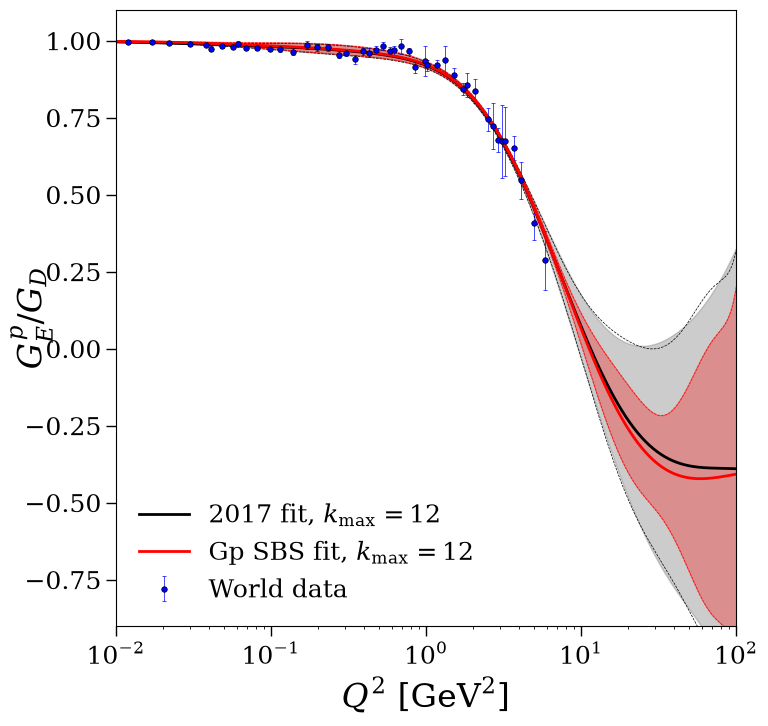

In [12]:
## Plot GE/GD, GM/muGD and GE/GM##########{{{
#Plot Range{{{
ymin1 =-0.9
ymax1 = 1.1
# ymin1 =-5.
# ymax1 = 4.
#}}}

com1 = r'World data' #John's 2007 paper
com2 = r'2017 fit, $k_{\max}=12$'
# com2 = r'New World fit, $k_{\max}=12$'
# com3 = r'Gp SBS fit (without cali), $k_{\max}=12$'
com3 = r'Gp SBS fit, $k_{\max}=12$'
# com3 = r'New Prad fit, $k_{\max}=12$'
# com3 = r'New World fit, $k_{\max}=12$'
com4 = r'fakeHQ data'
com5 = r'fakeSBS data'
com6 = r'2017 new fit(without cali)'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=18)

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,7))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#########
axes.errorbar(Q2_data, GEdip_data, yerr=dGEdip_data,color='b', fmt='o', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com1) #world data from John's paper - blue points
# axes.errorbar(Q2_HQ, GEp_rat_HQ, yerr=dGEp_rat_HQ,color='g', fmt='o', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com4)


#add 2017 fitting results{{{
axes.plot(Q2, GE_fit_rat, 'k-', linewidth=2, label=com2) #fitting line - black solid line
#axes.fill_between(Q2, GE_fit_rat-dGEGD, GE_fit_rat+dGEGD, edgecolor='r',facecolor='r',alpha=0.4)
axes.plot(Q2, GE_fit_rat+dGEGD, 'k--', linewidth=0.5) #fitting pos line - black dashed line
axes.plot(Q2, GE_fit_rat-dGEGD, 'k--', linewidth=0.5) #fitting neg line - black dashed line
axes.fill_between(Q2, GE_neg_rat, GE_pos_rat, edgecolor='gray',facecolor='gray',alpha=0.4) #red shading between neg and pos lines
#}}} 

# # #add world fitting results without corrections{{{
# axes.plot(Q2_new, GE_fit_rat_new, 'r-', linewidth=2, label=com6)  # red line
# axes.plot(Q2_new, GE_fit_rat_new+GE_err_rat_new, 'k--', linewidth=0.5)
# axes.plot(Q2_new, GE_fit_rat_new-GE_err_rat_new, 'k--', linewidth=0.5)
# axes.fill_between(Q2_new, GE_neg_rat_new, GE_pos_rat_new, edgecolor='gray',facecolor='gray',alpha=0.4)    
# # #}}}


# #add SBS fitting results (without cali){{{
# axes.plot(Q2_SBS, GE_fit_rat_SBS, 'r-', linewidth=2, label=com3)  # red line
# axes.plot(Q2_SBS, GE_fit_rat_SBS+GE_err_rat_SBS, 'r--', linewidth=0.5)
# axes.plot(Q2_SBS, GE_fit_rat_SBS-GE_err_rat_SBS, 'r--', linewidth=0.5)
# axes.fill_between(Q2_SBS, GE_neg_rat_SBS, GE_pos_rat_SBS, edgecolor='r',facecolor='r',alpha=0.3)    
# #}}}

#add SBS fitting results (with cali){{{
axes.plot(Q2_SBS, GE_fit_rat_SBS_cali, 'r-', linewidth=2, label=com3)  # red line
axes.plot(Q2_SBS, GE_fit_rat_SBS_cali+dGEGD_SBS_cali, 'r--', linewidth=0.5)
axes.plot(Q2_SBS, GE_fit_rat_SBS_cali-dGEGD_SBS_cali, 'r--', linewidth=0.5)
axes.fill_between(Q2_SBS, GE_neg_rat_SBS_cali, GE_pos_rat_SBS_cali, edgecolor='r',facecolor='r',alpha=0.3)    
#}}}

axes.set_xlim(Q2_min,100.)
#axes.set_xlim(Q2_min,Q2_max)
axes.set_ylim(ymin1,ymax1)
#axes.set_ylim(-1.2,1.2)
#axes.set_ylim(0.,1.05)

axes.set_xscale('log')
axes.set_ylabel('$G_E^p/G_{D}$', fontsize=24) # label, y-axis
axes.yaxis.set_label_coords(-0.1,0.5)
axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24) # label, x-axis

axes.xaxis.set_tick_params(width=1,length=7)
axes.yaxis.set_tick_params(width=1,length=7)
plt.tick_params(labelsize=18)
axes.legend(loc='best', fontsize=18, frameon=False)

# plt.savefig('Proton_GEGD_New.pdf', bbox_inches='tight')
plt.savefig('Proton_GEGD_SBS.png', bbox_inches='tight')

#}}}

## Plot $G_M^p/\mu_p G_D$

### vs. Q2

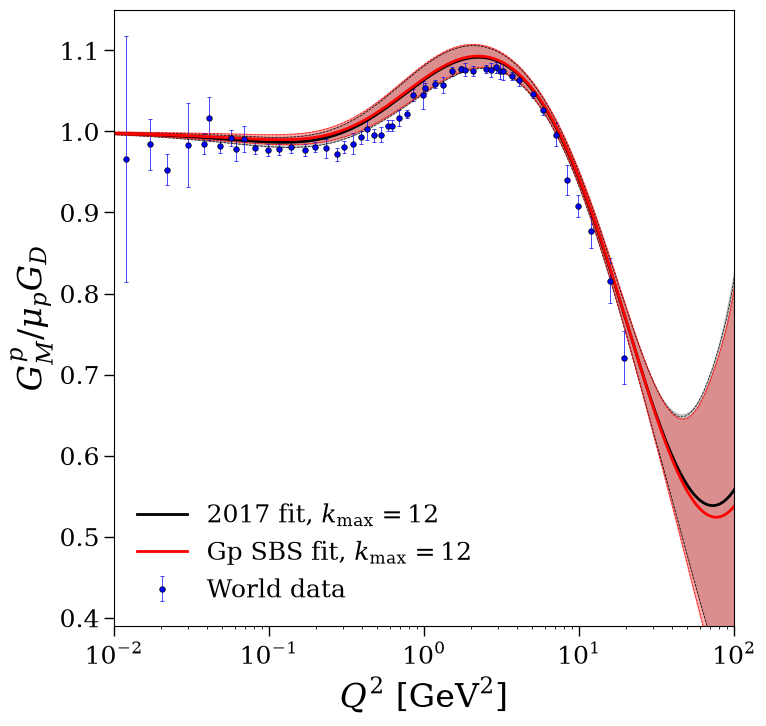

In [13]:
## Plot GE/GD, GM/muGD and GE/GM##########{{{
#Plot Range{{{
# ymin1 =-4.
# ymax1 = 5.
ymin1 =0.45
ymax1 = 1.15 
Q2plot1=100
#}}}

com1 = r'World data' #John's 2007 paper
com2 = r'2017 fit, $k_{\max}=12$'
# com2 = r'New World fit, $k_{\max}=12$'
# com3 = r'Gp SBS fit (without cali), $k_{\max}=12$'
com3 = r'Gp SBS fit, $k_{\max}=12$'
# com3 = r'New Prad fit, $k_{\max}=12$'
# com3 = r'New World fit, $k_{\max}=12$'
com4 = r'fakeHQ data'
com5 = r'fakeSBS data'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=18)

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,7))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#########
axes.errorbar(Q2_data, GMdip_data, yerr=dGMdip_data,color='b', fmt='o', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com1) #world
# axes.errorbar(Q2_HQ, GMp_rat_HQ, yerr=dGMp_rat_HQ,color='g', fmt='o', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com4)

#2017 Fit{{{
axes.plot(Q2, GM_fit_rat, 'k-', linewidth=2, label=com2)
#axes.fill_between(Q2, GM_fit_rat-dGMGD, GM_fit_rat+dGMGD, edgecolor='r',facecolor='r',alpha=0.4)
axes.plot(Q2, GM_fit_rat-dGMGD, 'k--', linewidth=0.5)
axes.plot(Q2, GM_fit_rat+dGMGD, 'k--', linewidth=0.5)
axes.fill_between(Q2, GM_neg_rat, GM_pos_rat, edgecolor='gray',facecolor='gray',alpha=0.4)
#}}}

# #New world Fit without corrections{{{
# axes.plot(Q2_new, GM_fit_rat_new, 'k-', linewidth=2, label=com2)
# #axes.fill_between(Q2, GM_fit_rat-dGMGD, GM_fit_rat+dGMGD, edgecolor='r',facecolor='r',alpha=0.4)
# axes.plot(Q2_new, GM_fit_rat_new-GM_err_rat_new, 'k--', linewidth=0.5)
# axes.plot(Q2_new, GM_fit_rat_new+GM_err_rat_new, 'k--', linewidth=0.5)
# axes.fill_between(Q2_new, GM_neg_rat_new, GM_pos_rat_new, edgecolor='gray',facecolor='gray',alpha=0.4)
# #}}}

# #New SBS Fit (without cali){{{
# axes.plot(Q2_SBS, GM_fit_rat_SBS, 'r-', linewidth=2, label=com3)
# #axes.fill_between(Q2, GM_fit_rat-dGMGD, GM_fit_rat+dGMGD, edgecolor='r',facecolor='r',alpha=0.4)
# axes.plot(Q2_SBS, GM_fit_rat_SBS-GM_err_rat_SBS, 'r--', linewidth=0.5)
# axes.plot(Q2_SBS, GM_fit_rat_SBS+GM_err_rat_SBS, 'r--', linewidth=0.5)
# axes.fill_between(Q2_SBS, GM_neg_rat_SBS, GM_pos_rat_SBS, edgecolor='r',facecolor='r',alpha=0.3)
# #}}}

#New SBS Fit (with cali){{{
axes.plot(Q2_SBS, GM_fit_rat_SBS_cali, 'r-', linewidth=2, label=com3)
#axes.fill_between(Q2, GM_fit_rat-dGMGD, GM_fit_rat+dGMGD, edgecolor='r',facecolor='r',alpha=0.4)
axes.plot(Q2_SBS, GM_fit_rat_SBS_cali-dGMGD_SBS_cali, 'r--', linewidth=0.5)
axes.plot(Q2_SBS, GM_fit_rat_SBS_cali+dGMGD_SBS_cali, 'r--', linewidth=0.5)
axes.fill_between(Q2_SBS, GM_neg_rat_SBS_cali, GM_pos_rat_SBS_cali, edgecolor='r',facecolor='r',alpha=0.3)
#}}}


axes.set_xlim(Q2_min,100)
#axes.set_xlim(Q2_min,Q2_max)
# axes.set_ylim(ymin1,ymax1)
axes.set_ylim(0.39,ymax1)
#axes.set_ylim(0.9,1.1)


axes.set_xscale('log')
axes.set_ylabel('$G_M^p/\mu_p G_{D}$', fontsize=24) # label, y-axis
axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24) # label, x-axis

axes.xaxis.set_tick_params(width=1,length=7)
axes.yaxis.set_tick_params(width=1,length=7)
plt.tick_params(labelsize=18)
axes.legend(loc='best', fontsize=18, frameon=False)
# plt.savefig('Proton_GMGD_New.pdf', bbox_inches='tight')
plt.savefig('Proton_GMGD_SBS.png', bbox_inches='tight')
#plt.savefig('Proton_GMGD_AP17.eps', bbox_inches='tight')
#plt.savefig('Proton_GMGD_Comp_Zoom.pdf', bbox_inches='tight')
#plt.savefig('Proton_GMGD_Comp_Zoom.eps', bbox_inches='tight')
#}}}

## Plot $\mu_p G_E^p/G_M^p$ 

### vs Q2

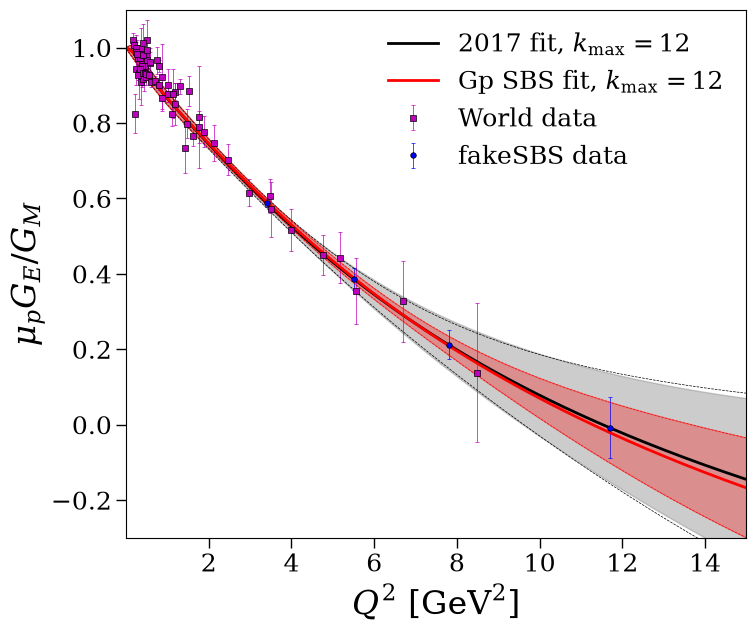

In [14]:
## Plot GE/GD, GM/muGD and GE/GM##########{{{
#Plot Range{{{
# ymin1 =-10
# ymax1 = 10
ymin1 =-1.05
ymax1 = 1.22 
Q2plot1=100
#}}}

com1 = r'World data' #John's 2007 paper
com2 = r'2017 fit, $k_{\max}=12$'
# com2 = r'New World fit, $k_{\max}=12$'
# com3 = r'Gp SBS fit (without cali), $k_{\max}=12$'
com3 = r'Gp SBS fit, $k_{\max}=12$'
# com3 = r'New Prad fit, $k_{\max}=12$'
# com3 = r'New World fit, $k_{\max}=12$'
com4 = r'fakeHQ data'
com5 = r'fakeSBS data'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=18)

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#########
# axes.errorbar(Q2_data, GEGMdip_data, yerr=dGEGMdip_data, fmt='o',color='black')
axes.errorbar(Q2_pol, GEGMrat_pol, yerr=dGEGMrat_pol, fmt='s', color='m', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com1) #world
# axes.errorbar(Q2_HQ, GEGMp_HQ, yerr=dGEGMp_HQ, fmt='o', color='g', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com4)
axes.errorbar(Q2_fakeSBS, GEGMp_fakeSBS, yerr=dGEGMp_fakeSBS, fmt='o', color='blue', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com5)


#2017 Fit{{{
axes.plot(Q2, GEGM_fit_rat, 'k-',linewidth=2,  label=com2)
#axes.fill_between(Q2, GEGM_fit_rat-dGEGM, GEGM_fit_rat+dGEGM, edgecolor='r',facecolor='r',alpha=0.4)
axes.plot(Q2, GEGM_fit_rat-abs(dGEGM), 'k--',linewidth=0.5)
axes.plot(Q2, GEGM_fit_rat+abs(dGEGM), 'k--',linewidth=0.5)
axes.fill_between(Q2, GEGM_neg_rat, GEGM_pos_rat, edgecolor='gray',facecolor='gray',alpha=0.4)
#}}}

# #New world Fit without corrections{{{
# axes.plot(Q2_new, GEGM_fit_rat_new, 'k-',linewidth=2,  label=com2)
# #axes.fill_between(Q2, GEGM_fit_rat-dGEGM, GEGM_fit_rat+dGEGM, edgecolor='r',facecolor='r',alpha=0.4)
# axes.plot(Q2_new, GEGM_fit_rat_new-GEGM_err_new, 'k--',linewidth=0.5)
# axes.plot(Q2_new, GEGM_fit_rat_new+GEGM_err_new, 'k--',linewidth=0.5)
# axes.fill_between(Q2_new, GEGM_neg_rat_new, GEGM_pos_rat_new, edgecolor='gray',facecolor='gray',alpha=0.4)
# #}}}

# #New SBS Fit (without cali){{{
# axes.plot(Q2_SBS, GEGM_fit_rat_SBS, 'r-',linewidth=2,  label=com3)
# #axes.fill_between(Q2, GEGM_fit_rat-dGEGM, GEGM_fit_rat+dGEGM, edgecolor='r',facecolor='r',alpha=0.4)
# axes.plot(Q2_SBS, GEGM_fit_rat_SBS-GEGM_err_SBS, 'r--',linewidth=0.5)
# axes.plot(Q2_SBS, GEGM_fit_rat_SBS+GEGM_err_SBS, 'r--',linewidth=0.5)
# axes.fill_between(Q2_SBS, GEGM_neg_rat_SBS, GEGM_pos_rat_SBS, edgecolor='r',facecolor='r',alpha=0.3)
# #}}}

#New SBS Fit (with cali){{{
axes.plot(Q2_SBS, GEGM_fit_rat_SBS_cali, 'r-',linewidth=2,  label=com3)
#axes.fill_between(Q2, GEGM_fit_rat-dGEGM, GEGM_fit_rat+dGEGM, edgecolor='r',facecolor='r',alpha=0.4)
axes.plot(Q2_SBS, GEGM_fit_rat_SBS_cali-abs(dGEGM_SBS_cali), 'r--',linewidth=0.5)
axes.plot(Q2_SBS, GEGM_fit_rat_SBS_cali+abs(dGEGM_SBS_cali), 'r--',linewidth=0.5)
axes.fill_between(Q2_SBS, GEGM_neg_rat_SBS_cali, GEGM_pos_rat_SBS_cali, edgecolor='r',facecolor='r',alpha=0.3)
#}}}

#axes.set_xlim(Q2_min,1000)
#axes.set_xlim(Q2_min,Q2_max)
# axes.set_ylim(ymin1,ymax1)
#axes.set_ylim(0.4,ymax1)
axes.set_xlim(Q2_min,15.)
axes.set_ylim(-0.3,1.1)

#axes.set_xscale('log')
axes.set_ylabel('$\mu_p G_E/G_M$', fontsize=24) # label, y-axis
axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24) # label, x-axis
#axes.xaxis.set_major_locator(MultipleLocator(Q2plot1/100))
#axes.xaxis.set_minor_locator(MultipleLocator(Q2plot1/200))

axes.xaxis.set_tick_params(width=1,length=7)
axes.yaxis.set_tick_params(width=1,length=7)
plt.tick_params(labelsize=18)
axes.legend(loc='best', fontsize=18, frameon=False)
# plt.savefig('Proton_GEGM_Nov1st.pdf', bbox_inches='tight')
plt.savefig('Proton_GEGM_SBS.png', bbox_inches='tight')
#}}}

## Plot $F_1^p$ and $F_2^p$

In [15]:
## Calculate proton F1 and F2 arrays ####################################{{{

# ----------------------------------------------------------------------
# Proton constants
# ----------------------------------------------------------------------
mu_p = GMp0
kappa_p = GMp0 - 1.0

# ----------------------------------------------------------------------
# Helper: tau_p
# ----------------------------------------------------------------------
def tau_p(Q2):
    return Q2 / (4.0 * Mass_p**2)

# ----------------------------------------------------------------------
# Helper: print three sample points from arrays
# ----------------------------------------------------------------------
def debug_print_samples(label, Q2_arr,
                        GE_ratio, dGE_ratio, GM_ratio, dGM_ratio,
                        gd, tau, GE, dGE, GM, dGM, F1, dF1, F2, dF2):
    """
    Print three representative points: first, middle, and last.
    """
    n = len(Q2_arr)
    if n == 0:
        print(f'[{label}] Empty array.')
        return

    sample_idx = sorted(set([0, n // 2, n - 1]))

    print('\n' + '=' * 90)
    print(f'[{label}] Debug summary')
    print(f'Length = {n}')
    print('-' * 90)
    print(' idx |      Q2 |       GD |      tau |   GE/GD |  dGE/GD |  GM/muGD | dGM/muGD'
          ' |       GE |      dGE |       GM |      dGM |       F1 |      dF1 |       F2 |      dF2')
    print('-' * 90)

    for i in sample_idx:
        print(f'{i:4d} | '
              f'{Q2_arr[i]:7.4f} | {gd[i]:8.4e} | {tau[i]:8.4e} | '
              f'{GE_ratio[i]:7.4f} | {dGE_ratio[i]:7.4f} | '
              f'{GM_ratio[i]:8.4f} | {dGM_ratio[i]:8.4f} | '
              f'{GE[i]:8.4e} | {dGE[i]:8.4e} | '
              f'{GM[i]:8.4e} | {dGM[i]:8.4e} | '
              f'{F1[i]:8.4e} | {dF1[i]:8.4e} | '
              f'{F2[i]:8.4e} | {dF2[i]:8.4e}')
    print('=' * 90)

# ----------------------------------------------------------------------
# Helper: convert ratio arrays to F1, F2 arrays
# Input:
#   GE_ratio    = GE^p / GD
#   dGE_ratio   = uncertainty of GE^p / GD
#   GM_ratio    = GM^p / (mu_p * GD)
#   dGM_ratio   = uncertainty of GM^p / (mu_p * GD)
# ----------------------------------------------------------------------
def calc_proton_F1F2(Q2_arr, GE_ratio, dGE_ratio, GM_ratio, dGM_ratio,
                     label='set', debug=False):

    # Convert to numpy arrays
    Q2_arr   = np.asarray(Q2_arr)
    GE_ratio = np.asarray(GE_ratio)
    dGE_ratio = np.asarray(dGE_ratio)
    GM_ratio = np.asarray(GM_ratio)
    dGM_ratio = np.asarray(dGM_ratio)

    # Basic shape check
    n = len(Q2_arr)
    if not (len(GE_ratio) == len(dGE_ratio) == len(GM_ratio) == len(dGM_ratio) == n):
        raise ValueError(
            f'[{label}] Array length mismatch: '
            f'len(Q2)={len(Q2_arr)}, len(GE_ratio)={len(GE_ratio)}, '
            f'len(dGE_ratio)={len(dGE_ratio)}, len(GM_ratio)={len(GM_ratio)}, '
            f'len(dGM_ratio)={len(dGM_ratio)}'
        )

    gd = GD(Q2_arr)
    tau = tau_p(Q2_arr)

    # Recover physical Sachs form factors
    GE = GE_ratio * gd
    dGE = dGE_ratio * gd

    GM = GM_ratio * mu_p * gd
    dGM = dGM_ratio * mu_p * gd

    # Dirac and Pauli form factors
    F1 = (GE + tau * GM) / (1.0 + tau)
    F2 = (GM - GE) / (kappa_p * (1.0 + tau))

    # Error propagation assuming GE and GM are uncorrelated
    dF1 = np.sqrt(dGE**2 + (tau * dGM)**2) / (1.0 + tau)
    dF2 = np.sqrt(dGE**2 + dGM**2) / (abs(kappa_p) * (1.0 + tau))

    if debug:
        debug_print_samples(label,
                            Q2_arr, GE_ratio, dGE_ratio, GM_ratio, dGM_ratio,
                            gd, tau, GE, dGE, GM, dGM, F1, dF1, F2, dF2)

    return F1, dF1, F2, dF2

# ----------------------------------------------------------------------
# 0) World data arrays
# ----------------------------------------------------------------------
F1p_data, dF1p_data, F2p_data, dF2p_data = calc_proton_F1F2(
    Q2_data,
    GEdip_data, dGEdip_data,
    GMdip_data, dGMdip_data,
    label='World data',
    debug=True
)

# ----------------------------------------------------------------------
# 1) 2017 fit arrays
# ----------------------------------------------------------------------
F1p_fit, dF1p_fit, F2p_fit, dF2p_fit = calc_proton_F1F2(
    Q2,
    GE_fit_rat, dGEGD,
    GM_fit_rat, dGMGD,
    label='2017 fit',
    debug=True
)

# ----------------------------------------------------------------------
# 2) SBS fit arrays
# ----------------------------------------------------------------------
F1p_SBS, dF1p_SBS, F2p_SBS, dF2p_SBS = calc_proton_F1F2(
    Q2_SBS,
    GE_fit_rat_SBS_cali, dGEGD_SBS_cali,
    GM_fit_rat_SBS_cali, dGMGD_SBS_cali,
    label='SBS fit',
    debug=True
)

#}}}


[World data] Debug summary
Length = 53
------------------------------------------------------------------------------------------
 idx |      Q2 |       GD |      tau |   GE/GD |  dGE/GD |  GM/muGD | dGM/muGD |       GE |      dGE |       GM |      dGM |       F1 |      dF1 |       F2 |      dF2
------------------------------------------------------------------------------------------
   0 |  0.0070 | 9.8057e-01 | 1.9878e-03 |  1.0000 |  0.0060 |   0.7150 |   0.3930 | 9.8057e-01 | 5.8834e-03 | 1.9581e+00 | 1.0763e+00 | 9.8251e-01 | 6.2479e-03 | 5.4415e-01 | 5.9913e-01
  26 |  0.6220 | 2.8412e-01 | 1.7663e-01 |  0.9690 |  0.0140 |   1.0070 |   0.0070 | 2.7532e-01 | 3.9777e-03 | 7.9907e-01 | 5.5546e-03 | 3.5394e-01 | 3.4819e-03 | 2.4828e-01 | 3.2386e-03
  52 | 19.4700 | 1.2379e-03 | 5.5290e+00 | 10000.0000 |  0.0000 |   0.7210 |   0.0330 | 1.2379e+01 | 0.0000e+00 | 2.4926e-03 | 1.1409e-04 | 1.8981e+00 | 9.6613e-05 | -1.0573e+00 | 9.7464e-06

[2017 fit] Debug summary
Length = 2000
------

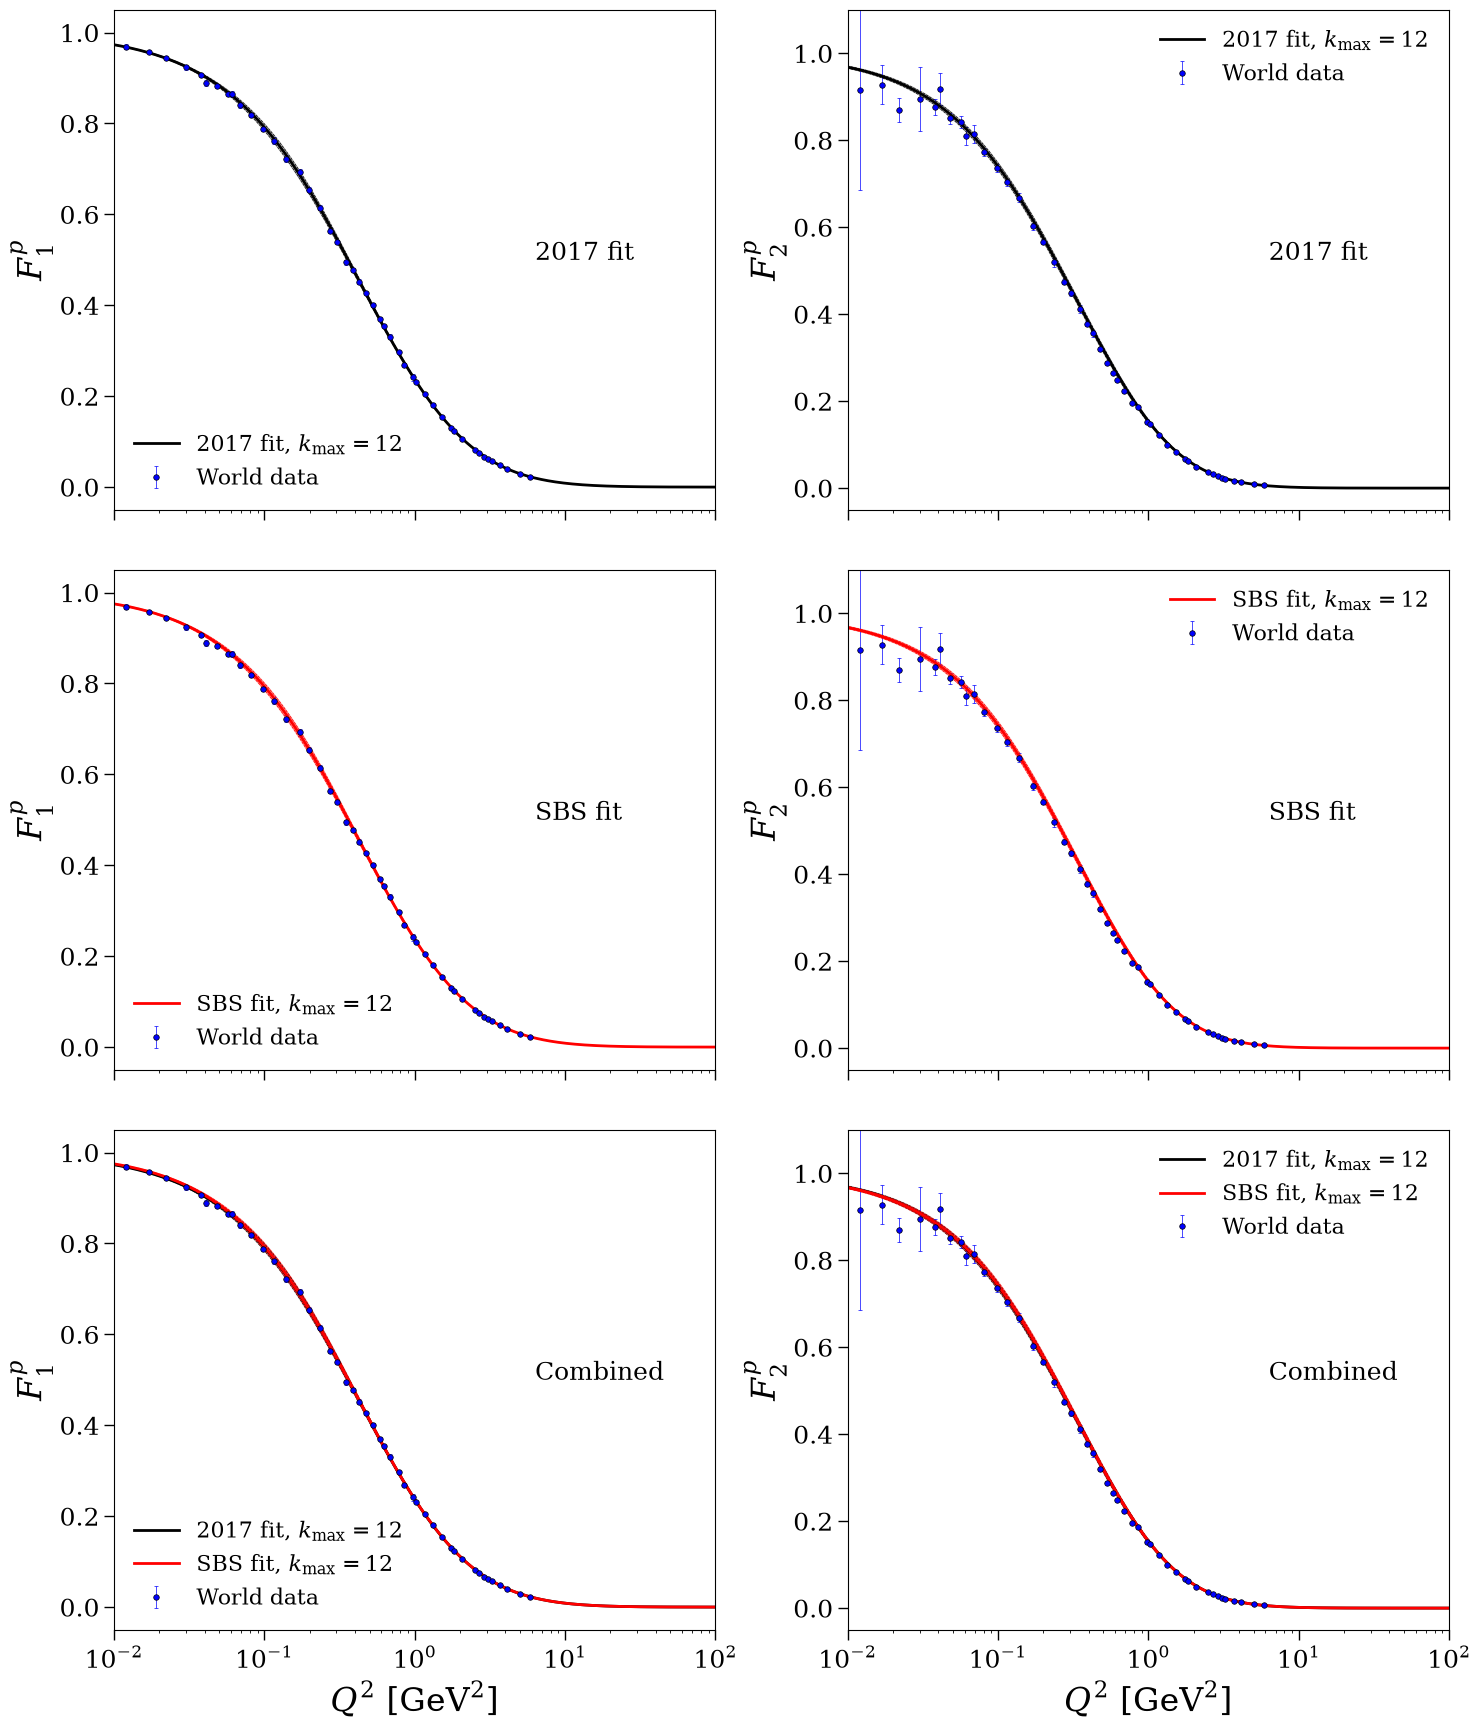

In [16]:
## Plot proton F1 and F2 ################################################{{{

# ----------------------------------------------------------------------
# Plot settings
# ----------------------------------------------------------------------
com1 = r'World data'
com2 = r'2017 fit, $k_{\max}=12$'
com3 = r'SBS fit, $k_{\max}=12$'

# Adjust ranges if needed
ymin_F1 = -0.05
ymax_F1 = 1.05

ymin_F2 = -0.05
ymax_F2 = 1.10

f1, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18), sharex='col')
f1.subplots_adjust(left=0.09, right=0.98, bottom=0.07, top=0.97, hspace=0.12, wspace=0.22)

# ======================================================================
# Row 1, Col 1: F1^p, 2017 fit
# ======================================================================
axes[0,0].errorbar(
    Q2_data, F1p_data, yerr=dF1p_data,
    color='b', fmt='o', markersize=4, markeredgewidth=0.5,
    markeredgecolor='black', capsize=1.5, capthick=0.5,
    elinewidth=0.5, label=com1
)

axes[0,0].plot(Q2, F1p_fit, 'k-', linewidth=2, label=com2)
axes[0,0].plot(Q2, F1p_fit + dF1p_fit, 'k--', linewidth=0.5)
axes[0,0].plot(Q2, F1p_fit - dF1p_fit, 'k--', linewidth=0.5)
axes[0,0].fill_between(
    Q2, F1p_fit - dF1p_fit, F1p_fit + dF1p_fit,
    edgecolor='gray', facecolor='gray', alpha=0.4
)

axes[0,0].set_xscale('log')
axes[0,0].set_xlim(Q2_min, 100.0)
axes[0,0].set_ylim(ymin_F1, ymax_F1)
axes[0,0].set_ylabel(r'$F_1^p$', fontsize=24)
axes[0,0].text(0.7, 0.50, r'2017 fit', transform=axes[0,0].transAxes, fontsize=18)

axes[0,0].xaxis.set_tick_params(width=1, length=7)
axes[0,0].yaxis.set_tick_params(width=1, length=7)
axes[0,0].tick_params(labelsize=18)
axes[0,0].legend(loc='best', fontsize=16, frameon=False)

# ======================================================================
# Row 1, Col 2: F2^p, 2017 fit
# ======================================================================
axes[0,1].errorbar(
    Q2_data, F2p_data, yerr=dF2p_data,
    color='b', fmt='o', markersize=4, markeredgewidth=0.5,
    markeredgecolor='black', capsize=1.5, capthick=0.5,
    elinewidth=0.5, label=com1
)

axes[0,1].plot(Q2, F2p_fit, 'k-', linewidth=2, label=com2)
axes[0,1].plot(Q2, F2p_fit + dF2p_fit, 'k--', linewidth=0.5)
axes[0,1].plot(Q2, F2p_fit - dF2p_fit, 'k--', linewidth=0.5)
axes[0,1].fill_between(
    Q2, F2p_fit - dF2p_fit, F2p_fit + dF2p_fit,
    edgecolor='gray', facecolor='gray', alpha=0.4
)

axes[0,1].set_xscale('log')
axes[0,1].set_xlim(Q2_min, 100.0)
axes[0,1].set_ylim(ymin_F2, ymax_F2)
axes[0,1].set_ylabel(r'$F_2^p$', fontsize=24)
axes[0,1].text(0.7, 0.50, r'2017 fit', transform=axes[0,1].transAxes, fontsize=18)

axes[0,1].xaxis.set_tick_params(width=1, length=7)
axes[0,1].yaxis.set_tick_params(width=1, length=7)
axes[0,1].tick_params(labelsize=18)
axes[0,1].legend(loc='best', fontsize=16, frameon=False)

# ======================================================================
# Row 2, Col 1: F1^p, SBS fit
# ======================================================================
axes[1,0].errorbar(
    Q2_data, F1p_data, yerr=dF1p_data,
    color='b', fmt='o', markersize=4, markeredgewidth=0.5,
    markeredgecolor='black', capsize=1.5, capthick=0.5,
    elinewidth=0.5, label=com1
)

axes[1,0].plot(Q2_SBS, F1p_SBS, 'r-', linewidth=2, label=com3)
axes[1,0].plot(Q2_SBS, F1p_SBS + dF1p_SBS, 'r--', linewidth=0.5)
axes[1,0].plot(Q2_SBS, F1p_SBS - dF1p_SBS, 'r--', linewidth=0.5)
axes[1,0].fill_between(
    Q2_SBS, F1p_SBS - dF1p_SBS, F1p_SBS + dF1p_SBS,
    edgecolor='r', facecolor='r', alpha=0.3
)

axes[1,0].set_xscale('log')
axes[1,0].set_xlim(Q2_min, 100.0)
axes[1,0].set_ylim(ymin_F1, ymax_F1)
axes[1,0].set_ylabel(r'$F_1^p$', fontsize=24)
axes[1,0].text(0.7, 0.50, r'SBS fit', transform=axes[1,0].transAxes, fontsize=18)

axes[1,0].xaxis.set_tick_params(width=1, length=7)
axes[1,0].yaxis.set_tick_params(width=1, length=7)
axes[1,0].tick_params(labelsize=18)
axes[1,0].legend(loc='best', fontsize=16, frameon=False)

# ======================================================================
# Row 2, Col 2: F2^p, SBS fit
# ======================================================================
axes[1,1].errorbar(
    Q2_data, F2p_data, yerr=dF2p_data,
    color='b', fmt='o', markersize=4, markeredgewidth=0.5,
    markeredgecolor='black', capsize=1.5, capthick=0.5,
    elinewidth=0.5, label=com1
)

axes[1,1].plot(Q2_SBS, F2p_SBS, 'r-', linewidth=2, label=com3)
axes[1,1].plot(Q2_SBS, F2p_SBS + dF2p_SBS, 'r--', linewidth=0.5)
axes[1,1].plot(Q2_SBS, F2p_SBS - dF2p_SBS, 'r--', linewidth=0.5)
axes[1,1].fill_between(
    Q2_SBS, F2p_SBS - dF2p_SBS, F2p_SBS + dF2p_SBS,
    edgecolor='r', facecolor='r', alpha=0.3
)

axes[1,1].set_xscale('log')
axes[1,1].set_xlim(Q2_min, 100.0)
axes[1,1].set_ylim(ymin_F2, ymax_F2)
axes[1,1].set_ylabel(r'$F_2^p$', fontsize=24)
axes[1,1].text(0.7, 0.50, r'SBS fit', transform=axes[1,1].transAxes, fontsize=18)

axes[1,1].xaxis.set_tick_params(width=1, length=7)
axes[1,1].yaxis.set_tick_params(width=1, length=7)
axes[1,1].tick_params(labelsize=18)
axes[1,1].legend(loc='best', fontsize=16, frameon=False)

# ======================================================================
# Row 3, Col 1: F1^p, combined
# ======================================================================
axes[2,0].errorbar(
    Q2_data, F1p_data, yerr=dF1p_data,
    color='b', fmt='o', markersize=4, markeredgewidth=0.5,
    markeredgecolor='black', capsize=1.5, capthick=0.5,
    elinewidth=0.5, label=com1
)

axes[2,0].plot(Q2, F1p_fit, 'k-', linewidth=2, label=com2)
axes[2,0].plot(Q2, F1p_fit + dF1p_fit, 'k--', linewidth=0.5)
axes[2,0].plot(Q2, F1p_fit - dF1p_fit, 'k--', linewidth=0.5)
axes[2,0].fill_between(
    Q2, F1p_fit - dF1p_fit, F1p_fit + dF1p_fit,
    edgecolor='gray', facecolor='gray', alpha=0.4
)

axes[2,0].plot(Q2_SBS, F1p_SBS, 'r-', linewidth=2, label=com3)
axes[2,0].plot(Q2_SBS, F1p_SBS + dF1p_SBS, 'r--', linewidth=0.5)
axes[2,0].plot(Q2_SBS, F1p_SBS - dF1p_SBS, 'r--', linewidth=0.5)
axes[2,0].fill_between(
    Q2_SBS, F1p_SBS - dF1p_SBS, F1p_SBS + dF1p_SBS,
    edgecolor='r', facecolor='r', alpha=0.3
)

axes[2,0].set_xscale('log')
axes[2,0].set_xlim(Q2_min, 100.0)
axes[2,0].set_ylim(ymin_F1, ymax_F1)
axes[2,0].set_xlabel(r'$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24)
axes[2,0].set_ylabel(r'$F_1^p$', fontsize=24)
axes[2,0].text(0.7, 0.50, r'Combined', transform=axes[2,0].transAxes, fontsize=18)

axes[2,0].xaxis.set_tick_params(width=1, length=7)
axes[2,0].yaxis.set_tick_params(width=1, length=7)
axes[2,0].tick_params(labelsize=18)
axes[2,0].legend(loc='best', fontsize=16, frameon=False)

# ======================================================================
# Row 3, Col 2: F2^p, combined
# ======================================================================
axes[2,1].errorbar(
    Q2_data, F2p_data, yerr=dF2p_data,
    color='b', fmt='o', markersize=4, markeredgewidth=0.5,
    markeredgecolor='black', capsize=1.5, capthick=0.5,
    elinewidth=0.5, label=com1
)

axes[2,1].plot(Q2, F2p_fit, 'k-', linewidth=2, label=com2)
axes[2,1].plot(Q2, F2p_fit + dF2p_fit, 'k--', linewidth=0.5)
axes[2,1].plot(Q2, F2p_fit - dF2p_fit, 'k--', linewidth=0.5)
axes[2,1].fill_between(
    Q2, F2p_fit - dF2p_fit, F2p_fit + dF2p_fit,
    edgecolor='gray', facecolor='gray', alpha=0.4
)

axes[2,1].plot(Q2_SBS, F2p_SBS, 'r-', linewidth=2, label=com3)
axes[2,1].plot(Q2_SBS, F2p_SBS + dF2p_SBS, 'r--', linewidth=0.5)
axes[2,1].plot(Q2_SBS, F2p_SBS - dF2p_SBS, 'r--', linewidth=0.5)
axes[2,1].fill_between(
    Q2_SBS, F2p_SBS - dF2p_SBS, F2p_SBS + dF2p_SBS,
    edgecolor='r', facecolor='r', alpha=0.3
)

axes[2,1].set_xscale('log')
axes[2,1].set_xlim(Q2_min, 100.0)
axes[2,1].set_ylim(ymin_F2, ymax_F2)
axes[2,1].set_xlabel(r'$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24)
axes[2,1].set_ylabel(r'$F_2^p$', fontsize=24)
axes[2,1].text(0.7, 0.50, r'Combined', transform=axes[2,1].transAxes, fontsize=18)

axes[2,1].xaxis.set_tick_params(width=1, length=7)
axes[2,1].yaxis.set_tick_params(width=1, length=7)
axes[2,1].tick_params(labelsize=18)
axes[2,1].legend(loc='best', fontsize=16, frameon=False)

plt.savefig('Proton_F1F2_3x2_SBS.png', bbox_inches='tight')
# plt.savefig('Proton_F1F2_3x2_SBS.pdf', bbox_inches='tight')

#}}}

# Load Neutron Fit

# Load 2017 Neutron World Sum-Rules Fitting Results (set 1)

In [17]:
##Load Q2max=1000 Fitting results#{{{
#filename='neutron_baseline_seg5.dat'
filename='./plotdata/neutron_lookup.dat'

if os.path.isfile(filename):
    print('file exist', filename)

fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2n = np.zeros(N, dtype=float)
#Zn = np.zeros(N, dtype=float)
GEn_fit = np.zeros(N, dtype=float)
GEn_pos = np.zeros(N, dtype=float)
GEn_neg = np.zeros(N, dtype=float)
GMn_fit = np.zeros(N, dtype=float)
GMn_pos = np.zeros(N, dtype=float)
GMn_neg = np.zeros(N, dtype=float)
GEn_fit_rat = np.zeros(N, dtype=float)
GEn_pos_rat = np.zeros(N, dtype=float)
GEn_neg_rat = np.zeros(N, dtype=float)
GMn_fit_rat = np.zeros(N, dtype=float)
GMn_pos_rat = np.zeros(N, dtype=float)
GMn_neg_rat = np.zeros(N, dtype=float)
GEGMn_fit_rat = np.zeros(N, dtype=float)
GEGMn_pos_rat = np.zeros(N, dtype=float)
GEGMn_neg_rat = np.zeros(N, dtype=float)
GEn_err_rat = np.zeros(N, dtype=float)
GMn_err_rat = np.zeros(N, dtype=float)
GEGMn_err = np.zeros(N, dtype=float)
GEDn = np.zeros(N, dtype=float)
GMDn = np.zeros(N, dtype=float)

dGEGDn = np.zeros(N, dtype=float)
dGMGDn = np.zeros(N, dtype=float)
dGEGMn = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2n[i]=float(values[0])
#    Zn[i]=float(values[1])
    GEn_fit_rat[i]=float(values[1])
    GEn_err_rat[i] = abs(float(values[2]) ) #/ abs(float(values[2]))
    dGEGDn[i] = abs(float(values[3]) )
    GMn_fit_rat[i]=float(values[4])
    GMn_err_rat[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    dGMGDn[i] = abs(float(values[6]) )  
       
    #dGEGD[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp5, c_GEp5, d_GEp5, L_GEp5 ) 
    #dGMGD[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp5, c_GMp5, d_GMp5, L_GMp5 ) 
    #dGEGD[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp, c_GEp, d_GEp, L_GEp ) 
    #dGMGD[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp, c_GMp, d_GMp, L_GMp ) 
    
    GEn_pos_rat[i] = GEn_fit_rat[i] + GEn_err_rat[i]
    GEn_neg_rat[i] = GEn_fit_rat[i] - GEn_err_rat[i]
    
    GMn_pos_rat[i] = GMn_fit_rat[i] + GMn_err_rat[i]
    GMn_neg_rat[i] = GMn_fit_rat[i] - GMn_err_rat[i]
    
    GEDn[i] = GD(Q2n[i]) * GEn0
    GMDn[i] = GD(Q2n[i]) * GMn0
    
    GEn_fit[i]=GEn_fit_rat[i] * GEDn[i]
    GMn_fit[i]=GMn_fit_rat[i] * GMDn[i]
    GEn_pos[i] = GEn_fit[i] + dGEGDn[i]* GEDn[i]
    GEn_neg[i] = GEn_fit[i] - dGEGDn[i]* GEDn[i]  
    GMn_pos[i] = GMn_fit[i] + dGMGDn[i]* GMDn[i]
    GMn_neg[i] = GMn_fit[i] - dGMGDn[i]* GMDn[i]
   
    GEGMn_fit_rat[i] = GEn_fit_rat[i] / GMn_fit_rat[i]
    GEGMn_err[i] = GEGMn_fit_rat[i]* sqrt((GEn_err_rat[i]/GEn_fit_rat[i])**2 + (GMn_err_rat[i]/GMn_fit_rat[i])**2)    
    dGEGMn[i] = GEGMn_fit_rat[i] * sqrt( (dGEGDn[i]/GEn_fit_rat[i])**2 + (dGMGDn[i]/GMn_fit_rat[i])**2 )
    
    GEGMn_pos_rat[i] = GEGMn_fit_rat[i]+GEGMn_err[i]
    GEGMn_neg_rat[i] = GEGMn_fit_rat[i]-GEGMn_err[i]


tcut=0.0779191396
t0 = -0.7

file exist ./plotdata/neutron_lookup.dat


# Load $G_E^n$ World+SBS Fitting Results by Haocen (set 3)

In [18]:
##Load SBS GEn (Q2max=1000) SumRules output#{{{
# filename='./plotdata/out_world_SBS_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GEn.dat'
filename='./plotdata/final_fit_SBS/out_world_sumrules_leastsq_Q21000_z11_gb5_t0fix7_GEn_SBS.dat'

if os.path.isfile(filename):
    print('file exist', filename)

fitlines = open(filename, 'r').readlines()

##Extract results from text file (sumrules output).
##Data lines: line 3~2402 (1-based) => fitlines[2]~fitlines[2401] (0-based)
N = 2000

Q2_SBS = np.zeros(N, dtype=float)
z_SBS  = np.zeros(N, dtype=float)

GEn_SBS  = np.zeros(N, dtype=float)
dGEn_SBS = np.zeros(N, dtype=float)
GD_SBS   = np.zeros(N, dtype=float)

GEn_rat_SBS     = np.zeros(N, dtype=float)
GEn_err_rat_SBS = np.zeros(N, dtype=float)
GEn_pos_rat_SBS = np.zeros(N, dtype=float)
GEn_neg_rat_SBS = np.zeros(N, dtype=float)

##Calibrated ratios from GetFF (SBSproj calibrated set)
GEn_fit_rat_SBS_cali = np.zeros(N, dtype=float)
dGEGDn_SBS_cali      = np.zeros(N, dtype=float)
GEn_pos_rat_SBS_cali = np.zeros(N, dtype=float)
GEn_neg_rat_SBS_cali = np.zeros(N, dtype=float)

##Import GetFF from current folder
from GetFF_final_SBS import GetFF

##kID mapping (default): 1:GEp, 2:GMp, 3:GEn, 4:GMn
kID_GEn = 3

for i in range(0,N):

    values = fitlines[i+1].split()   # skip first 1 header lines
    # columns: Q2, z, GEn, dGEn, GD
    Q2_SBS[i]   = float(values[0])
    z_SBS[i]    = float(values[1])
    GEn_SBS[i]  = float(values[2])
    dGEn_SBS[i] = abs(float(values[3]))
    GD_SBS[i]   = float(values[4])

    ##Ratio to dipole GD
    GEn_rat_SBS[i]     = GEn_SBS[i] / GD_SBS[i]
    GEn_err_rat_SBS[i] = dGEn_SBS[i] / GD_SBS[i]

    GEn_pos_rat_SBS[i] = GEn_rat_SBS[i] + GEn_err_rat_SBS[i]
    GEn_neg_rat_SBS[i] = GEn_rat_SBS[i] - GEn_err_rat_SBS[i]

    ##Calibrated ratio directly from GetFF
    GEn_fit_rat_SBS_cali[i], dGEGDn_SBS_cali[i] = GetFF(kID_GEn, Q2_SBS[i])
    
    #dGEGDn
    dGEGDn_SBS_cali[i] = GEn_err_rat_SBS[i]

    GEn_pos_rat_SBS_cali[i] = GEn_fit_rat_SBS_cali[i] + dGEGDn_SBS_cali[i]
    GEn_neg_rat_SBS_cali[i] = GEn_fit_rat_SBS_cali[i] - dGEGDn_SBS_cali[i]
##}}}


file exist ./plotdata/final_fit_SBS/out_world_sumrules_leastsq_Q21000_z11_gb5_t0fix7_GEn_SBS.dat


# Load $G_M^n$ World+SBS Fitting Results by Tyler (set 2)

In [19]:
##Load SBS GMn (Q2max=1000) Lookup + Calibrated ratios#{{{
filename='./plotdata/GMn_lookup_SBSproj.dat'

if os.path.isfile(filename):
    print('file exist', filename)

fitlines = open(filename, 'r').readlines()

##Extract results from text file (3 columns): Q2, GMn_rat, GMn_err_rat
##Read from line 2 to line 2001 (1-based) => fitlines[1] ~ fitlines[2000] (0-based)
N = 2000

Q2_SBS_GMn = np.zeros(N, dtype=float)

GMn_fit_rat_SBS = np.zeros(N, dtype=float)
GMn_err_rat_SBS = np.zeros(N, dtype=float)
GMn_pos_rat_SBS = np.zeros(N, dtype=float)
GMn_neg_rat_SBS = np.zeros(N, dtype=float)

##Since no GD in file: compute GD(Q2) manually and use mu_n to recover GMn
GD_SBS_GMn  = np.zeros(N, dtype=float)
GMDn_SBS    = np.zeros(N, dtype=float)   # GD * mu_n
GMn_fit_SBS = np.zeros(N, dtype=float)
GMn_pos_SBS = np.zeros(N, dtype=float)
GMn_neg_SBS = np.zeros(N, dtype=float)

##Calibrated ratios from GetFF (SBSproj calibrated set)
GMn_fit_rat_SBS_cali = np.zeros(N, dtype=float)
dGMGDn_SBS_cali      = np.zeros(N, dtype=float)
GMn_pos_rat_SBS_cali = np.zeros(N, dtype=float)
GMn_neg_rat_SBS_cali = np.zeros(N, dtype=float)

GMn_fit_SBS_cali = np.zeros(N, dtype=float)
GMn_pos_SBS_cali = np.zeros(N, dtype=float)
GMn_neg_SBS_cali = np.zeros(N, dtype=float)

##Constants for dipole and neutron magnetic moment mu_n
Lambda2 = 0.71
mu_n = -1.91304272

##Import GetFF from current folder
from GetFF_SBSproj import GetFF

##kID mapping (default): 1:GEp, 2:GMp, 3:GEn, 4:GMn
kID_GMn = 4

for i in range(0,N):

    values = fitlines[i+1].strip().split(',')
    # columns: Q2, GMn_rat, GMn_err_rat
    Q2_SBS_GMn[i]        = float(values[0])
    GMn_fit_rat_SBS[i]   = float(values[1])
    GMn_err_rat_SBS[i]   = abs(float(values[2]))

    GMn_pos_rat_SBS[i] = GMn_fit_rat_SBS[i] + GMn_err_rat_SBS[i]
    GMn_neg_rat_SBS[i] = GMn_fit_rat_SBS[i] - GMn_err_rat_SBS[i]

    ##Manual dipole GD(Q2) and GMn0=mu_n normalization
    GD_SBS_GMn[i] = 1.0 / (1.0 + Q2_SBS_GMn[i]/Lambda2)**2
    GMDn_SBS[i]   = GD_SBS_GMn[i] * mu_n

    ##Recover absolute GMn from ratio
    GMn_fit_SBS[i] = GMn_fit_rat_SBS[i] * GMDn_SBS[i]
    GMn_pos_SBS[i] = (GMn_fit_rat_SBS[i] + GMn_err_rat_SBS[i]) * GMDn_SBS[i]
    GMn_neg_SBS[i] = (GMn_fit_rat_SBS[i] - GMn_err_rat_SBS[i]) * GMDn_SBS[i]

    ##Calibrated ratio directly from GetFF
    GMn_fit_rat_SBS_cali[i], dGMGDn_SBS_cali[i] = GetFF(kID_GMn, Q2_SBS_GMn[i])
    dGMGDn_SBS_cali[i] = abs(dGMGDn_SBS_cali[i])

    GMn_pos_rat_SBS_cali[i] = GMn_fit_rat_SBS_cali[i] + dGMGDn_SBS_cali[i]
    GMn_neg_rat_SBS_cali[i] = GMn_fit_rat_SBS_cali[i] - dGMGDn_SBS_cali[i]

    ##Recover absolute calibrated GMn using the same GD*mu_n
    GMn_fit_SBS_cali[i] = GMn_fit_rat_SBS_cali[i] * GMDn_SBS[i]
    GMn_pos_SBS_cali[i] = (GMn_fit_rat_SBS_cali[i] + dGMGDn_SBS_cali[i]) * GMDn_SBS[i]
    GMn_neg_SBS_cali[i] = (GMn_fit_rat_SBS_cali[i] - dGMGDn_SBS_cali[i]) * GMDn_SBS[i]
##}}}


file exist ./plotdata/GMn_lookup_SBSproj.dat


## Load $G_E^n$ Data Points

In [20]:
## Load GEn Data
#########################{{{
def loadGEn(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GEn=[]
    dGEn=[]
    GEn_rat=[]
    dGEn_rat=[]
        
    fitlines = open('./data/neutron/GLOBFIT17_gen_feb07.out', 'r').readlines()
    #fitlines = open('../data/DOE13_gen.out', 'r').readlines()
    for i in range(1,len(fitlines)):
        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try:#eliminates descriptions in 1st line of file
            Q2test=values[0]
        except:
            continue

        if Q2test>Q2_max:
            continue

        Q2n.append(values[0])
        Gdip = 1./(1.+values[0]/0.71)**2
        GEn.append(values[1])
        dGEn.append(values[2])
        GEn_rat.append(values[1]/Gdip)
        dGEn_rat.append(values[2]/Gdip)

        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)

    return Q2n,Zn, GEn, dGEn,GEn_rat,dGEn_rat
#######################
##Read GE/GD, GM/nuGD, and GE/GM from John's 2007 paper
Q2e_data_sr, Ze_data_sr, GE_data_sr, dGE_data_sr,GErat_data_sr,dGErat_data_sr =loadGEn(Q2plot, -0.7, 0.0779191396)

Q2e_data_sr=np.array(Q2e_data_sr, dtype=float)
Ze_data_sr=np.array(Ze_data_sr, dtype=float)
GE_data_sr=np.array(GE_data_sr, dtype=float)
dGE_data_sr=np.array(dGE_data_sr, dtype=float)
GErat_data_sr=np.array(GErat_data_sr, dtype=float)
dGErat_data_sr=np.array(dGErat_data_sr, dtype=float)
#}}}

## Load $G^n_M$ Data Points

In [21]:
## Load GMn Data
#########################{{{
def loadGMn(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GMn=[]
    dGMn=[]
    GMn_rat=[]
    dGMn_rat=[]
        
    fitlines = open('./data/neutron/GLOBFIT17_gmn_feb07.out', 'r').readlines()
    for i in range(1,len(fitlines)):
        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue

        if Q2test>Q2_max:
            continue
        Q2n.append(values[0])
        Gdip = 1./(1.+values[0]/0.71)**2
        GMn_rat.append(values[1])
        dGMn_rat.append(values[2])
        GMn.append(values[1]*GMn0*Gdip)
        dGMn.append(values[2]*GMn0*Gdip)
    
        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)
    
    return Q2n,Zn,GMn, dGMn, GMn_rat, dGMn_rat
#######################
Q2m_data_sr, Zm_data_sr, GM_data_sr, dGM_data_sr, GMrat_data_sr, dGMrat_data_sr=loadGMn(Q2plot, -0.7,  0.0779191396)

Q2m_data_sr=np.array(Q2m_data_sr, dtype=float)
Zm_data_sr=np.array(Zm_data_sr, dtype=float)
GM_data_sr=np.array(GM_data_sr, dtype=float)
dGM_data_sr=np.array(dGM_data_sr, dtype=float)
GMrat_data_sr=np.array(GMrat_data_sr, dtype=float)
dGMrat_data_sr=np.array(dGMrat_data_sr, dtype=float)
#for i in range(len(Q2m_data)):
#    print '---', Q2m_data[i], GM_data[i]
#}}}

## Load $G^n_E$ and $G^n_M$ SBS Data Points

In [22]:
## Load SBS Data Points (GEnGMn_SBS.dat)
#########################{{{
def loadSBSpts(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GD=[]
    GEGM=[]
    dGEGM=[]
    GMGD=[]
    dGMGD=[]
    GEGD=[]
    dGEGD=[]

    fitlines = open('./plotdata/GEnGMn_SBS.dat', 'r').readlines()
    for i in range(1,len(fitlines)):

        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try: # eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue

        if Q2test>Q2_max:
            continue

        Q2n.append(values[0])
        GD.append(values[1])
        GEGM.append(values[2])
        dGEGM.append(values[3])
        GMGD.append(values[4])
        dGMGD.append(values[5])
        GEGD.append(values[6])
        dGEGD.append(values[7])

        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)

    return Q2n,Zn,GD,GEGM,dGEGM,GMGD,dGMGD,GEGD,dGEGD
#######################
Q2_SBS_sr, Z_SBS_sr, GD_SBS_sr, GEGM_SBS_sr, dGEGM_SBS_sr, GMGD_SBS_sr, dGMGD_SBS_sr, GEGD_SBS_sr, dGEGD_SBS_sr = loadSBSpts(Q2plot, -0.7, 0.0779191396)

Q2_SBS_sr   = np.array(Q2_SBS_sr, dtype=float)
Z_SBS_sr    = np.array(Z_SBS_sr, dtype=float)
GD_SBS_sr   = np.array(GD_SBS_sr, dtype=float)
GEGM_SBS_sr  = np.array(GEGM_SBS_sr, dtype=float)
dGEGM_SBS_sr = np.array(dGEGM_SBS_sr, dtype=float)
GMGD_SBS_sr  = np.array(GMGD_SBS_sr, dtype=float)
dGMGD_SBS_sr = np.array(dGMGD_SBS_sr, dtype=float)
GEGD_SBS_sr  = np.array(GEGD_SBS_sr, dtype=float)
dGEGD_SBS_sr = np.array(dGEGD_SBS_sr, dtype=float)

## Quick check print
print('--- SBS sr N =', len(Q2_SBS_sr))
for i in range(len(Q2_SBS_sr)):
    print('SBS sr', i, 'Q2=', Q2_SBS_sr[i],
          'GD=', GD_SBS_sr[i],
          'GEGM=', GEGM_SBS_sr[i], '+/-', dGEGM_SBS_sr[i],
          'GMGD=', GMGD_SBS_sr[i], '+/-', dGMGD_SBS_sr[i],
          'GEGD=', GEGD_SBS_sr[i], '+/-', dGEGD_SBS_sr[i])
#}}}


--- SBS sr N = 5
SBS sr 0 Q2= 2.9 GD= 0.03868140975 GEGM= 0.44 +/- 0.028 GMGD= 1.01 +/- 0.009 GEGD= 0.444 +/- 0.029
SBS sr 1 Q2= 4.45 GD= 0.01864275148 GEGM= 0.556 +/- 0.078 GMGD= 0.959 +/- 0.011 GEGD= 0.533 +/- 0.075
SBS sr 2 Q2= 4.55 GD= 0.01850016882 GEGM= 0.556 +/- 0.048 GMGD= 0.959 +/- 0.011 GEGD= 0.533 +/- 0.046
SBS sr 3 Q2= 6.6 GD= 0.009433697444 GEGM= 0.679 +/- 0.086 GMGD= 0.888 +/- 0.013 GEGD= 0.603 +/- 0.077
SBS sr 4 Q2= 9.9 GD= 0.004478018976 GEGM= 0.839 +/- 0.143 GMGD= 0.758 +/- 0.015 GEGD= 0.636 +/- 0.109


In [23]:
#GEn0 = 0.0
Q2_max2=20.

## Plot $G^n_E$

### vs Q2

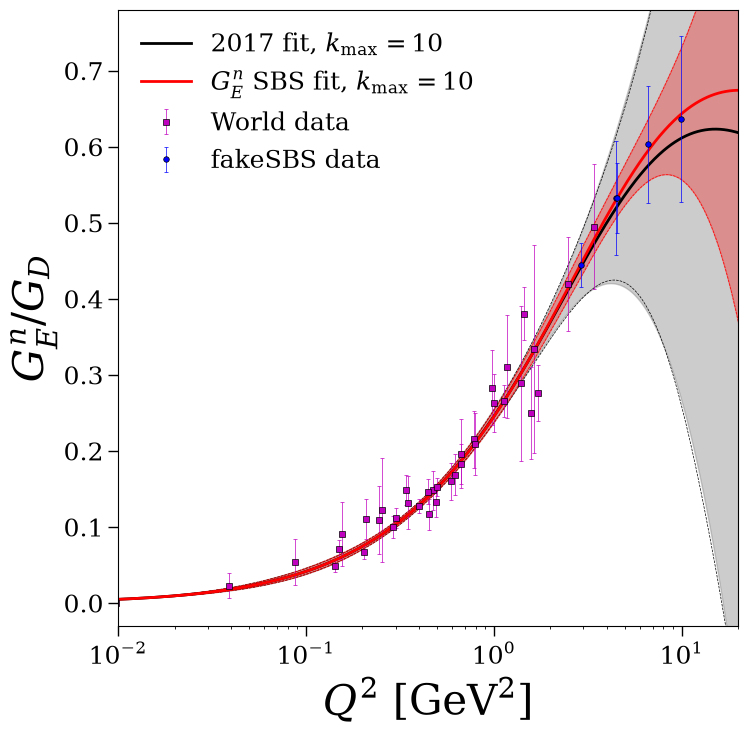

In [24]:
## GEn vs Q2
ymin1 =-0.03
ymax1 = 0.78 
Q2plot1=100

com1 = r'World data' #John's 2007 paper
com2 = r'2017 fit, $k_{\max}=10$'
com3 = r'$G_E^n$ SBS fit, $k_{\max}=10$'
com4 = r'fakeHQ data'
com5 = r'fakeSBS data'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=18)

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,7))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#########2017 world Fit{{{
axes.plot(Q2n, GEn_fit_rat, 'k-', linewidth=2,  label=com2)
axes.fill_between(Q2n, GEn_neg_rat, GEn_pos_rat, edgecolor='gray',facecolor='gray',alpha=0.4)
axes.plot(Q2n, GEn_fit_rat-dGEGDn, 'k--', linewidth=0.5)
axes.plot(Q2n, GEn_fit_rat+dGEGDn, 'k--', linewidth=0.5)
#}}}

#########world data point{{{
axes.errorbar(Q2e_data_sr, GErat_data_sr, yerr=dGErat_data_sr,fmt='s', color='m', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com1)
#}}}

#########world+SBS Fit{{{
axes.plot(Q2_SBS, GEn_fit_rat_SBS_cali, 'r-', linewidth=2,  label=com3)
axes.fill_between(Q2_SBS, GEn_neg_rat_SBS_cali, GEn_pos_rat_SBS_cali, edgecolor='r',facecolor='r',alpha=0.3)
axes.plot(Q2_SBS, GEn_fit_rat_SBS_cali-dGEGDn_SBS_cali, 'r--', linewidth=0.5)
axes.plot(Q2_SBS, GEn_fit_rat_SBS_cali+dGEGDn_SBS_cali, 'r--', linewidth=0.5)
#}}}

#########SBS fake data point{{{
axes.errorbar(Q2_SBS_sr, GEGD_SBS_sr, yerr=dGEGD_SBS_sr,color='b', fmt='o', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5,  label=com5)
#}}}

#axes.set_xlim(Q2_min,1000.)
axes.set_xlim(Q2_min,Q2_max2)
axes.set_ylim(ymin1,ymax1)
axes.set_xscale('log')
axes.set_ylabel('$G_E^n/G_{D}$', fontsize=30) # label, y-axis
axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30) # label, x-axis

axes.xaxis.set_tick_params(width=1,length=7)
axes.yaxis.set_tick_params(width=1,length=7)
plt.tick_params(labelsize=18)
axes.legend(loc='best', fontsize=18, frameon=False)
# plt.savefig('Neutron_GEGD_New.pdf', bbox_inches='tight')
plt.savefig('Neutron_GEGD_SBS.png', bbox_inches='tight')
#plt.savefig('Neutron_GEGD.eps', bbox_inches='tight')

## Plot $G^n_M$

### vs Q2

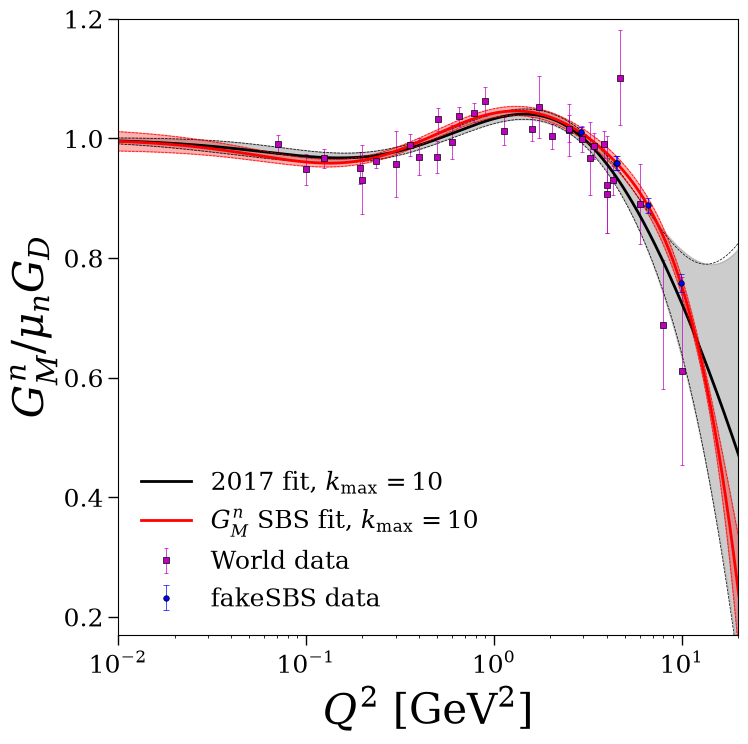

In [25]:
## Plotting GMn

ymin1 = 0.17
ymax1 = 1.2
Q2plot1=100

com1 = r'World data' #John's 2007 paper
com2 = r'2017 fit, $k_{\max}=10$'
com3 = r'$G_M^n$ SBS fit, $k_{\max}=10$'
com4 = r'fakeHQ data'
com5 = r'fakeSBS data'

font_prop = font_manager.FontProperties( size=12)
font_prop1 = font_manager.FontProperties( size=18)

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,7))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#########world data point{{{
axes.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr,fmt='s', color='m', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=1.5, capthick=0.5, elinewidth=0.5, label=com1)
#}}}

#########2017 world Fit{{{
axes.plot(Q2n, GMn_fit_rat, 'k-', linewidth=2,  label=com2)
axes.fill_between(Q2n, GMn_neg_rat, GMn_pos_rat, edgecolor='gray',facecolor='gray',alpha=0.4)
axes.plot(Q2n, GMn_fit_rat-dGMGDn, 'k--', linewidth=0.5)
axes.plot(Q2n, GMn_fit_rat+dGMGDn, 'k--', linewidth=0.5)
#}}}

#########world+SBS Fit{{{
axes.plot(Q2_SBS_GMn, GMn_fit_rat_SBS_cali, 'r-', linewidth=2,  label=com3)
axes.fill_between(Q2_SBS_GMn, GMn_neg_rat_SBS_cali, GMn_pos_rat_SBS_cali, edgecolor='r',facecolor='r',alpha=0.3)
axes.plot(Q2_SBS_GMn, GMn_fit_rat_SBS_cali-dGMGDn_SBS_cali, 'r--', linewidth=0.5)
axes.plot(Q2_SBS_GMn, GMn_fit_rat_SBS_cali+dGMGDn_SBS_cali, 'r--', linewidth=0.5)
#}}}

#########SBS fake data point{{{
axes.errorbar(Q2_SBS_sr, GMGD_SBS_sr, yerr=dGMGD_SBS_sr,color='b', fmt='o', markersize=4, markeredgewidth=0.5, markeredgecolor='black', capsize=2.0, capthick=0.5, elinewidth=0.5,  label=com5)
#}}}


#axes.set_xlim(Q2_min,1000.)
axes.set_xlim(Q2_min,Q2_max2)
axes.set_ylim(ymin1,ymax1)
axes.set_xscale('log')
axes.set_ylabel('$G_M^n/\mu_n G_{D}$', fontsize=30) # label, y-axis
axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30) # label, x-axis

axes.xaxis.set_tick_params(width=1,length=7)
axes.yaxis.set_tick_params(width=1,length=7)
plt.tick_params(labelsize=18)
axes.legend(loc='best', fontsize=18, frameon=False)
# plt.savefig('Neutron_GMGD_New.pdf', bbox_inches='tight')
plt.savefig('Neutron_GMGD_SBS.png', bbox_inches='tight')
#plt.savefig('Neutron_GMGD.eps', bbox_inches='tight')

## Plot $F_1^n$ and $F_2^n$

In [ ]:
## Calculate neutron F1 and F2 arrays ####################################{{{

# ----------------------------------------------------------------------
# Neutron constants
# ----------------------------------------------------------------------
mu_n = GMn0
kappa_n = GMn0


# ----------------------------------------------------------------------
# Helper: convert ratio arrays to F1, F2 arrays
# Input:
#   GE_ratio    = GE^n / GD
#   dGE_ratio   = uncertainty of GE^n / GD
#   GM_ratio    = GM^n / (mu_n * GD)
#   dGM_ratio   = uncertainty of GM^n / (mu_n * GD)
# ----------------------------------------------------------------------
def calc_neutron_F1F2(Q2_arr, GE_ratio, dGE_ratio, GM_ratio, dGM_ratio,
                      label='set', debug=False):

    # Convert to numpy arrays
    Q2_arr = np.asarray(Q2_arr)
    GE_ratio = np.asarray(GE_ratio)
    dGE_ratio = np.asarray(dGE_ratio)
    GM_ratio = np.asarray(GM_ratio)
    dGM_ratio = np.asarray(dGM_ratio)

    # Basic shape check
    n = len(Q2_arr)
    if not (len(GE_ratio) == len(dGE_ratio) == len(GM_ratio) == len(dGM_ratio) == n):
        raise ValueError(
            f'[{label}] Array length mismatch: '
            f'len(Q2)={len(Q2_arr)}, len(GE_ratio)={len(GE_ratio)}, '
            f'len(dGE_ratio)={len(dGE_ratio)}, len(GM_ratio)={len(GM_ratio)}, '
            f'len(dGM_ratio)={len(dGM_ratio)}'
        )

    gd = GD(Q2_arr)
    tau = Q2_arr / (4.0 * Mass_n**2)

    # Recover physical Sachs form factors
    GE = GE_ratio * gd
    dGE = np.abs(dGE_ratio * gd)

    GM = GM_ratio * mu_n * gd
    dGM = np.abs(dGM_ratio * mu_n * gd)

    # Dirac and Pauli form factors; normalize F2 by kappa_n as in the proton plot
    F1 = (GE + tau * GM) / (1.0 + tau)
    F2 = (GM - GE) / (kappa_n * (1.0 + tau))

    # Error propagation assuming GE and GM are uncorrelated
    dF1 = np.sqrt(dGE**2 + (tau * dGM)**2) / (1.0 + tau)
    dF2 = np.sqrt(dGE**2 + dGM**2) / (abs(kappa_n) * (1.0 + tau))

    if debug:
        debug_print_samples(
            label,
            Q2_arr, GE_ratio, dGE_ratio, GM_ratio, dGM_ratio,
            gd, tau, GE, dGE, GM, dGM, F1, dF1, F2, dF2
        )

    return F1, dF1, F2, dF2


# ----------------------------------------------------------------------
# 1) 2017 Fit (set 1)
# ----------------------------------------------------------------------
F1n_fit, dF1n_fit, F2n_fit, dF2n_fit = calc_neutron_F1F2(
    Q2n,
    GEn_fit_rat, dGEGDn,
    GMn_fit_rat, dGMGDn,
    label='2017 Fit (set 1)',
    debug=True
)


# ----------------------------------------------------------------------
# 2) Tyler: replace only GMn with the SBS GMn result (set 2)
# ----------------------------------------------------------------------
F1n_SBS_GMn, dF1n_SBS_GMn, F2n_SBS_GMn, dF2n_SBS_GMn = calc_neutron_F1F2(
    Q2n,
    GEn_fit_rat, dGEGDn,
    GMn_fit_rat_SBS_cali, dGMGDn_SBS_cali,
    label='SBS GMn (set 2)',
    debug=True
)


# ----------------------------------------------------------------------
# 3) Haocen: replace GEn on top of Tyler's SBS GMn result (set 3)
# ----------------------------------------------------------------------
F1n_SBS_fit, dF1n_SBS_fit, F2n_SBS_fit, dF2n_SBS_fit = calc_neutron_F1F2(
    Q2_SBS,
    GEn_fit_rat_SBS_cali, dGEGDn_SBS_cali,
    GMn_fit_rat_SBS_cali, dGMGDn_SBS_cali,
    label='SBS Fit (set 3)',
    debug=True
)

#}}}

In [ ]:
## Plot neutron F1 and F2 ################################################{{{

# ----------------------------------------------------------------------
# Plot settings
# ----------------------------------------------------------------------
com1 = r'2017 Fit (set 1)'
com2 = r'SBS $G_M^n$ (set 2)'
com3 = r'SBS Fit (set 3)'

ymin_F1n = -0.05
ymax_F1n = 0.01

ymin_F2n = -0.05
ymax_F2n = 1.10

f1, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 24), sharex='col')
f1.subplots_adjust(left=0.09, right=0.98, bottom=0.06, top=0.98, hspace=0.12, wspace=0.22)


# ----------------------------------------------------------------------
# Helper: central line, uncertainty boundaries, and uncertainty band
# ----------------------------------------------------------------------
def plot_neutron_F1F2_band(axis, Q2_arr, values, errors,
                           color, label, alpha, band_color=None):
    if band_color is None:
        band_color = color

    axis.plot(Q2_arr, values, color=color, linewidth=2, label=label)
    axis.plot(Q2_arr, values + errors, color=color, linestyle='--', linewidth=0.5)
    axis.plot(Q2_arr, values - errors, color=color, linestyle='--', linewidth=0.5)
    axis.fill_between(
        Q2_arr, values - errors, values + errors,
        edgecolor=band_color, facecolor=band_color, alpha=alpha
    )


# ======================================================================
# Row 1: 2017 Fit (set 1)
# ======================================================================
plot_neutron_F1F2_band(
    axes[0,0], Q2n, F1n_fit, dF1n_fit,
    color='k', label=com1, alpha=0.4, band_color='gray'
)
plot_neutron_F1F2_band(
    axes[0,1], Q2n, F2n_fit, dF2n_fit,
    color='k', label=com1, alpha=0.4, band_color='gray'
)
axes[0,0].text(0.67, 0.50, r'2017 Fit', transform=axes[0,0].transAxes, fontsize=18)
axes[0,1].text(0.67, 0.50, r'2017 Fit', transform=axes[0,1].transAxes, fontsize=18)


# ======================================================================
# Row 2: SBS GMn (set 2)
# ======================================================================
plot_neutron_F1F2_band(
    axes[1,0], Q2n, F1n_SBS_GMn, dF1n_SBS_GMn,
    color='b', label=com2, alpha=0.3
)
plot_neutron_F1F2_band(
    axes[1,1], Q2n, F2n_SBS_GMn, dF2n_SBS_GMn,
    color='b', label=com2, alpha=0.3
)
axes[1,0].text(0.67, 0.50, r'SBS $G_M^n$', transform=axes[1,0].transAxes, fontsize=18)
axes[1,1].text(0.67, 0.50, r'SBS $G_M^n$', transform=axes[1,1].transAxes, fontsize=18)


# ======================================================================
# Row 3: SBS Fit (set 3)
# ======================================================================
plot_neutron_F1F2_band(
    axes[2,0], Q2_SBS, F1n_SBS_fit, dF1n_SBS_fit,
    color='r', label=com3, alpha=0.3
)
plot_neutron_F1F2_band(
    axes[2,1], Q2_SBS, F2n_SBS_fit, dF2n_SBS_fit,
    color='r', label=com3, alpha=0.3
)
axes[2,0].text(0.67, 0.50, r'SBS Fit', transform=axes[2,0].transAxes, fontsize=18)
axes[2,1].text(0.67, 0.50, r'SBS Fit', transform=axes[2,1].transAxes, fontsize=18)


# ======================================================================
# Row 4: all three sets
# ======================================================================
plot_neutron_F1F2_band(
    axes[3,0], Q2n, F1n_fit, dF1n_fit,
    color='k', label=com1, alpha=0.20
)
plot_neutron_F1F2_band(
    axes[3,0], Q2n, F1n_SBS_GMn, dF1n_SBS_GMn,
    color='b', label=com2, alpha=0.15
)
plot_neutron_F1F2_band(
    axes[3,0], Q2_SBS, F1n_SBS_fit, dF1n_SBS_fit,
    color='r', label=com3, alpha=0.15
)

plot_neutron_F1F2_band(
    axes[3,1], Q2n, F2n_fit, dF2n_fit,
    color='k', label=com1, alpha=0.20
)
plot_neutron_F1F2_band(
    axes[3,1], Q2n, F2n_SBS_GMn, dF2n_SBS_GMn,
    color='b', label=com2, alpha=0.15
)
plot_neutron_F1F2_band(
    axes[3,1], Q2_SBS, F2n_SBS_fit, dF2n_SBS_fit,
    color='r', label=com3, alpha=0.15
)
axes[3,0].text(0.67, 0.50, r'All Sets', transform=axes[3,0].transAxes, fontsize=18)
axes[3,1].text(0.67, 0.50, r'All Sets', transform=axes[3,1].transAxes, fontsize=18)


# ======================================================================
# Common axis formatting
# ======================================================================
for r in range(0, 4):
    for c in range(0, 2):
        axes[r,c].set_xlim(Q2_min, 100.0)
        axes[r,c].set_xscale('log')
        axes[r,c].xaxis.set_tick_params(width=1, length=7)
        axes[r,c].yaxis.set_tick_params(width=1, length=7)
        axes[r,c].tick_params(labelsize=18)
        axes[r,c].legend(loc='best', fontsize=14, frameon=False)

    axes[r,0].set_ylim(ymin_F1n, ymax_F1n)
    axes[r,0].set_ylabel(r'$F_1^n$', fontsize=24)

    axes[r,1].set_ylim(ymin_F2n, ymax_F2n)
    axes[r,1].set_ylabel(r'$F_2^n$', fontsize=24)

axes[3,0].set_xlabel(r'$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24)
axes[3,1].set_xlabel(r'$Q^2$ $[\mathrm{GeV}^2]$', fontsize=24)

plt.savefig('Neutron_F1F2_4x2_SBS.png', bbox_inches='tight')
# plt.savefig('Neutron_F1F2_4x2_SBS.pdf', bbox_inches='tight')

#}}}

# Flavor Separation
If only considering the u and d quark contributions, we have:
$$G^p_E = 2/3 G^u_E  - 1/3 G^d_E, G^n_E = 2/3 G^d_E - 1/3 G^u_E,$$
which gives:
$$G^u_E = 2G^p_E + G^n_E,\delta G^u_E = \sqrt{(2\delta G^p_E)^2+(\delta G^n_E)^2 }$$
$$G^d_E = 2G^n_E + G^p_E,\delta G^d_E = \sqrt{(2\delta G^n_E)^2+(\delta G^p_E)^2 }.$$

Similarly, for magnetic form factors, we just replace "E" by "M". 
   
   $F_{1/2}^{p/n}$ are calculated based on: 
    $$F_1^p =  \frac{G_E^p + \frac{Q^2}{4 M_p^2} G_M^p}{1+\frac{Q^2}{4 M_p^2}},  
    \delta F_1^p =  \frac{\sqrt{(\delta G_E^p)^2 + (\frac{Q^2}{4 M_p^2} \delta G_M^p)^2}}{1+\frac{Q^2}{4 M_p^2}}$$
    $$ F_2^p = -\frac{G_E^p - G_M^p}{ 1+\frac{Q^2}{4 M_p^2}}, 
    \delta F_2^p =  \frac{\sqrt{(\delta G_E^p)^2 + (\delta G_M^p)^2}}{1+\frac{Q^2}{4 M_p^2}}$$

    
A similar approach was performed to extract $F_{1/2}^{u/d}$ like $G_{E/M}^{p/n}$

## Calcualte $G_{E/M}^{u/d}$ and $F_{1/2}^{u/d}$  of u and d-quarks

## 2019 PLB （Set 1）

In [26]:
## Load Data
KAPPA_U = 1.67
KAPPA_D = -2.03

GEn0 = 0
GEu0 = (2.*GEp0 + GEn0)
GMu0 = (2.*GMp0 + GMn0)
GEd0 = (2.*GEn0 + GEp0)
GMd0 = (2.*GMn0 + GMp0)

F1p0 = GEp0
F2p0 = -(GEp0 - GMp0)
F1n0 = GEn0
F2n0 = -(GEn0 - GMn0)

F1u0 = (2.*F1p0 + F1n0)
F2u0 = (2.*F2p0 + F2n0)
F1d0 = (2.*F1n0 + F1p0)
F2d0 = (2.*F2n0 + F2p0)

N=len(Q2)
print("N = ", N)
GEu = np.zeros(N, dtype=float)
GEd = np.zeros(N, dtype=float)
GMu = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)
dGEu = np.zeros(N, dtype=float)
dGEd = np.zeros(N, dtype=float)
dGMu = np.zeros(N, dtype=float)
dGMd = np.zeros(N, dtype=float)

GEu_rat = np.zeros(N, dtype=float)
GEd_rat = np.zeros(N, dtype=float)
GMu_rat = np.zeros(N, dtype=float)
GMd_rat = np.zeros(N, dtype=float)
dGEu_rat = np.zeros(N, dtype=float)
dGEd_rat = np.zeros(N, dtype=float)
dGMu_rat = np.zeros(N, dtype=float)
dGMd_rat = np.zeros(N, dtype=float)

GEGMu = np.zeros(N, dtype=float)
GEGMd = np.zeros(N, dtype=float)
dGEGMu = np.zeros(N, dtype=float)
dGEGMd = np.zeros(N, dtype=float)

F1p = np.zeros(N, dtype=float)
F2p = np.zeros(N, dtype=float)
dF1p = np.zeros(N, dtype=float)
dF2p = np.zeros(N, dtype=float)
F1n = np.zeros(N, dtype=float)
F2n = np.zeros(N, dtype=float)
dF1n = np.zeros(N, dtype=float)
dF2n = np.zeros(N, dtype=float)

F1u = np.zeros(N, dtype=float)
F1d = np.zeros(N, dtype=float)
F2u = np.zeros(N, dtype=float)
F2d = np.zeros(N, dtype=float)
dF1u = np.zeros(N, dtype=float)
dF1d = np.zeros(N, dtype=float)
dF2u = np.zeros(N, dtype=float)
dF2d = np.zeros(N, dtype=float)

F1u_rat = np.zeros(N, dtype=float)
F1d_rat = np.zeros(N, dtype=float)
F2u_rat = np.zeros(N, dtype=float)
F2d_rat = np.zeros(N, dtype=float)
dF1u_rat = np.zeros(N, dtype=float)
dF1d_rat = np.zeros(N, dtype=float)
dF2u_rat = np.zeros(N, dtype=float)
dF2d_rat = np.zeros(N, dtype=float)

F1F2u = np.zeros(N, dtype=float)
F1F2d = np.zeros(N, dtype=float)
dF1F2u = np.zeros(N, dtype=float)
dF1F2d = np.zeros(N, dtype=float)

F1uF1d = np.zeros(N, dtype=float)
F2uF2d = np.zeros(N, dtype=float)
dF1uF1d = np.zeros(N, dtype=float)
dF2uF2d = np.zeros(N, dtype=float)



of = open('F1F2_neutron.dat', 'w')
for i in range(0,N):
    GEu[i] =  (2.*GE_fit[i] + GEn_fit[i])
    dGEu[i] = sqrt( (2.*(GE_pos[i]-GE_fit[i]))**2 
                            + (1.*(GEn_pos[i]-GEn_fit[i]))**2 )
   
    GEd[i] =  (2.*GEn_fit[i] + GE_fit[i]) 
    dGEd[i] = sqrt( (2.*(GEn_pos[i]-GEn_fit[i]))**2 
                            + (1.*(GE_pos[i]-GE_fit[i]))**2 )

    GMu[i] =  (2.*GM_fit[i] + GMn_fit[i])
    dGMu[i] = sqrt( (2.*(GM_pos[i]-GM_fit[i]))**2 
                            + (1.*(GMn_pos[i]-GMn_fit[i]))**2 )
  
    GMd[i] =  (2.*GMn_fit[i] + GM_fit[i])
    dGMd[i] = sqrt( (2.*(GMn_pos[i]-GMn_fit[i]))**2 
                            + (1.*(GM_pos[i]-GM_fit[i]))**2 )
   
    Gdip = 1./(1.+Q2[i]/0.71)**2
    GEu_rat[i] = GEu[i]/(GEu0*Gdip)
    dGEu_rat[i] = dGEu[i]/(GEu0*Gdip)
    GEd_rat[i] = GEd[i]/(GEd0*Gdip)
    dGEd_rat[i] = dGEd[i]/(GEd0*Gdip)
    
    GMu_rat[i] = GMu[i]/(GMu0*Gdip)
    dGMu_rat[i] = dGMu[i]/(GMu0*Gdip)
    GMd_rat[i] = GMd[i]/(GMd0*Gdip)
    dGMd_rat[i] = dGMd[i]/(GMd0*Gdip)
    
    GEGMu[i] = GEu[i]/GMu[i]
    dGEGMu[i] = GEGMu[i] * sqrt( (dGEu[i]/GEu[i])**2 + (dGMu[i]/GMu[i])**2)
    GEGMd[i] = GEd[i]/GMd[i]
    dGEGMd[i] = GEGMd[i] * sqrt( (dGEd[i]/GEd[i])**2 + (dGMd[i]/GMd[i])**2)
    
    F1p[i] = (GE_fit[i] + Q2[i]/4.0/(Mass_p**2) * GM_fit[i]) / (1.+Q2[i]/4.0/(Mass_p**2))
    F2p[i] = -(GE_fit[i] - GM_fit[i]) / (1.+Q2[i]/4.0/(Mass_p**2))
      
    dF1p[i] = sqrt(  (1.*(GE_pos[i]-GE_fit[i]))**2 
                            + (Q2[i]/4.0/(Mass_p**2)*(GM_pos[i]-GM_fit[i]))**2 )/ (1.+Q2[i]/4.0/(Mass_p**2))
    
    dF2p[i] = sqrt(  (1.*(GE_pos[i]-GE_fit[i]))**2 
                            + (1.*(GM_pos[i]-GM_fit[i]))**2 )/ (1.+Q2[i]/4.0/(Mass_p**2))
    
    F1n[i] = (GEn_fit[i] + Q2[i]/4.0/(Mass_n**2) * GMn_fit[i]) / (1.+Q2[i]/4.0/(Mass_n**2))
    F2n[i] = -(GEn_fit[i] - GMn_fit[i]) / (1.+Q2[i]/4.0/(Mass_n**2))
   
    dF1n[i] = sqrt(  (1.*(GEn_pos[i]-GEn_fit[i]))**2 
                            + (Q2[i]/4.0/(Mass_n**2)*(GMn_pos[i]-GMn_fit[i]))**2) / (1.+Q2[i]/4.0/(Mass_n**2))

    dF2n[i] = sqrt(  (1.*(GEn_pos[i]-GEn_fit[i]))**2 
                            + (1.*(GMn_pos[i]-GMn_fit[i]))**2) / (1.+Q2[i]/4.0/(Mass_n**2))    
       
    F1u[i] =  (2.*F1p[i] + F1n[i])
    F2u[i] =  (2.*F2p[i] + F2n[i])
    dF1u[i] = sqrt( (2.*dF1p[i])**2 + (1.*dF1n[i])**2   )
    dF2u[i] = sqrt( (2.*dF2p[i])**2 + (1.*dF2n[i])**2   )

    F1d[i] =  (2.*F1n[i] + F1p[i])
    F2d[i] =  (2.*F2n[i] + F2p[i])
    dF1d[i] = sqrt( (2.*dF1n[i])**2 + (1.*dF1p[i])**2   )
    dF2d[i] = sqrt( (2.*dF2n[i])**2 + (1.*dF2p[i])**2   )
  
    F1u_rat[i] = F1u[i] * Q2[i]**2
    dF1u_rat[i] = dF1u[i] * Q2[i]**2
    F1d_rat[i] = F1d[i] * Q2[i]**2
    dF1d_rat[i] = dF1d[i] * Q2[i]**2
    F2u_rat[i] = F2u[i]  * Q2[i]**2 /KAPPA_U
    dF2u_rat[i] = dF2u[i]  * Q2[i]**2 /KAPPA_U
    F2d_rat[i] = F2d[i]  * Q2[i]**2 /KAPPA_D
    dF2d_rat[i] = dF2d[i]  * Q2[i]**2 /KAPPA_D
    
    F1F2u[i] = F2u[i]/F1u[i]/KAPPA_U
    dF1F2u[i] = F1F2u[i] * sqrt( (dF1u[i]/F1u[i])**2 +(dF2u[i]/F2u[i])**2  )
    F1F2d[i] = F2d[i]/F1d[i]/KAPPA_D
    dF1F2d[i] = F1F2d[i] * sqrt( (dF1d[i]/F1d[i])**2 +(dF2d[i]/F2d[i])**2  )

    F1uF1d[i] = F1d[i]/F1u[i]
    dF1uF1d[i] = F1uF1d[i] * sqrt( (dF1u[i]/F1u[i])**2 +(dF1d[i]/F1d[i])**2  )
    F2uF2d[i] = F2d[i]/F2u[i]
    dF2uF2d[i] = F2uF2d[i] * sqrt( (dF2u[i]/F2u[i])**2 +(dF2d[i]/F2d[i])**2  )
    
#     F1u_rat[i] = F1u[i]/(F1u0*Gdip)
#     dF1u_rat[i] = dF1u[i]/(F1u0*Gdip)
#     F1d_rat[i] = F1d[i]/(F1d0*Gdip)
#     dF1d_rat[i] = dF1d[i]/(F1d0*Gdip)
    
#     F2u_rat[i] = F2u[i]/(F2u0*Gdip)
#     dF2u_rat[i] = dF2u[i]/(F2u0*Gdip)
#     F2d_rat[i] = F2d[i]/(F2d0*Gdip)
#     dF2d_rat[i] = dF2d[i]/(F2d0*Gdip)



N =  2000


## 2019 PLB + Tyler's GMn SBSproj (set 2)

In [27]:
# --- Set2: replace GMn by SBS calibrated results ---

GEu_set2  = np.zeros(N, dtype=float)
GEd_set2  = np.zeros(N, dtype=float)
GMu_set2  = np.zeros(N, dtype=float)
GMd_set2  = np.zeros(N, dtype=float)
dGEu_set2 = np.zeros(N, dtype=float)
dGEd_set2 = np.zeros(N, dtype=float)
dGMu_set2 = np.zeros(N, dtype=float)
dGMd_set2 = np.zeros(N, dtype=float)

GEu_rat_set2  = np.zeros(N, dtype=float)
GEd_rat_set2  = np.zeros(N, dtype=float)
GMu_rat_set2  = np.zeros(N, dtype=float)
GMd_rat_set2  = np.zeros(N, dtype=float)
dGEu_rat_set2 = np.zeros(N, dtype=float)
dGEd_rat_set2 = np.zeros(N, dtype=float)
dGMu_rat_set2 = np.zeros(N, dtype=float)
dGMd_rat_set2 = np.zeros(N, dtype=float)

GEGMu_set2  = np.zeros(N, dtype=float)
GEGMd_set2  = np.zeros(N, dtype=float)
dGEGMu_set2 = np.zeros(N, dtype=float)
dGEGMd_set2 = np.zeros(N, dtype=float)

F1p_set2  = np.zeros(N, dtype=float)
F2p_set2  = np.zeros(N, dtype=float)
dF1p_set2 = np.zeros(N, dtype=float)
dF2p_set2 = np.zeros(N, dtype=float)
F1n_set2  = np.zeros(N, dtype=float)
F2n_set2  = np.zeros(N, dtype=float)
dF1n_set2 = np.zeros(N, dtype=float)
dF2n_set2 = np.zeros(N, dtype=float)

F1u_set2  = np.zeros(N, dtype=float)
F1d_set2  = np.zeros(N, dtype=float)
F2u_set2  = np.zeros(N, dtype=float)
F2d_set2  = np.zeros(N, dtype=float)
dF1u_set2 = np.zeros(N, dtype=float)
dF1d_set2 = np.zeros(N, dtype=float)
dF2u_set2 = np.zeros(N, dtype=float)
dF2d_set2 = np.zeros(N, dtype=float)

F1u_rat_set2  = np.zeros(N, dtype=float)
F1d_rat_set2  = np.zeros(N, dtype=float)
F2u_rat_set2  = np.zeros(N, dtype=float)
F2d_rat_set2  = np.zeros(N, dtype=float)
dF1u_rat_set2 = np.zeros(N, dtype=float)
dF1d_rat_set2 = np.zeros(N, dtype=float)
dF2u_rat_set2 = np.zeros(N, dtype=float)
dF2d_rat_set2 = np.zeros(N, dtype=float)

F1F2u_set2  = np.zeros(N, dtype=float)
F1F2d_set2  = np.zeros(N, dtype=float)
dF1F2u_set2 = np.zeros(N, dtype=float)
dF1F2d_set2 = np.zeros(N, dtype=float)

F1uF1d_set2  = np.zeros(N, dtype=float)
F2uF2d_set2  = np.zeros(N, dtype=float)
dF1uF1d_set2 = np.zeros(N, dtype=float)
dF2uF2d_set2 = np.zeros(N, dtype=float)

for i in range(0, N):

    # Uncertainties (upper envelope)
    dGEp = abs(GE_pos[i]  - GE_fit[i])
    dGMp = abs(GM_pos[i]  - GM_fit[i])
    dGEn = abs(GEn_pos[i] - GEn_fit[i])

    # Use calibrated GMn from SBS
    GMn_fit_use = GMn_fit_SBS_cali[i]
    dGMn_use = abs(GMn_pos_SBS_cali[i] - GMn_fit_SBS_cali[i])

    # Flavor separation (Sachs)
    GEu_set2[i]  = 2.*GE_fit[i] + GEn_fit[i]
    dGEu_set2[i] = sqrt((2.*dGEp)**2 + (1.*dGEn)**2)

    GEd_set2[i]  = 2.*GEn_fit[i] + GE_fit[i]
    dGEd_set2[i] = sqrt((2.*dGEn)**2 + (1.*dGEp)**2)

    GMu_set2[i]  = 2.*GM_fit[i] + GMn_fit_use
    dGMu_set2[i] = sqrt((2.*dGMp)**2 + (1.*dGMn_use)**2)

    GMd_set2[i]  = 2.*GMn_fit_use + GM_fit[i]
    dGMd_set2[i] = sqrt((2.*dGMn_use)**2 + (1.*dGMp)**2)

    Gdip = 1./(1.+Q2[i]/0.71)**2
    GEu_rat_set2[i]  = GEu_set2[i]/(GEu0*Gdip)
    dGEu_rat_set2[i] = dGEu_set2[i]/(GEu0*Gdip)
    GEd_rat_set2[i]  = GEd_set2[i]/(GEd0*Gdip)
    dGEd_rat_set2[i] = dGEd_set2[i]/(GEd0*Gdip)

    GMu_rat_set2[i]  = GMu_set2[i]/(GMu0*Gdip)
    dGMu_rat_set2[i] = dGMu_set2[i]/(GMu0*Gdip)
    GMd_rat_set2[i]  = GMd_set2[i]/(GMd0*Gdip)
    dGMd_rat_set2[i] = dGMd_set2[i]/(GMd0*Gdip)

    GEGMu_set2[i]  = GEu_set2[i]/GMu_set2[i]
    dGEGMu_set2[i] = GEGMu_set2[i] * sqrt((dGEu_set2[i]/GEu_set2[i])**2 + (dGMu_set2[i]/GMu_set2[i])**2)
    GEGMd_set2[i]  = GEd_set2[i]/GMd_set2[i]
    dGEGMd_set2[i] = GEGMd_set2[i] * sqrt((dGEd_set2[i]/GEd_set2[i])**2 + (dGMd_set2[i]/GMd_set2[i])**2)

    tau_p = Q2[i]/4.0/(Mass_p**2)
    F1p_set2[i] = (GE_fit[i] + tau_p*GM_fit[i])/(1.+tau_p)
    F2p_set2[i] = -(GE_fit[i] - GM_fit[i])/(1.+tau_p)
    dF1p_set2[i] = sqrt((dGEp)**2 + (tau_p*dGMp)**2)/(1.+tau_p)
    dF2p_set2[i] = sqrt((dGEp)**2 + (dGMp)**2)/(1.+tau_p)

    tau_n = Q2[i]/4.0/(Mass_n**2)
    F1n_set2[i] = (GEn_fit[i] + tau_n*GMn_fit_use)/(1.+tau_n)
    F2n_set2[i] = -(GEn_fit[i] - GMn_fit_use)/(1.+tau_n)
    dF1n_set2[i] = sqrt((dGEn)**2 + (tau_n*dGMn_use)**2)/(1.+tau_n)
    dF2n_set2[i] = sqrt((dGEn)**2 + (dGMn_use)**2)/(1.+tau_n)

    F1u_set2[i] = 2.*F1p_set2[i] + F1n_set2[i]
    F2u_set2[i] = 2.*F2p_set2[i] + F2n_set2[i]
    dF1u_set2[i] = sqrt((2.*dF1p_set2[i])**2 + (1.*dF1n_set2[i])**2)
    dF2u_set2[i] = sqrt((2.*dF2p_set2[i])**2 + (1.*dF2n_set2[i])**2)

    F1d_set2[i] = 2.*F1n_set2[i] + F1p_set2[i]
    F2d_set2[i] = 2.*F2n_set2[i] + F2p_set2[i]
    dF1d_set2[i] = sqrt((2.*dF1n_set2[i])**2 + (1.*dF1p_set2[i])**2)
    dF2d_set2[i] = sqrt((2.*dF2n_set2[i])**2 + (1.*dF2p_set2[i])**2)

    F1u_rat_set2[i] = F1u_set2[i]*Q2[i]**2
    dF1u_rat_set2[i] = dF1u_set2[i]*Q2[i]**2
    F1d_rat_set2[i] = F1d_set2[i]*Q2[i]**2
    dF1d_rat_set2[i] = dF1d_set2[i]*Q2[i]**2
    F2u_rat_set2[i] = F2u_set2[i]*Q2[i]**2/KAPPA_U
    dF2u_rat_set2[i] = dF2u_set2[i]*Q2[i]**2/KAPPA_U
    F2d_rat_set2[i] = F2d_set2[i]*Q2[i]**2/KAPPA_D
    dF2d_rat_set2[i] = dF2d_set2[i]*Q2[i]**2/KAPPA_D

    F1F2u_set2[i] = F2u_set2[i]/F1u_set2[i]/KAPPA_U
    dF1F2u_set2[i] = F1F2u_set2[i]*sqrt((dF1u_set2[i]/F1u_set2[i])**2 + (dF2u_set2[i]/F2u_set2[i])**2)
    F1F2d_set2[i] = F2d_set2[i]/F1d_set2[i]/KAPPA_D
    dF1F2d_set2[i] = F1F2d_set2[i]*sqrt((dF1d_set2[i]/F1d_set2[i])**2 + (dF2d_set2[i]/F2d_set2[i])**2)

    F1uF1d_set2[i] = F1d_set2[i]/F1u_set2[i]
    dF1uF1d_set2[i] = F1uF1d_set2[i]*sqrt((dF1u_set2[i]/F1u_set2[i])**2 + (dF1d_set2[i]/F1d_set2[i])**2)
    F2uF2d_set2[i] = F2d_set2[i]/F2u_set2[i]
    dF2uF2d_set2[i] = F2uF2d_set2[i]*sqrt((dF2u_set2[i]/F2u_set2[i])**2 + (dF2d_set2[i]/F2d_set2[i])**2)

## SBS Fit (set3)

In [28]:
# --- Set3: use calibrated SBS results ---

GEu_set3  = np.zeros(N, dtype=float)
GEd_set3  = np.zeros(N, dtype=float)
GMu_set3  = np.zeros(N, dtype=float)
GMd_set3  = np.zeros(N, dtype=float)
dGEu_set3 = np.zeros(N, dtype=float)
dGEd_set3 = np.zeros(N, dtype=float)
dGMu_set3 = np.zeros(N, dtype=float)
dGMd_set3 = np.zeros(N, dtype=float)

GEu_rat_set3  = np.zeros(N, dtype=float)
GEd_rat_set3  = np.zeros(N, dtype=float)
GMu_rat_set3  = np.zeros(N, dtype=float)
GMd_rat_set3  = np.zeros(N, dtype=float)
dGEu_rat_set3 = np.zeros(N, dtype=float)
dGEd_rat_set3 = np.zeros(N, dtype=float)
dGMu_rat_set3 = np.zeros(N, dtype=float)
dGMd_rat_set3 = np.zeros(N, dtype=float)

GEGMu_set3  = np.zeros(N, dtype=float)
GEGMd_set3  = np.zeros(N, dtype=float)
dGEGMu_set3 = np.zeros(N, dtype=float)
dGEGMd_set3 = np.zeros(N, dtype=float)

F1p_set3  = np.zeros(N, dtype=float)
F2p_set3  = np.zeros(N, dtype=float)
dF1p_set3 = np.zeros(N, dtype=float)
dF2p_set3 = np.zeros(N, dtype=float)
F1n_set3  = np.zeros(N, dtype=float)
F2n_set3  = np.zeros(N, dtype=float)
dF1n_set3 = np.zeros(N, dtype=float)
dF2n_set3 = np.zeros(N, dtype=float)

F1u_set3  = np.zeros(N, dtype=float)
F1d_set3  = np.zeros(N, dtype=float)
F2u_set3  = np.zeros(N, dtype=float)
F2d_set3  = np.zeros(N, dtype=float)
dF1u_set3 = np.zeros(N, dtype=float)
dF1d_set3 = np.zeros(N, dtype=float)
dF2u_set3 = np.zeros(N, dtype=float)
dF2d_set3 = np.zeros(N, dtype=float)

F1u_rat_set3  = np.zeros(N, dtype=float)
F1d_rat_set3  = np.zeros(N, dtype=float)
F2u_rat_set3  = np.zeros(N, dtype=float)
F2d_rat_set3  = np.zeros(N, dtype=float)
dF1u_rat_set3 = np.zeros(N, dtype=float)
dF1d_rat_set3 = np.zeros(N, dtype=float)
dF2u_rat_set3 = np.zeros(N, dtype=float)
dF2d_rat_set3 = np.zeros(N, dtype=float)

F1F2u_set3  = np.zeros(N, dtype=float)
F1F2d_set3  = np.zeros(N, dtype=float)
dF1F2u_set3 = np.zeros(N, dtype=float)
dF1F2d_set3 = np.zeros(N, dtype=float)

F1uF1d_set3  = np.zeros(N, dtype=float)
F2uF2d_set3  = np.zeros(N, dtype=float)
dF1uF1d_set3 = np.zeros(N, dtype=float)
dF2uF2d_set3 = np.zeros(N, dtype=float)

for i in range(0, N):

    # Proton inputs (calibrated SBS)
    GEp_fit_use = GE_fit_SBS_cali[i]
    GMp_fit_use = GM_fit_SBS_cali[i]
    dGEp = abs(GE_pos_SBS_cali[i] - GE_fit_SBS_cali[i])
    dGMp = abs(GM_pos_SBS_cali[i] - GM_fit_SBS_cali[i])

    # Neutron GE from calibrated ratio (reconstruct absolute using GD)
    GEn_fit_use = GEn_fit_rat_SBS_cali[i] * GD_SBS[i]
    GEn_pos_use = GEn_pos_rat_SBS_cali[i] * GD_SBS[i]
    dGEn = abs(GEn_pos_use - GEn_fit_use)

    # Neutron GM inputs (calibrated SBS)
    GMn_fit_use = GMn_fit_SBS_cali[i]
    dGMn = abs(GMn_pos_SBS_cali[i] - GMn_fit_SBS_cali[i])

    # Flavor separation (Sachs)
    GEu_set3[i]  = 2.*GEp_fit_use + GEn_fit_use
    dGEu_set3[i] = sqrt((2.*dGEp)**2 + (1.*dGEn)**2)

    GEd_set3[i]  = 2.*GEn_fit_use + GEp_fit_use
    dGEd_set3[i] = sqrt((2.*dGEn)**2 + (1.*dGEp)**2)

    GMu_set3[i]  = 2.*GMp_fit_use + GMn_fit_use
    dGMu_set3[i] = sqrt((2.*dGMp)**2 + (1.*dGMn)**2)

    GMd_set3[i]  = 2.*GMn_fit_use + GMp_fit_use
    dGMd_set3[i] = sqrt((2.*dGMn)**2 + (1.*dGMp)**2)

    Gdip = 1./(1.+Q2[i]/0.71)**2
    GEu_rat_set3[i]  = GEu_set3[i]/(GEu0*Gdip)
    dGEu_rat_set3[i] = dGEu_set3[i]/(GEu0*Gdip)
    GEd_rat_set3[i]  = GEd_set3[i]/(GEd0*Gdip)
    dGEd_rat_set3[i] = dGEd_set3[i]/(GEd0*Gdip)

    GMu_rat_set3[i]  = GMu_set3[i]/(GMu0*Gdip)
    dGMu_rat_set3[i] = dGMu_set3[i]/(GMu0*Gdip)
    GMd_rat_set3[i]  = GMd_set3[i]/(GMd0*Gdip)
    dGMd_rat_set3[i] = dGMd_set3[i]/(GMd0*Gdip)

    GEGMu_set3[i]  = GEu_set3[i]/GMu_set3[i]
    dGEGMu_set3[i] = GEGMu_set3[i] * sqrt((dGEu_set3[i]/GEu_set3[i])**2 + (dGMu_set3[i]/GMu_set3[i])**2)
    GEGMd_set3[i]  = GEd_set3[i]/GMd_set3[i]
    dGEGMd_set3[i] = GEGMd_set3[i] * sqrt((dGEd_set3[i]/GEd_set3[i])**2 + (dGMd_set3[i]/GMd_set3[i])**2)

    tau_p = Q2[i]/4.0/(Mass_p**2)
    F1p_set3[i] = (GEp_fit_use + tau_p*GMp_fit_use)/(1.+tau_p)
    F2p_set3[i] = -(GEp_fit_use - GMp_fit_use)/(1.+tau_p)
    dF1p_set3[i] = sqrt((dGEp)**2 + (tau_p*dGMp)**2)/(1.+tau_p)
    dF2p_set3[i] = sqrt((dGEp)**2 + (dGMp)**2)/(1.+tau_p)

    tau_n = Q2[i]/4.0/(Mass_n**2)
    F1n_set3[i] = (GEn_fit_use + tau_n*GMn_fit_use)/(1.+tau_n)
    F2n_set3[i] = -(GEn_fit_use - GMn_fit_use)/(1.+tau_n)
    dF1n_set3[i] = sqrt((dGEn)**2 + (tau_n*dGMn)**2)/(1.+tau_n)
    dF2n_set3[i] = sqrt((dGEn)**2 + (dGMn)**2)/(1.+tau_n)

    F1u_set3[i] = 2.*F1p_set3[i] + F1n_set3[i]
    F2u_set3[i] = 2.*F2p_set3[i] + F2n_set3[i]
    dF1u_set3[i] = sqrt((2.*dF1p_set3[i])**2 + (1.*dF1n_set3[i])**2)
    dF2u_set3[i] = sqrt((2.*dF2p_set3[i])**2 + (1.*dF2n_set3[i])**2)

    F1d_set3[i] = 2.*F1n_set3[i] + F1p_set3[i]
    F2d_set3[i] = 2.*F2n_set3[i] + F2p_set3[i]
    dF1d_set3[i] = sqrt((2.*dF1n_set3[i])**2 + (1.*dF1p_set3[i])**2)
    dF2d_set3[i] = sqrt((2.*dF2n_set3[i])**2 + (1.*dF2p_set3[i])**2)

    F1u_rat_set3[i] = F1u_set3[i]*Q2[i]**2
    dF1u_rat_set3[i] = dF1u_set3[i]*Q2[i]**2
    F1d_rat_set3[i] = F1d_set3[i]*Q2[i]**2
    dF1d_rat_set3[i] = dF1d_set3[i]*Q2[i]**2
    F2u_rat_set3[i] = F2u_set3[i]*Q2[i]**2/KAPPA_U
    dF2u_rat_set3[i] = dF2u_rat_set3[i]*0.0 + dF2u_set3[i]*Q2[i]**2/KAPPA_U
    F2d_rat_set3[i] = F2d_set3[i]*Q2[i]**2/KAPPA_D
    dF2d_rat_set3[i] = dF2d_rat_set3[i]*0.0 + dF2d_set3[i]*Q2[i]**2/KAPPA_D

    F1F2u_set3[i] = F2u_set3[i]/F1u_set3[i]/KAPPA_U
    dF1F2u_set3[i] = F1F2u_set3[i]*sqrt((dF1u_set3[i]/F1u_set3[i])**2 + (dF2u_set3[i]/F2u_set3[i])**2)
    F1F2d_set3[i] = F2d_set3[i]/F1d_set3[i]/KAPPA_D
    dF1F2d_set3[i] = F1F2d_set3[i]*sqrt((dF1d_set3[i]/F1d_set3[i])**2 + (dF2d_set3[i]/F2d_set3[i])**2)

    F1uF1d_set3[i] = F1d_set3[i]/F1u_set3[i]
    dF1uF1d_set3[i] = F1uF1d_set3[i]*sqrt((dF1u_set3[i]/F1u_set3[i])**2 + (dF1d_set3[i]/F1d_set3[i])**2)
    F2uF2d_set3[i] = F2d_set3[i]/F2u_set3[i]
    dF2uF2d_set3[i] = F2uF2d_set3[i]*sqrt((dF2u_set3[i]/F2u_set3[i])**2 + (dF2d_set3[i]/F2d_set3[i])**2)

## Plotting u-quark and d-quark $G_E$

### vs Q2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


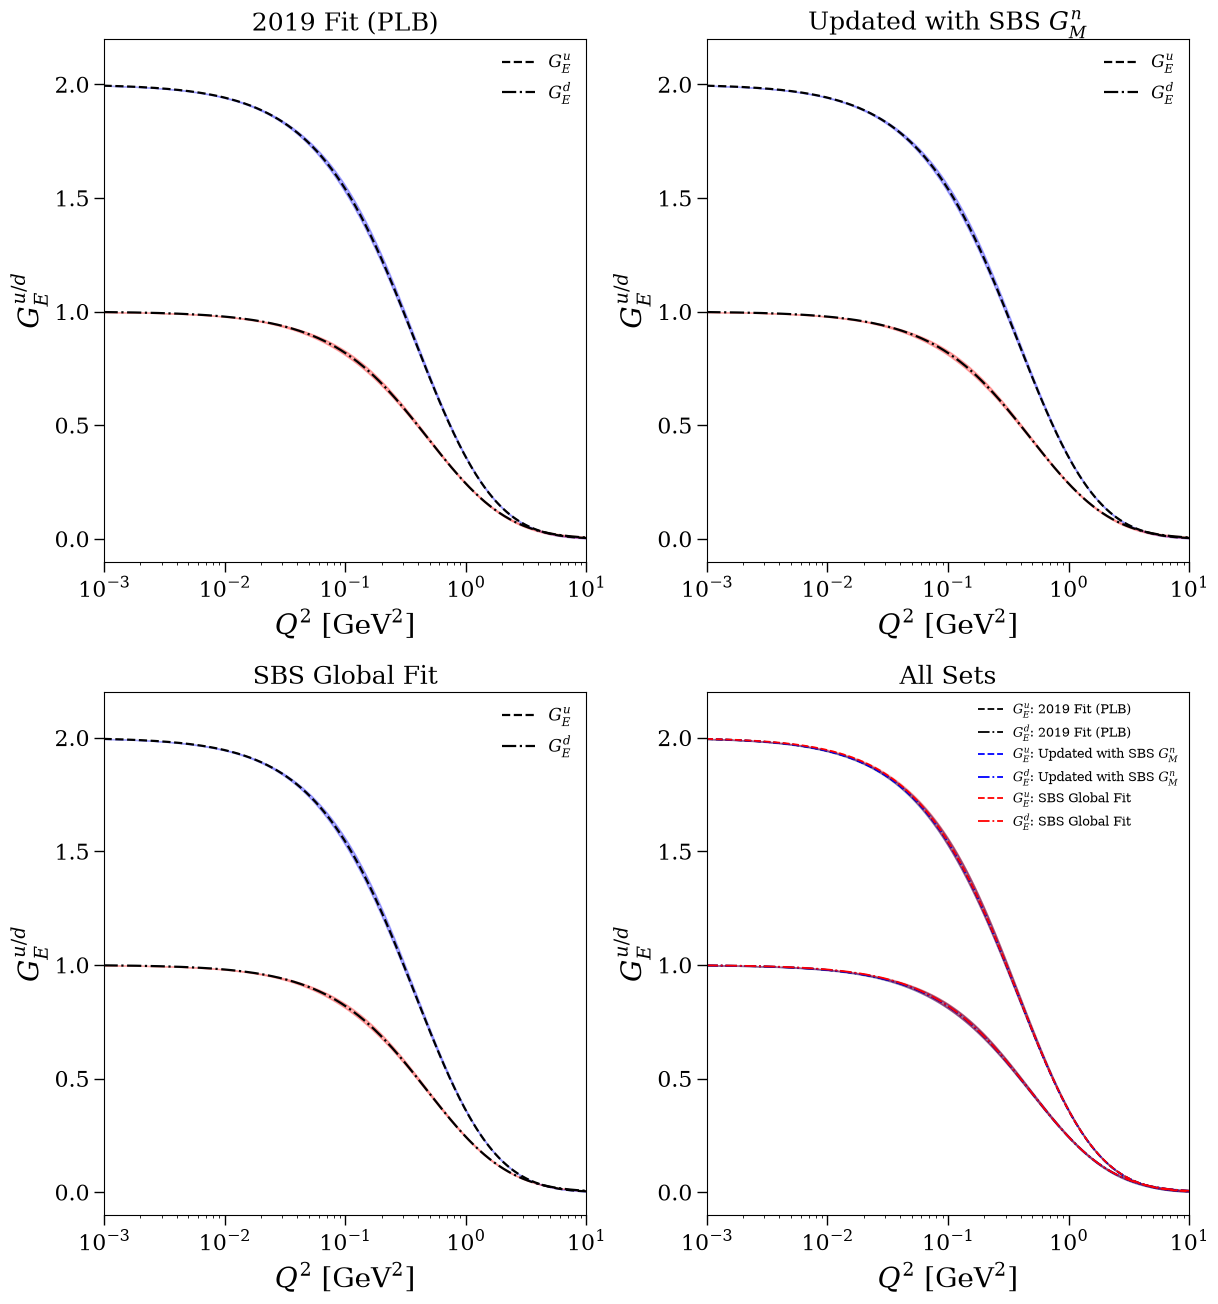

In [29]:
## GEu vs Q2 (4 panels in one page; overlay in bottom-right)
ymin1 = -0.1
ymax1 = 2.2
Q2plot1 = 10

com1u = r'$G_E^u$: 2019 Fit (PLB)'
com1d = r'$G_E^d$: 2019 Fit (PLB)'
com2u = r'$G_E^u$: Updated with SBS $G_M^n$'
com2d = r'$G_E^d$: Updated with SBS $G_M^n$'
com3u = r'$G_E^u$: SBS Global Fit'
com3d = r'$G_E^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,14))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, GEu, 'k--', linewidth=1.6, label=r'$G_E^u$')
ax[0,0].fill_between(Q2, GEu-dGEu, GEu+dGEu, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, GEd, 'k-.', linewidth=1.6, label=r'$G_E^d$')
ax[0,0].fill_between(Q2, GEd-dGEd, GEd+dGEd, edgecolor='r', facecolor='r', alpha=0.30)
#}}}

ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, GEu_set2, 'k--', linewidth=1.6, label=r'$G_E^u$')
ax[0,1].fill_between(Q2, GEu_set2-dGEu_set2, GEu_set2+dGEu_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, GEd_set2, 'k-.', linewidth=1.6, label=r'$G_E^d$')
ax[0,1].fill_between(Q2, GEd_set2-dGEd_set2, GEd_set2+dGEd_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}

ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, GEu_set3, 'k--', linewidth=1.6, label=r'$G_E^u$')
ax[1,0].fill_between(Q2, GEu_set3-dGEu_set3, GEu_set3+dGEu_set3, edgecolor='b', facecolor='b', alpha=0.3)

ax[1,0].plot(Q2, GEd_set3, 'k-.', linewidth=1.6, label=r'$G_E^d$')
ax[1,0].fill_between(Q2, GEd_set3-dGEd_set3, GEd_set3+dGEd_set3, edgecolor='r', facecolor='r', alpha=0.3)
#}}}

ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets in one plot)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, GEu, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, GEu-dGEu, GEu+dGEu, edgecolor='black', facecolor='black', alpha=0.3)

ax[1,1].plot(Q2, GEd, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, GEd-dGEd, GEd+dGEd, edgecolor='black', facecolor='black', alpha=0.3)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, GEu_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, GEu_set2-dGEu_set2, GEu_set2+dGEu_set2, edgecolor='b', facecolor='b', alpha=0.2)

ax[1,1].plot(Q2, GEd_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, GEd_set2-dGEd_set2, GEd_set2+dGEd_set2, edgecolor='b', facecolor='b', alpha=0.2)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, GEu_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, GEu_set3-dGEu_set3, GEu_set3+dGEu_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, GEd_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, GEd_set3-dGEd_set3, GEd_set3+dGEd_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(1e-3, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20)
        ax[r,c].set_ylabel('$G_E^{u/d}$', fontsize=20)
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GE_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GE_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GE_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


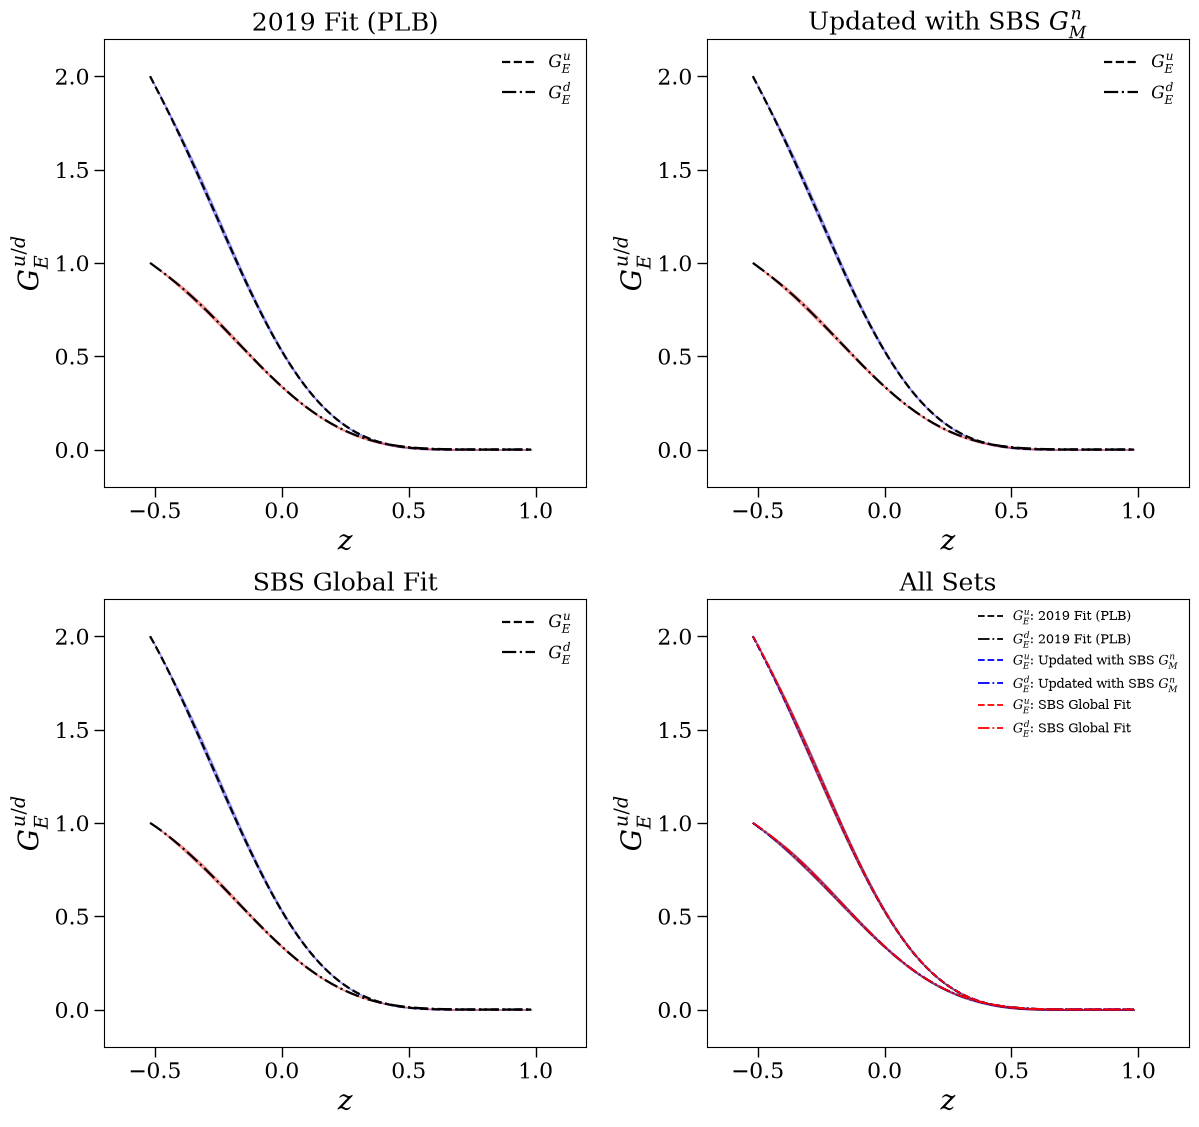

In [30]:
## GEu (vs z; 4 panels in one page; overlay in bottom-right)
ymin1 = -0.2
ymax1 = 2.2
Q2plot1 = 10

com1u = r'$G_E^u$: 2019 Fit (PLB)'
com1d = r'$G_E^d$: 2019 Fit (PLB)'
com2u = r'$G_E^u$: Updated with SBS $G_M^n$'
com2d = r'$G_E^d$: Updated with SBS $G_M^n$'
com3u = r'$G_E^u$: SBS Global Fit'
com3d = r'$G_E^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Z, GEu, 'k--', linewidth=1.6, label=r'$G_E^u$')
ax[0,0].fill_between(Z, GEu-dGEu, GEu+dGEu, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Z, GEd, 'k-.', linewidth=1.6, label=r'$G_E^d$')
ax[0,0].fill_between(Z, GEd-dGEd, GEd+dGEd, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Z, GEu_set2, 'k--', linewidth=1.6, label=r'$G_E^u$')
ax[0,1].fill_between(Z, GEu_set2-dGEu_set2, GEu_set2+dGEu_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Z, GEd_set2, 'k-.', linewidth=1.6, label=r'$G_E^d$')
ax[0,1].fill_between(Z, GEd_set2-dGEd_set2, GEd_set2+dGEd_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Z, GEu_set3, 'k--', linewidth=1.6, label=r'$G_E^u$')
ax[1,0].fill_between(Z, GEu_set3-dGEu_set3, GEu_set3+dGEu_set3, edgecolor='b', facecolor='b', alpha=0.3)

ax[1,0].plot(Z, GEd_set3, 'k-.', linewidth=1.6, label=r'$G_E^d$')
ax[1,0].fill_between(Z, GEd_set3-dGEd_set3, GEd_set3+dGEd_set3, edgecolor='r', facecolor='r', alpha=0.3)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Z, GEu, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Z, GEu-dGEu, GEu+dGEu, edgecolor='black', facecolor='black', alpha=0.3)

ax[1,1].plot(Z, GEd, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Z, GEd-dGEd, GEd+dGEd, edgecolor='black', facecolor='black', alpha=0.3)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Z, GEu_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Z, GEu_set2-dGEu_set2, GEu_set2+dGEu_set2, edgecolor='b', facecolor='b', alpha=0.2)

ax[1,1].plot(Z, GEd_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Z, GEd_set2-dGEd_set2, GEd_set2+dGEd_set2, edgecolor='b', facecolor='b', alpha=0.2)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Z, GEu_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Z, GEu_set3-dGEu_set3, GEu_set3+dGEu_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Z, GEd_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Z, GEd_set3-dGEd_set3, GEd_set3+dGEd_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(-0.7, 1.2)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel('$G_E^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$z$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GE_Z_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GE_Z_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GE_Z_4panel.eps', bbox_inches='tight')

## Plotting u-quark and d-quark $G_M$

### vs Q2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


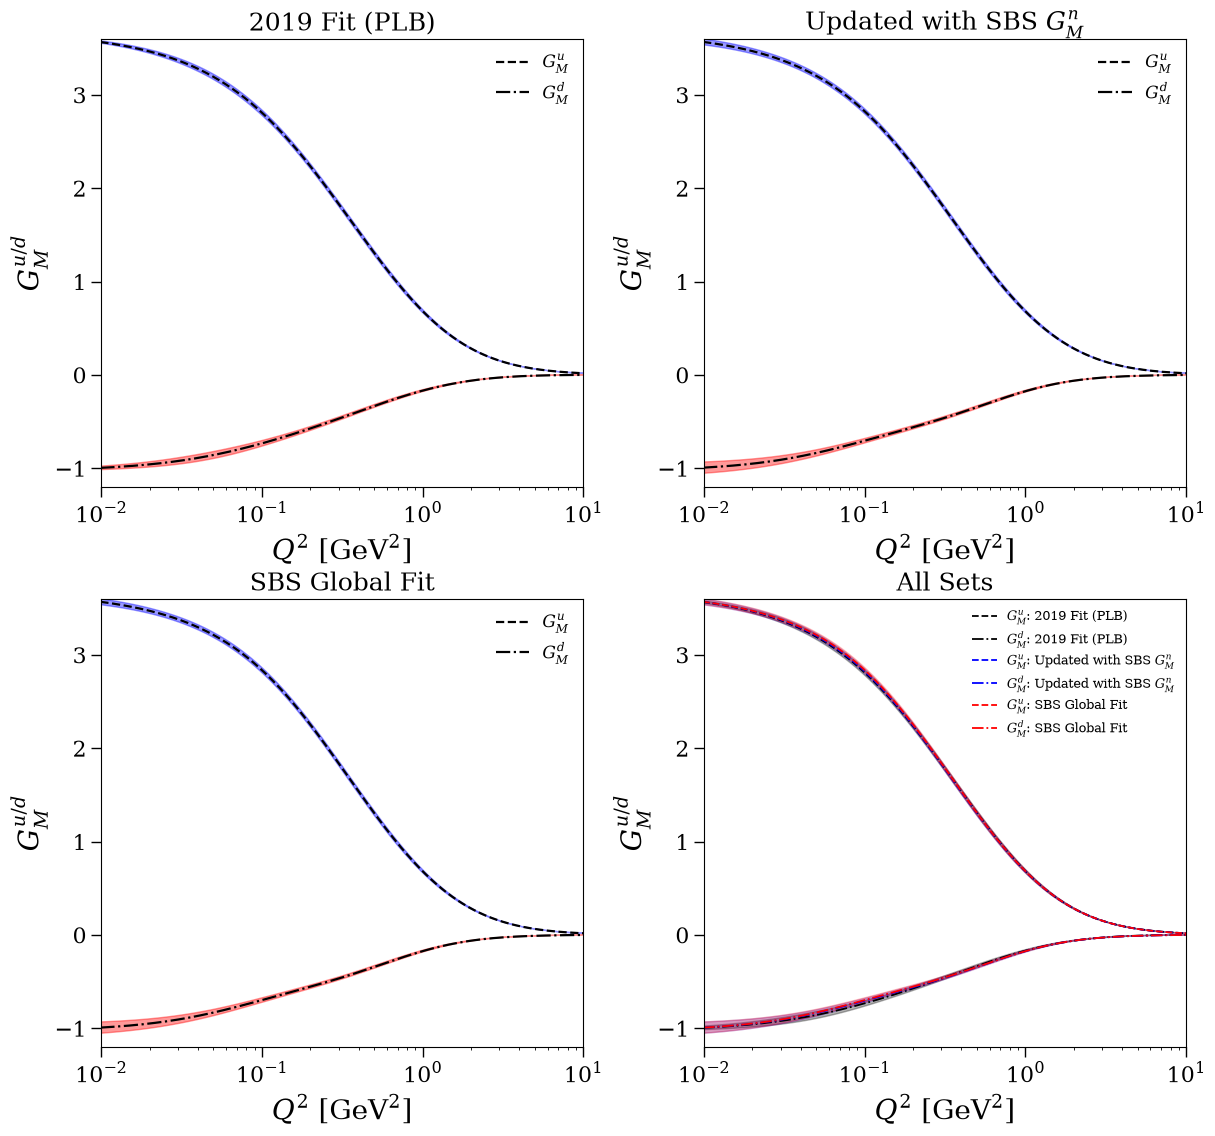

In [31]:
## GMu (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = -1.2
ymax1 = 3.6
Q2plot1 = 10

com1u = r'$G_M^u$: 2019 Fit (PLB)'
com1d = r'$G_M^d$: 2019 Fit (PLB)'
com2u = r'$G_M^u$: Updated with SBS $G_M^n$'
com2d = r'$G_M^d$: Updated with SBS $G_M^n$'
com3u = r'$G_M^u$: SBS Global Fit'
com3d = r'$G_M^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, GMu, 'k--', linewidth=1.6, label=r'$G_M^u$')
ax[0,0].fill_between(Q2, GMu-dGMu, GMu+dGMu, edgecolor='b', facecolor='b', alpha=0.40)

ax[0,0].plot(Q2, GMd, 'k-.', linewidth=1.6, label=r'$G_M^d$')
ax[0,0].fill_between(Q2, GMd-dGMd, GMd+dGMd, edgecolor='r', facecolor='r', alpha=0.40)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, GMu_set2, 'k--', linewidth=1.6, label=r'$G_M^u$')
ax[0,1].fill_between(Q2, GMu_set2-dGMu_set2, GMu_set2+dGMu_set2, edgecolor='b', facecolor='b', alpha=0.40)

ax[0,1].plot(Q2, GMd_set2, 'k-.', linewidth=1.6, label=r'$G_M^d$')
ax[0,1].fill_between(Q2, GMd_set2-dGMd_set2, GMd_set2+dGMd_set2, edgecolor='r', facecolor='r', alpha=0.40)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, GMu_set3, 'k--', linewidth=1.6, label=r'$G_M^u$')
ax[1,0].fill_between(Q2, GMu_set3-dGMu_set3, GMu_set3+dGMu_set3, edgecolor='b', facecolor='b', alpha=0.40)

ax[1,0].plot(Q2, GMd_set3, 'k-.', linewidth=1.6, label=r'$G_M^d$')
ax[1,0].fill_between(Q2, GMd_set3-dGMd_set3, GMd_set3+dGMd_set3, edgecolor='r', facecolor='r', alpha=0.40)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, GMu, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, GMu-dGMu, GMu+dGMu, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, GMd, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, GMd-dGMd, GMd+dGMd, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, GMu_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, GMu_set2-dGMu_set2, GMu_set2+dGMu_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, GMd_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, GMd_set2-dGMd_set2, GMd_set2+dGMd_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, GMu_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, GMu_set3-dGMu_set3, GMu_set3+dGMu_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, GMd_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, GMd_set3-dGMd_set3, GMd_set3+dGMd_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel('$G_M^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GM_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GM_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GM_4panel.eps', bbox_inches='tight')

## Plotting u-quark and d-quark $G_E/G_D$

### vs Q2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


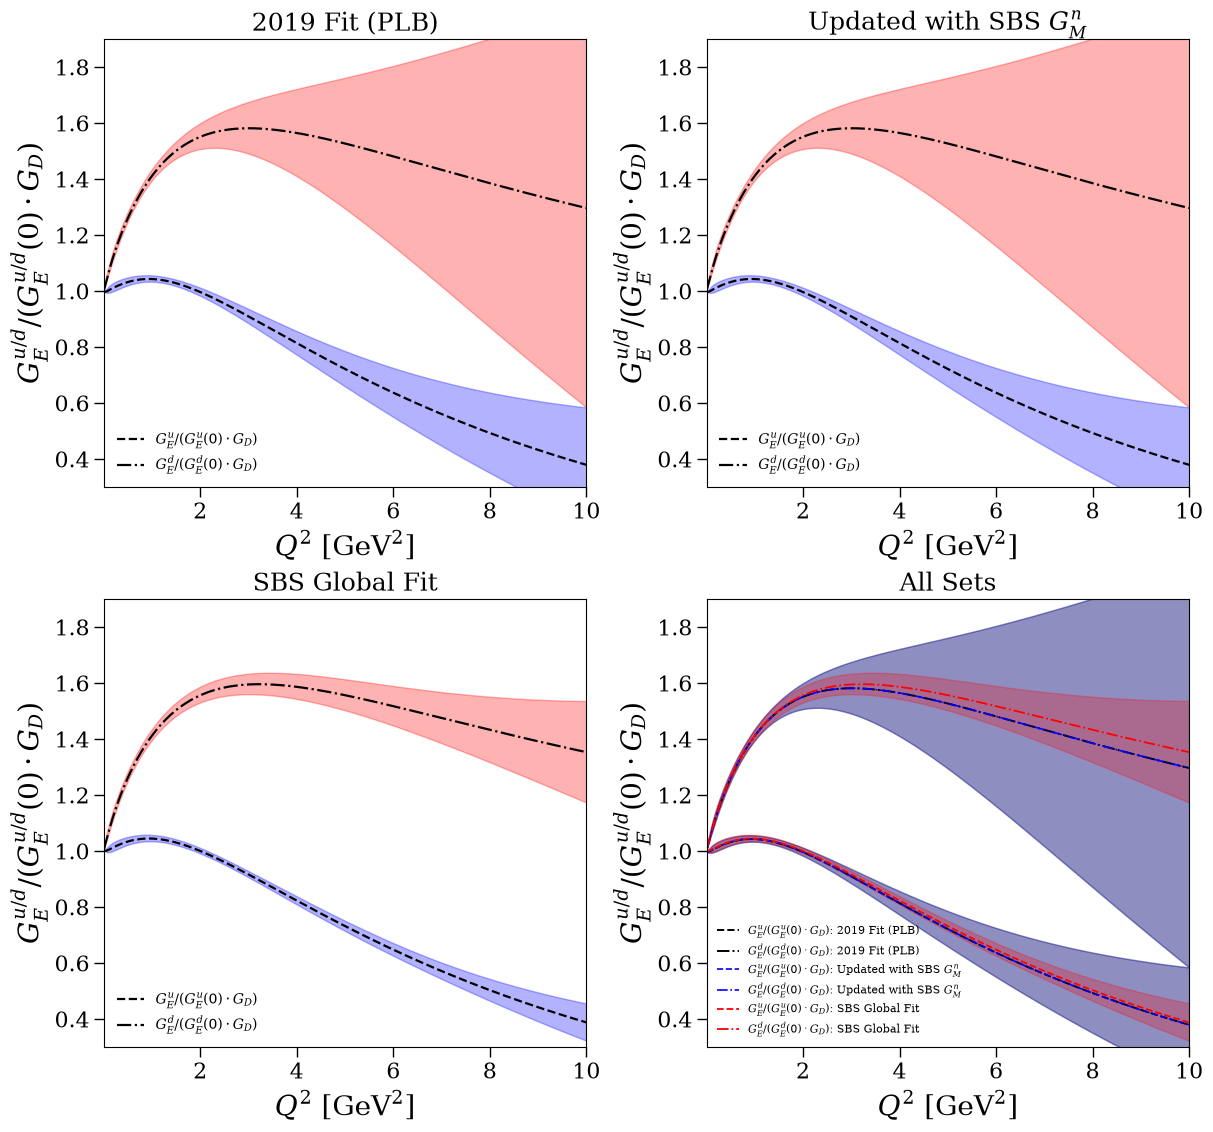

In [32]:
## GEu/GD (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = 0.3
ymax1 = 1.9
Q2plot1 = 10

com1u = r'$G_E^u/(G_E^{u}(0)\cdot G_D)$: 2019 Fit (PLB)'
com1d = r'$G_E^d/(G_E^{d}(0)\cdot G_D)$: 2019 Fit (PLB)'
com2u = r'$G_E^u/(G_E^{u}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com2d = r'$G_E^d/(G_E^{d}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com3u = r'$G_E^u/(G_E^{u}(0)\cdot G_D)$: SBS Global Fit'
com3d = r'$G_E^d/(G_E^{d}(0)\cdot G_D)$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, GEu_rat, 'k--', linewidth=1.6, label=r'$G_E^u/(G_E^{u}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GEu_rat-dGEu_rat, GEu_rat+dGEu_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, GEd_rat, 'k-.', linewidth=1.6, label=r'$G_E^d/(G_E^{d}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GEd_rat-dGEd_rat, GEd_rat+dGEd_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='lower left', fontsize=10, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, GEu_rat_set2, 'k--', linewidth=1.6, label=r'$G_E^u/(G_E^{u}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GEu_rat_set2-dGEu_rat_set2, GEu_rat_set2+dGEu_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, GEd_rat_set2, 'k-.', linewidth=1.6, label=r'$G_E^d/(G_E^{d}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GEd_rat_set2-dGEd_rat_set2, GEd_rat_set2+dGEd_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='lower left', fontsize=10, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, GEu_rat_set3, 'k--', linewidth=1.6, label=r'$G_E^u/(G_E^{u}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GEu_rat_set3-dGEu_rat_set3, GEu_rat_set3+dGEu_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, GEd_rat_set3, 'k-.', linewidth=1.6, label=r'$G_E^d/(G_E^{d}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GEd_rat_set3-dGEd_rat_set3, GEd_rat_set3+dGEd_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='lower left', fontsize=10, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, GEu_rat, 'k--', linewidth=1.4, label=com1u)
ax[1,1].fill_between(Q2, GEu_rat-dGEu_rat, GEu_rat+dGEu_rat, edgecolor='black', facecolor='black', alpha=0.3)

ax[1,1].plot(Q2, GEd_rat, 'k-.', linewidth=1.4, label=com1d)
ax[1,1].fill_between(Q2, GEd_rat-dGEd_rat, GEd_rat+dGEd_rat, edgecolor='black', facecolor='black', alpha=0.3)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, GEu_rat_set2, 'b--', linewidth=1.2, label=com2u)
ax[1,1].fill_between(Q2, GEu_rat_set2-dGEu_rat_set2, GEu_rat_set2+dGEu_rat_set2, edgecolor='b', facecolor='b', alpha=0.2)

ax[1,1].plot(Q2, GEd_rat_set2, 'b-.', linewidth=1.2, label=com2d)
ax[1,1].fill_between(Q2, GEd_rat_set2-dGEd_rat_set2, GEd_rat_set2+dGEd_rat_set2, edgecolor='b', facecolor='b', alpha=0.2)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, GEu_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, GEu_rat_set3-dGEu_rat_set3, GEu_rat_set3+dGEu_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, GEd_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, GEd_rat_set3-dGEd_rat_set3, GEd_rat_set3+dGEd_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='lower left', fontsize=8, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, 10)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel('$G_E^{u/d}/(G_E^{u/d}(0)\cdot G_D)$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GErat_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GErat_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GErat_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


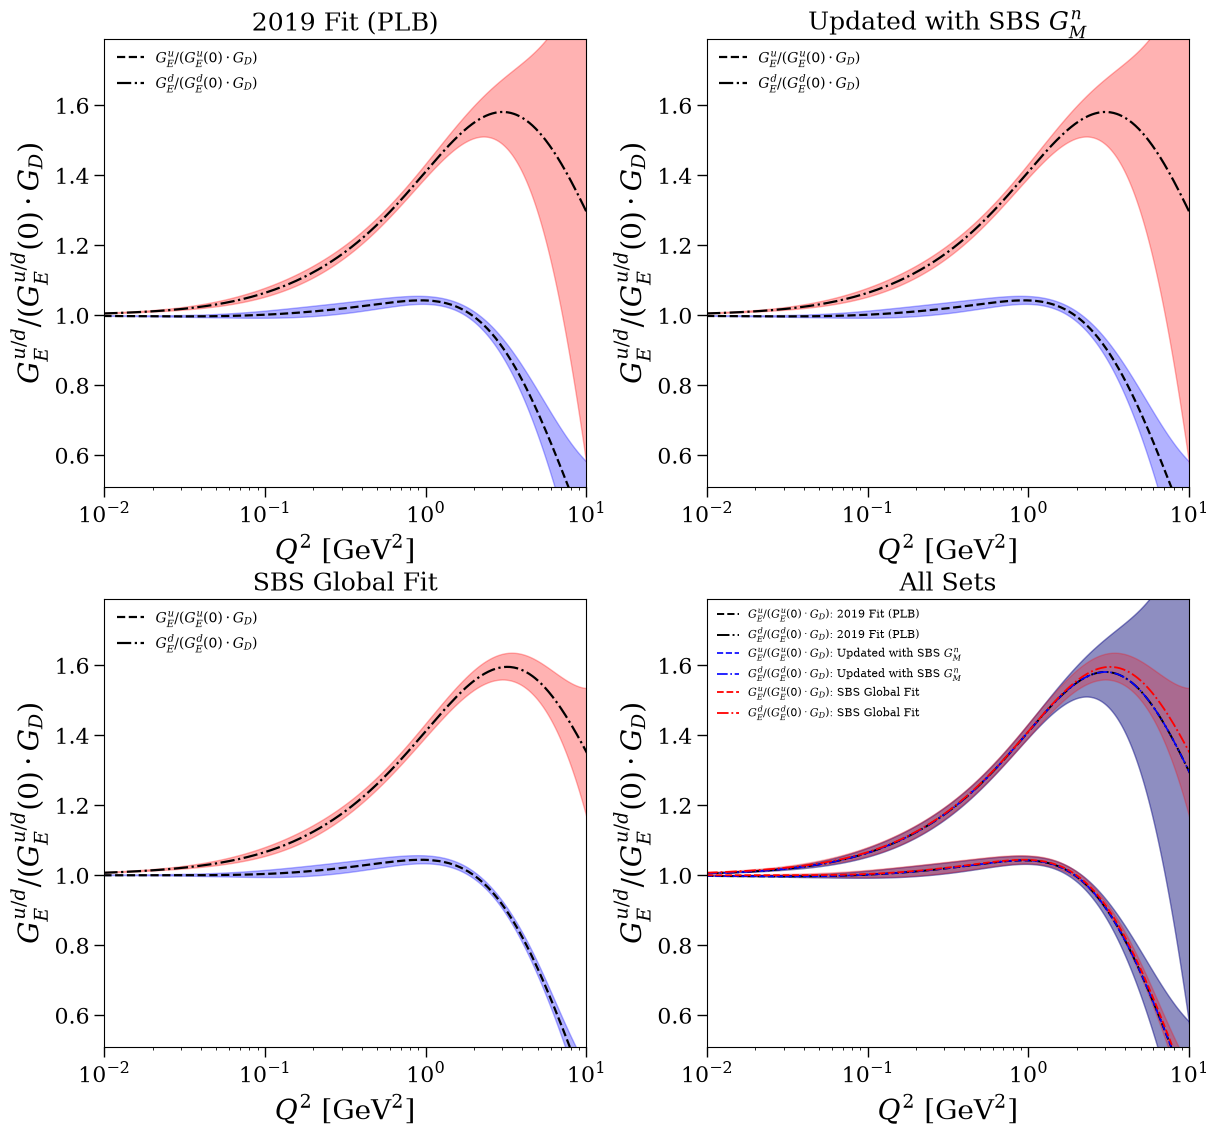

In [33]:
## GEu/GD (log Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = 0.51
ymax1 = 1.79
Q2plot1 = 10

com1u = r'$G_E^u/(G_E^{u}(0)\cdot G_D)$: 2019 Fit (PLB)'
com1d = r'$G_E^d/(G_E^{d}(0)\cdot G_D)$: 2019 Fit (PLB)'
com2u = r'$G_E^u/(G_E^{u}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com2d = r'$G_E^d/(G_E^{d}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com3u = r'$G_E^u/(G_E^{u}(0)\cdot G_D)$: SBS Global Fit'
com3d = r'$G_E^d/(G_E^{d}(0)\cdot G_D)$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, GEu_rat, 'k--', linewidth=1.6, label=r'$G_E^u/(G_E^{u}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GEu_rat-dGEu_rat, GEu_rat+dGEu_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, GEd_rat, 'k-.', linewidth=1.6, label=r'$G_E^d/(G_E^{d}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GEd_rat-dGEd_rat, GEd_rat+dGEd_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='upper left', fontsize=10, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, GEu_rat_set2, 'k--', linewidth=1.6, label=r'$G_E^u/(G_E^{u}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GEu_rat_set2-dGEu_rat_set2, GEu_rat_set2+dGEu_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, GEd_rat_set2, 'k-.', linewidth=1.6, label=r'$G_E^d/(G_E^{d}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GEd_rat_set2-dGEd_rat_set2, GEd_rat_set2+dGEd_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='upper left', fontsize=10, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, GEu_rat_set3, 'k--', linewidth=1.6, label=r'$G_E^u/(G_E^{u}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GEu_rat_set3-dGEu_rat_set3, GEu_rat_set3+dGEu_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, GEd_rat_set3, 'k-.', linewidth=1.6, label=r'$G_E^d/(G_E^{d}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GEd_rat_set3-dGEd_rat_set3, GEd_rat_set3+dGEd_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='upper left', fontsize=10, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, GEu_rat, 'k--', linewidth=1.4, label=com1u)
ax[1,1].fill_between(Q2, GEu_rat-dGEu_rat, GEu_rat+dGEu_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, GEd_rat, 'k-.', linewidth=1.4, label=com1d)
ax[1,1].fill_between(Q2, GEd_rat-dGEd_rat, GEd_rat+dGEd_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, GEu_rat_set2, 'b--', linewidth=1.2, label=com2u)
ax[1,1].fill_between(Q2, GEu_rat_set2-dGEu_rat_set2, GEu_rat_set2+dGEu_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, GEd_rat_set2, 'b-.', linewidth=1.2, label=com2d)
ax[1,1].fill_between(Q2, GEd_rat_set2-dGEd_rat_set2, GEd_rat_set2+dGEd_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, GEu_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, GEu_rat_set3-dGEu_rat_set3, GEu_rat_set3+dGEu_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, GEd_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, GEd_rat_set3-dGEd_rat_set3, GEd_rat_set3+dGEd_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='upper left', fontsize=8, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel('$G_E^{u/d}/(G_E^{u/d}(0)\cdot G_D)$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GErat_log_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GErat_log_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GErat_log_4panel.eps', bbox_inches='tight')

## Plotting u-quark and d-quark $G_M/G_D$

### vs Q2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


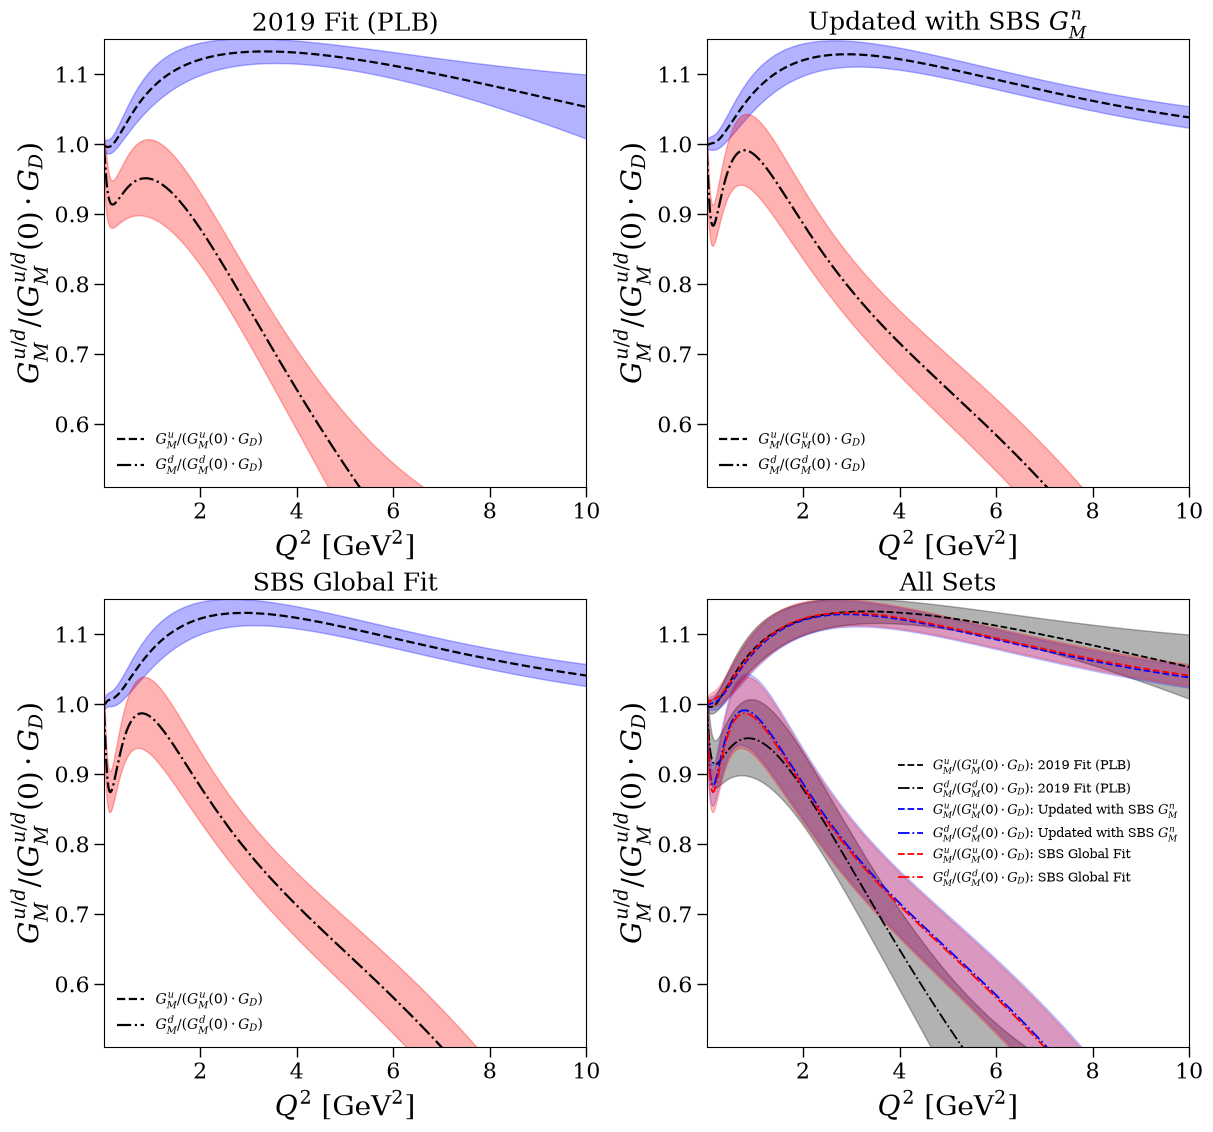

In [34]:
## GMu/GD (4 panels in one page; overlay in bottom-right)
ymin1 = 0.51
ymax1 = 1.15
Q2plot1 = 10

com1u = r'$G_M^u/(G_M^{u}(0)\cdot G_D)$: 2019 Fit (PLB)'
com1d = r'$G_M^d/(G_M^{d}(0)\cdot G_D)$: 2019 Fit (PLB)'
com2u = r'$G_M^u/(G_M^{u}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com2d = r'$G_M^d/(G_M^{d}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com3u = r'$G_M^u/(G_M^{u}(0)\cdot G_D)$: SBS Global Fit'
com3d = r'$G_M^d/(G_M^{d}(0)\cdot G_D)$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, GMu_rat, 'k--', linewidth=1.6, label=r'$G_M^u/(G_M^{u}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GMu_rat-dGMu_rat, GMu_rat+dGMu_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, GMd_rat, 'k-.', linewidth=1.6, label=r'$G_M^d/(G_M^{d}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GMd_rat-dGMd_rat, GMd_rat+dGMd_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=10, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, GMu_rat_set2, 'k--', linewidth=1.6, label=r'$G_M^u/(G_M^{u}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GMu_rat_set2-dGMu_rat_set2, GMu_rat_set2+dGMu_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, GMd_rat_set2, 'k-.', linewidth=1.6, label=r'$G_M^d/(G_M^{d}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GMd_rat_set2-dGMd_rat_set2, GMd_rat_set2+dGMd_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=10, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, GMu_rat_set3, 'k--', linewidth=1.6, label=r'$G_M^u/(G_M^{u}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GMu_rat_set3-dGMu_rat_set3, GMu_rat_set3+dGMu_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, GMd_rat_set3, 'k-.', linewidth=1.6, label=r'$G_M^d/(G_M^{d}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GMd_rat_set3-dGMd_rat_set3, GMd_rat_set3+dGMd_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=10, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, GMu_rat, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, GMu_rat-dGMu_rat, GMu_rat+dGMu_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, GMd_rat, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, GMd_rat-dGMd_rat, GMd_rat+dGMd_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, GMu_rat_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, GMu_rat_set2-dGMu_rat_set2, GMu_rat_set2+dGMu_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, GMd_rat_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, GMd_rat_set2-dGMd_rat_set2, GMd_rat_set2+dGMd_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, GMu_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, GMu_rat_set3-dGMu_rat_set3, GMu_rat_set3+dGMu_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, GMd_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, GMd_rat_set3-dGMd_rat_set3, GMd_rat_set3+dGMd_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel('$G_M^{u/d}/(G_M^{u/d}(0)\cdot G_D)$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GMrat_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GMrat_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GMrat_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


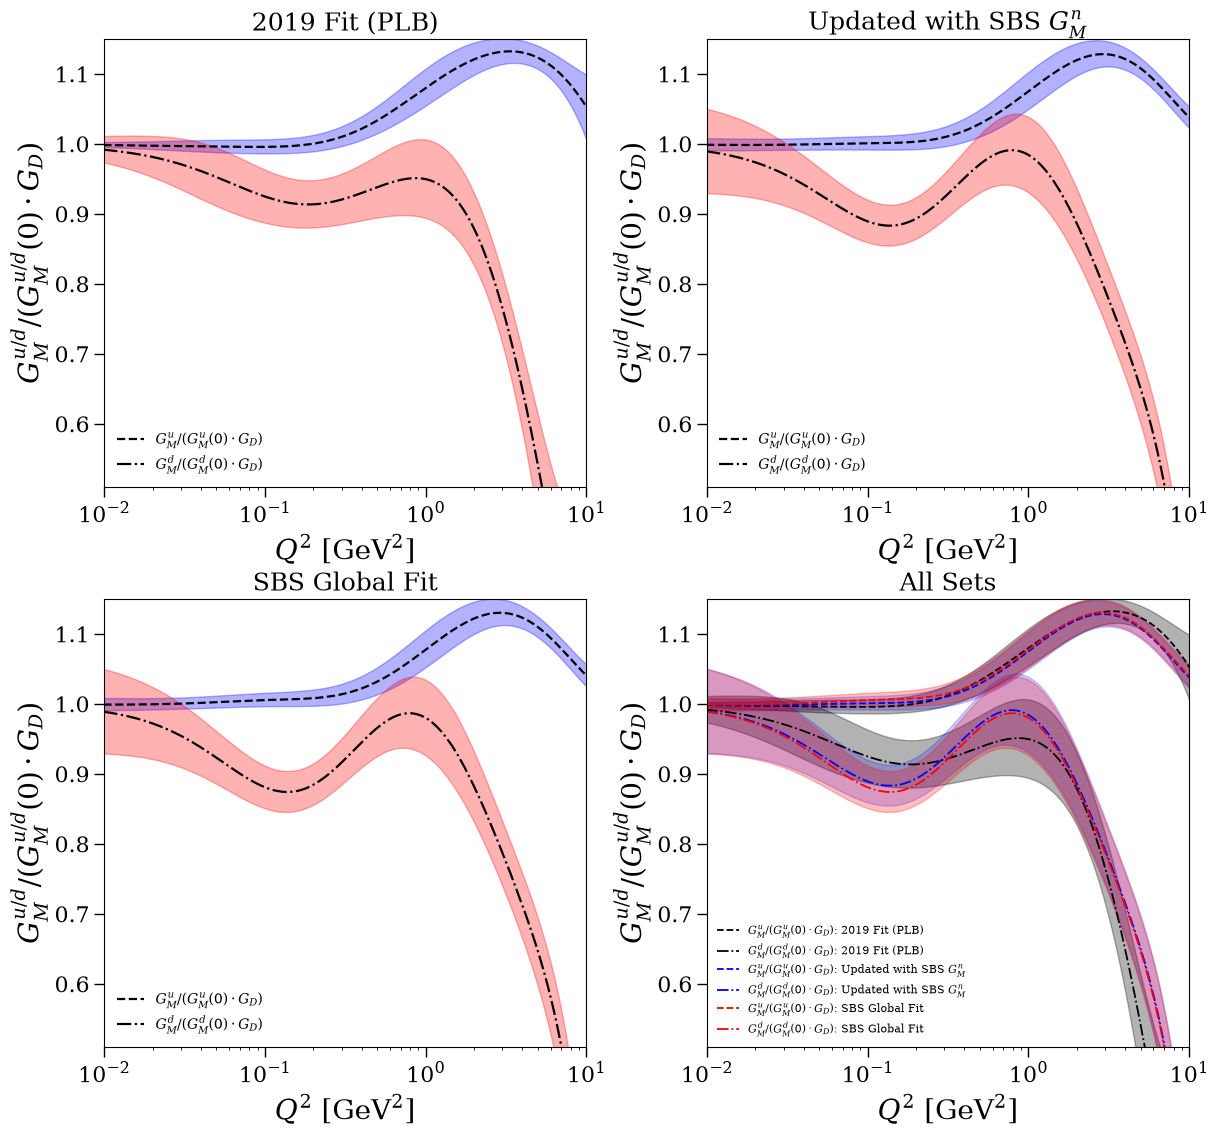

In [35]:
## GMu/GD (log Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = 0.51
ymax1 = 1.15
Q2plot1 = 10

com1u = r'$G_M^u/(G_M^{u}(0)\cdot G_D)$: 2019 Fit (PLB)'
com1d = r'$G_M^d/(G_M^{d}(0)\cdot G_D)$: 2019 Fit (PLB)'
com2u = r'$G_M^u/(G_M^{u}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com2d = r'$G_M^d/(G_M^{d}(0)\cdot G_D)$: Updated with SBS $G_M^n$'
com3u = r'$G_M^u/(G_M^{u}(0)\cdot G_D)$: SBS Global Fit'
com3d = r'$G_M^d/(G_M^{d}(0)\cdot G_D)$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, GMu_rat, 'k--', linewidth=1.6, label=r'$G_M^u/(G_M^{u}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GMu_rat-dGMu_rat, GMu_rat+dGMu_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, GMd_rat, 'k-.', linewidth=1.6, label=r'$G_M^d/(G_M^{d}(0)\cdot G_D)$')
ax[0,0].fill_between(Q2, GMd_rat-dGMd_rat, GMd_rat+dGMd_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='lower left', fontsize=10, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, GMu_rat_set2, 'k--', linewidth=1.6, label=r'$G_M^u/(G_M^{u}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GMu_rat_set2-dGMu_rat_set2, GMu_rat_set2+dGMu_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, GMd_rat_set2, 'k-.', linewidth=1.6, label=r'$G_M^d/(G_M^{d}(0)\cdot G_D)$')
ax[0,1].fill_between(Q2, GMd_rat_set2-dGMd_rat_set2, GMd_rat_set2+dGMd_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='lower left', fontsize=10, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, GMu_rat_set3, 'k--', linewidth=1.6, label=r'$G_M^u/(G_M^{u}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GMu_rat_set3-dGMu_rat_set3, GMu_rat_set3+dGMu_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, GMd_rat_set3, 'k-.', linewidth=1.6, label=r'$G_M^d/(G_M^{d}(0)\cdot G_D)$')
ax[1,0].fill_between(Q2, GMd_rat_set3-dGMd_rat_set3, GMd_rat_set3+dGMd_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='lower left', fontsize=10, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, GMu_rat, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, GMu_rat-dGMu_rat, GMu_rat+dGMu_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, GMd_rat, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, GMd_rat-dGMd_rat, GMd_rat+dGMd_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, GMu_rat_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, GMu_rat_set2-dGMu_rat_set2, GMu_rat_set2+dGMu_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, GMd_rat_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, GMd_rat_set2-dGMd_rat_set2, GMd_rat_set2+dGMd_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, GMu_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, GMu_rat_set3-dGMu_rat_set3, GMu_rat_set3+dGMu_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, GMd_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, GMd_rat_set3-dGMd_rat_set3, GMd_rat_set3+dGMd_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='lower left', fontsize=8, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel('$G_M^{u/d}/(G_M^{u/d}(0)\cdot G_D)$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_GMrat_log_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_GMrat_log_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_GMrat_log_4panel.eps', bbox_inches='tight')

## Plotting F1 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


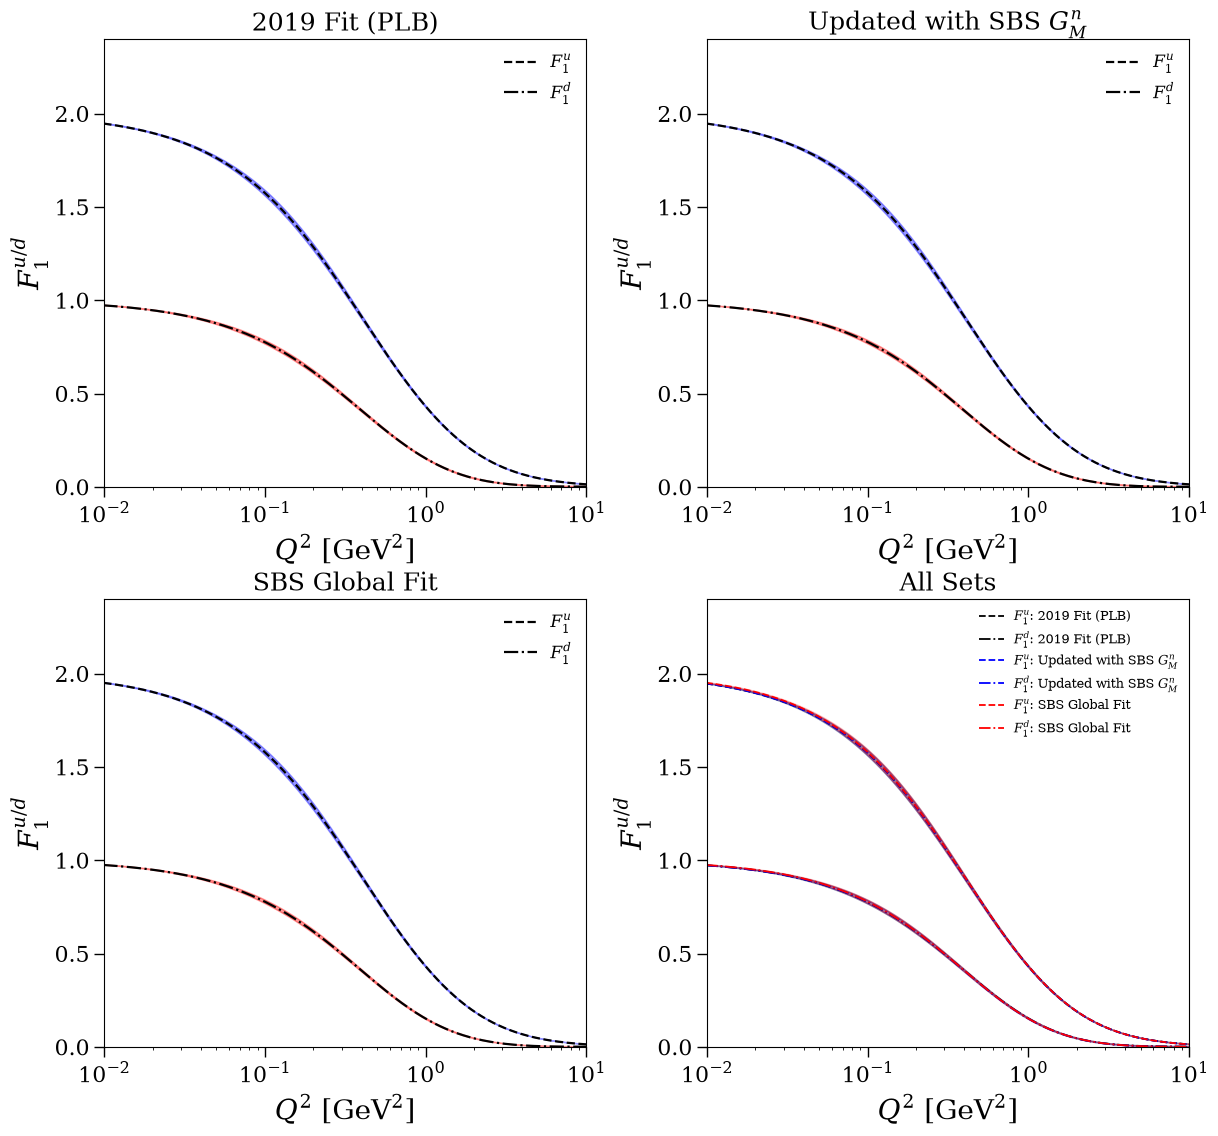

In [36]:
## F1u/F1d (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = 0.
ymax1 = 2.4
Q2plot1 = 10

com1u = r'$F_1^u$: 2019 Fit (PLB)'
com1d = r'$F_1^d$: 2019 Fit (PLB)'
com2u = r'$F_1^u$: Updated with SBS $G_M^n$'
com2d = r'$F_1^d$: Updated with SBS $G_M^n$'
com3u = r'$F_1^u$: SBS Global Fit'
com3d = r'$F_1^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1u, 'k--', linewidth=1.6, label=r'$F_1^u$')
ax[0,0].fill_between(Q2, F1u-dF1u, F1u+dF1u, edgecolor='b', facecolor='b', alpha=0.40)

ax[0,0].plot(Q2, F1d, 'k-.', linewidth=1.6, label=r'$F_1^d$')
ax[0,0].fill_between(Q2, F1d-dF1d, F1d+dF1d, edgecolor='r', facecolor='r', alpha=0.40)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1u_set2, 'k--', linewidth=1.6, label=r'$F_1^u$')
ax[0,1].fill_between(Q2, F1u_set2-dF1u_set2, F1u_set2+dF1u_set2, edgecolor='b', facecolor='b', alpha=0.40)

ax[0,1].plot(Q2, F1d_set2, 'k-.', linewidth=1.6, label=r'$F_1^d$')
ax[0,1].fill_between(Q2, F1d_set2-dF1d_set2, F1d_set2+dF1d_set2, edgecolor='r', facecolor='r', alpha=0.40)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1u_set3, 'k--', linewidth=1.6, label=r'$F_1^u$')
ax[1,0].fill_between(Q2, F1u_set3-dF1u_set3, F1u_set3+dF1u_set3, edgecolor='b', facecolor='b', alpha=0.40)

ax[1,0].plot(Q2, F1d_set3, 'k-.', linewidth=1.6, label=r'$F_1^d$')
ax[1,0].fill_between(Q2, F1d_set3-dF1d_set3, F1d_set3+dF1d_set3, edgecolor='r', facecolor='r', alpha=0.40)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1u, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F1u-dF1u, F1u+dF1u, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F1d, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F1d-dF1d, F1d+dF1d, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1u_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F1u_set2-dF1u_set2, F1u_set2+dF1u_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F1d_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F1d_set2-dF1d_set2, F1d_set2+dF1d_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1u_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F1u_set3-dF1u_set3, F1u_set3+dF1u_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F1d_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F1d_set3-dF1d_set3, F1d_set3+dF1d_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel('$F_1^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


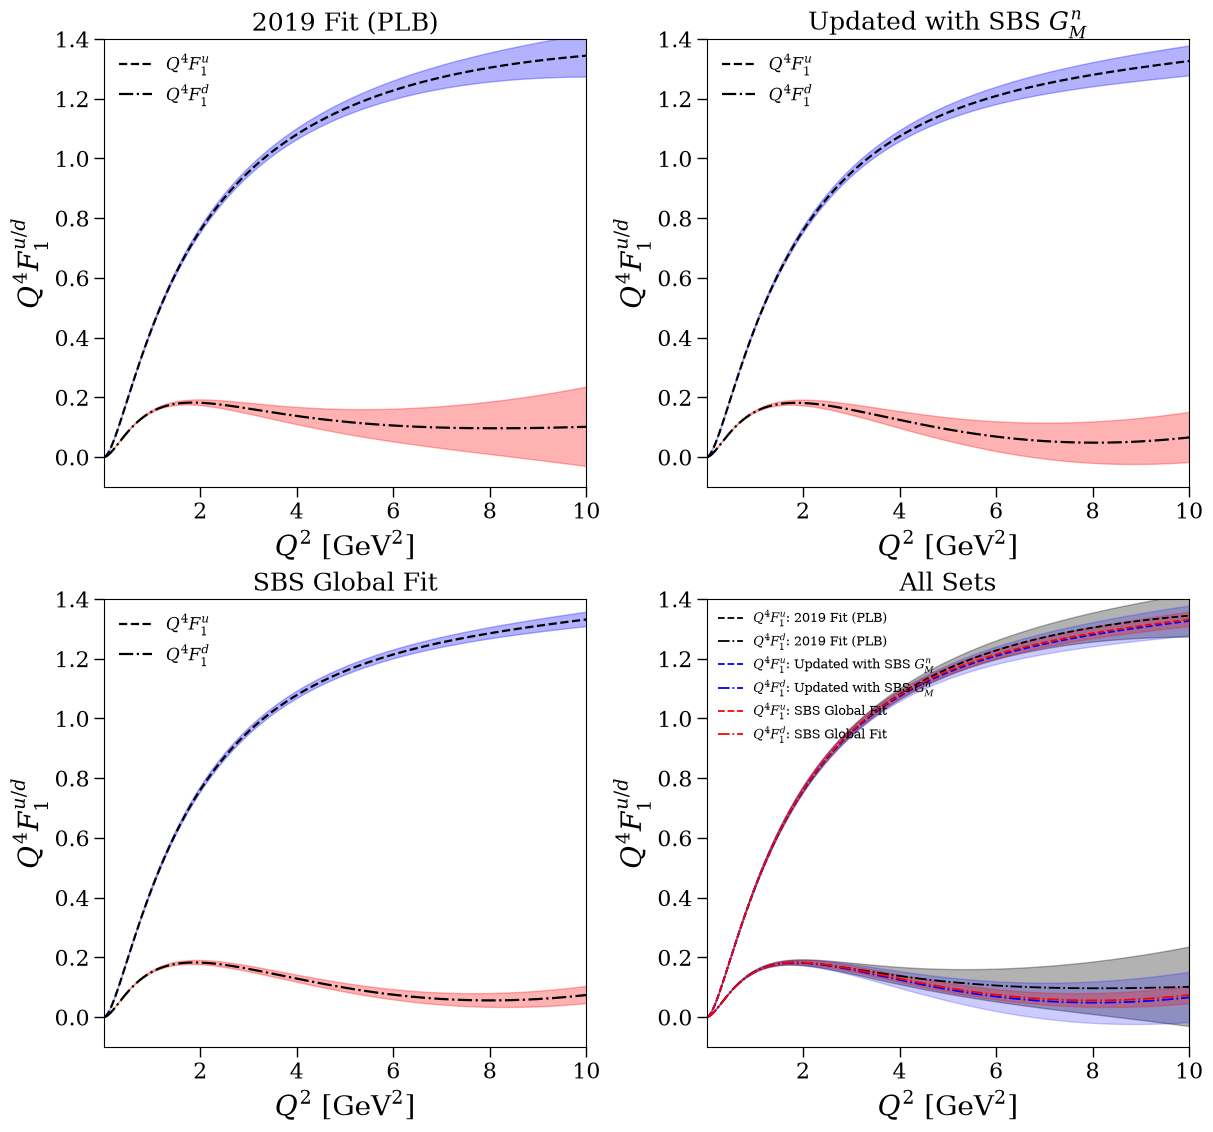

In [37]:
## Q^4 F1u/F1d (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = -0.1
ymax1 = 1.4
Q2plot1 = 10

com1u = r'$Q^4 F_1^u$: 2019 Fit (PLB)'
com1d = r'$Q^4 F_1^d$: 2019 Fit (PLB)'
com2u = r'$Q^4 F_1^u$: Updated with SBS $G_M^n$'
com2d = r'$Q^4 F_1^d$: Updated with SBS $G_M^n$'
com3u = r'$Q^4 F_1^u$: SBS Global Fit'
com3d = r'$Q^4 F_1^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1u_rat, 'k--', linewidth=1.6, label=r'$Q^4 F_1^u$')
ax[0,0].fill_between(Q2, F1u_rat-dF1u_rat, F1u_rat+dF1u_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F1d_rat, 'k-.', linewidth=1.6, label=r'$Q^4 F_1^d$')
ax[0,0].fill_between(Q2, F1d_rat-dF1d_rat, F1d_rat+dF1d_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1u_rat_set2, 'k--', linewidth=1.6, label=r'$Q^4 F_1^u$')
ax[0,1].fill_between(Q2, F1u_rat_set2-dF1u_rat_set2, F1u_rat_set2+dF1u_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F1d_rat_set2, 'k-.', linewidth=1.6, label=r'$Q^4 F_1^d$')
ax[0,1].fill_between(Q2, F1d_rat_set2-dF1d_rat_set2, F1d_rat_set2+dF1d_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1u_rat_set3, 'k--', linewidth=1.6, label=r'$Q^4 F_1^u$')
ax[1,0].fill_between(Q2, F1u_rat_set3-dF1u_rat_set3, F1u_rat_set3+dF1u_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F1d_rat_set3, 'k-.', linewidth=1.6, label=r'$Q^4 F_1^d$')
ax[1,0].fill_between(Q2, F1d_rat_set3-dF1d_rat_set3, F1d_rat_set3+dF1d_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1u_rat, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F1u_rat-dF1u_rat, F1u_rat+dF1u_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F1d_rat, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F1d_rat-dF1d_rat, F1d_rat+dF1d_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1u_rat_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F1u_rat_set2-dF1u_rat_set2, F1u_rat_set2+dF1u_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F1d_rat_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F1d_rat_set2-dF1d_rat_set2, F1d_rat_set2+dF1d_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1u_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F1u_rat_set3-dF1u_rat_set3, F1u_rat_set3+dF1u_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F1d_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F1d_rat_set3-dF1d_rat_set3, F1d_rat_set3+dF1d_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='upper left', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel('$Q^4 F_1^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1rat_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1rat_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1rat_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


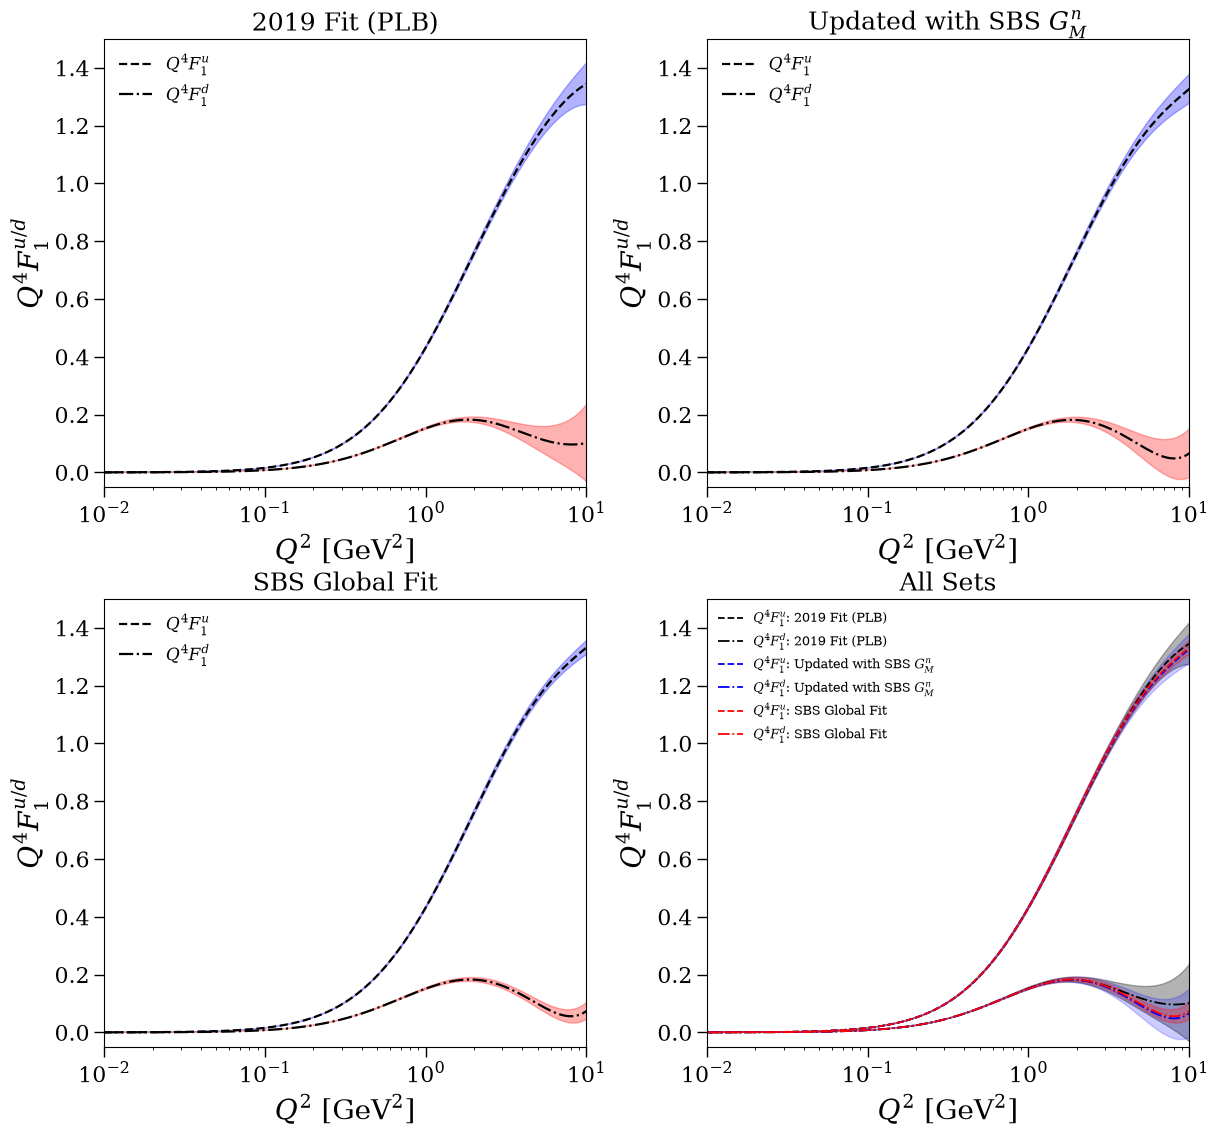

In [38]:
## Q^4 F1u/F1d (log Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = -0.05
ymax1 = 1.5
Q2plot1 = 10

com1u = r'$Q^4 F_1^u$: 2019 Fit (PLB)'
com1d = r'$Q^4 F_1^d$: 2019 Fit (PLB)'
com2u = r'$Q^4 F_1^u$: Updated with SBS $G_M^n$'
com2d = r'$Q^4 F_1^d$: Updated with SBS $G_M^n$'
com3u = r'$Q^4 F_1^u$: SBS Global Fit'
com3d = r'$Q^4 F_1^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1u_rat, 'k--', linewidth=1.6, label=r'$Q^4 F_1^u$')
ax[0,0].fill_between(Q2, F1u_rat-dF1u_rat, F1u_rat+dF1u_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F1d_rat, 'k-.', linewidth=1.6, label=r'$Q^4 F_1^d$')
ax[0,0].fill_between(Q2, F1d_rat-dF1d_rat, F1d_rat+dF1d_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1u_rat_set2, 'k--', linewidth=1.6, label=r'$Q^4 F_1^u$')
ax[0,1].fill_between(Q2, F1u_rat_set2-dF1u_rat_set2, F1u_rat_set2+dF1u_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F1d_rat_set2, 'k-.', linewidth=1.6, label=r'$Q^4 F_1^d$')
ax[0,1].fill_between(Q2, F1d_rat_set2-dF1d_rat_set2, F1d_rat_set2+dF1d_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1u_rat_set3, 'k--', linewidth=1.6, label=r'$Q^4 F_1^u$')
ax[1,0].fill_between(Q2, F1u_rat_set3-dF1u_rat_set3, F1u_rat_set3+dF1u_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F1d_rat_set3, 'k-.', linewidth=1.6, label=r'$Q^4 F_1^d$')
ax[1,0].fill_between(Q2, F1d_rat_set3-dF1d_rat_set3, F1d_rat_set3+dF1d_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1u_rat, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F1u_rat-dF1u_rat, F1u_rat+dF1u_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F1d_rat, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F1d_rat-dF1d_rat, F1d_rat+dF1d_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1u_rat_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F1u_rat_set2-dF1u_rat_set2, F1u_rat_set2+dF1u_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F1d_rat_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F1d_rat_set2-dF1d_rat_set2, F1d_rat_set2+dF1d_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1u_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F1u_rat_set3-dF1u_rat_set3, F1u_rat_set3+dF1u_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F1d_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F1d_rat_set3-dF1d_rat_set3, F1d_rat_set3+dF1d_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='upper left', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel('$Q^4 F_1^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1rat_log_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1rat_log_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1rat_log_4panel.eps', bbox_inches='tight')

## Plotting F2 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


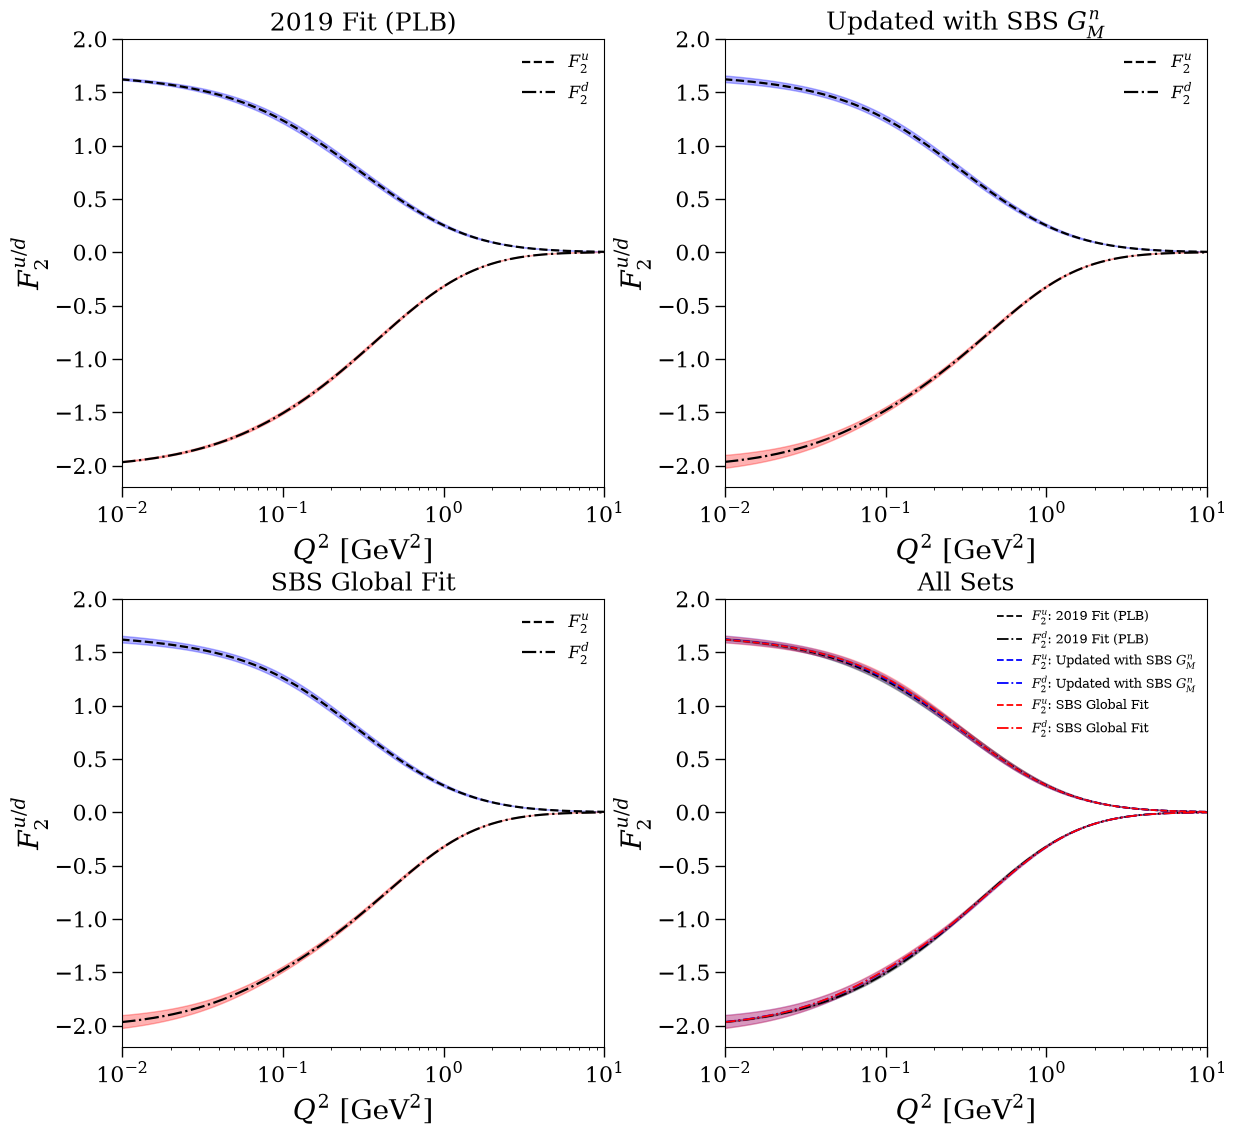

In [39]:
## F2u/F2d (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = -2.2
ymax1 = 2.0
Q2plot1 = 10

com1u = r'$F_2^u$: 2019 Fit (PLB)'
com1d = r'$F_2^d$: 2019 Fit (PLB)'
com2u = r'$F_2^u$: Updated with SBS $G_M^n$'
com2d = r'$F_2^d$: Updated with SBS $G_M^n$'
com3u = r'$F_2^u$: SBS Global Fit'
com3d = r'$F_2^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F2u, 'k--', linewidth=1.6, label=r'$F_2^u$')
ax[0,0].fill_between(Q2, F2u-dF2u, F2u+dF2u, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F2d, 'k-.', linewidth=1.6, label=r'$F_2^d$')
ax[0,0].fill_between(Q2, F2d-dF2d, F2d+dF2d, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F2u_set2, 'k--', linewidth=1.6, label=r'$F_2^u$')
ax[0,1].fill_between(Q2, F2u_set2-dF2u_set2, F2u_set2+dF2u_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F2d_set2, 'k-.', linewidth=1.6, label=r'$F_2^d$')
ax[0,1].fill_between(Q2, F2d_set2-dF2d_set2, F2d_set2+dF2d_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F2u_set3, 'k--', linewidth=1.6, label=r'$F_2^u$')
ax[1,0].fill_between(Q2, F2u_set3-dF2u_set3, F2u_set3+dF2u_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F2d_set3, 'k-.', linewidth=1.6, label=r'$F_2^d$')
ax[1,0].fill_between(Q2, F2d_set3-dF2d_set3, F2d_set3+dF2d_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F2u, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F2u-dF2u, F2u+dF2u, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F2d, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F2d-dF2d, F2d+dF2d, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F2u_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F2u_set2-dF2u_set2, F2u_set2+dF2u_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F2d_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F2d_set2-dF2d_set2, F2d_set2+dF2d_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F2u_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F2u_set3-dF2u_set3, F2u_set3+dF2u_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F2d_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F2d_set3-dF2d_set3, F2d_set3+dF2d_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel('$F_2^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F2_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F2_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F2_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


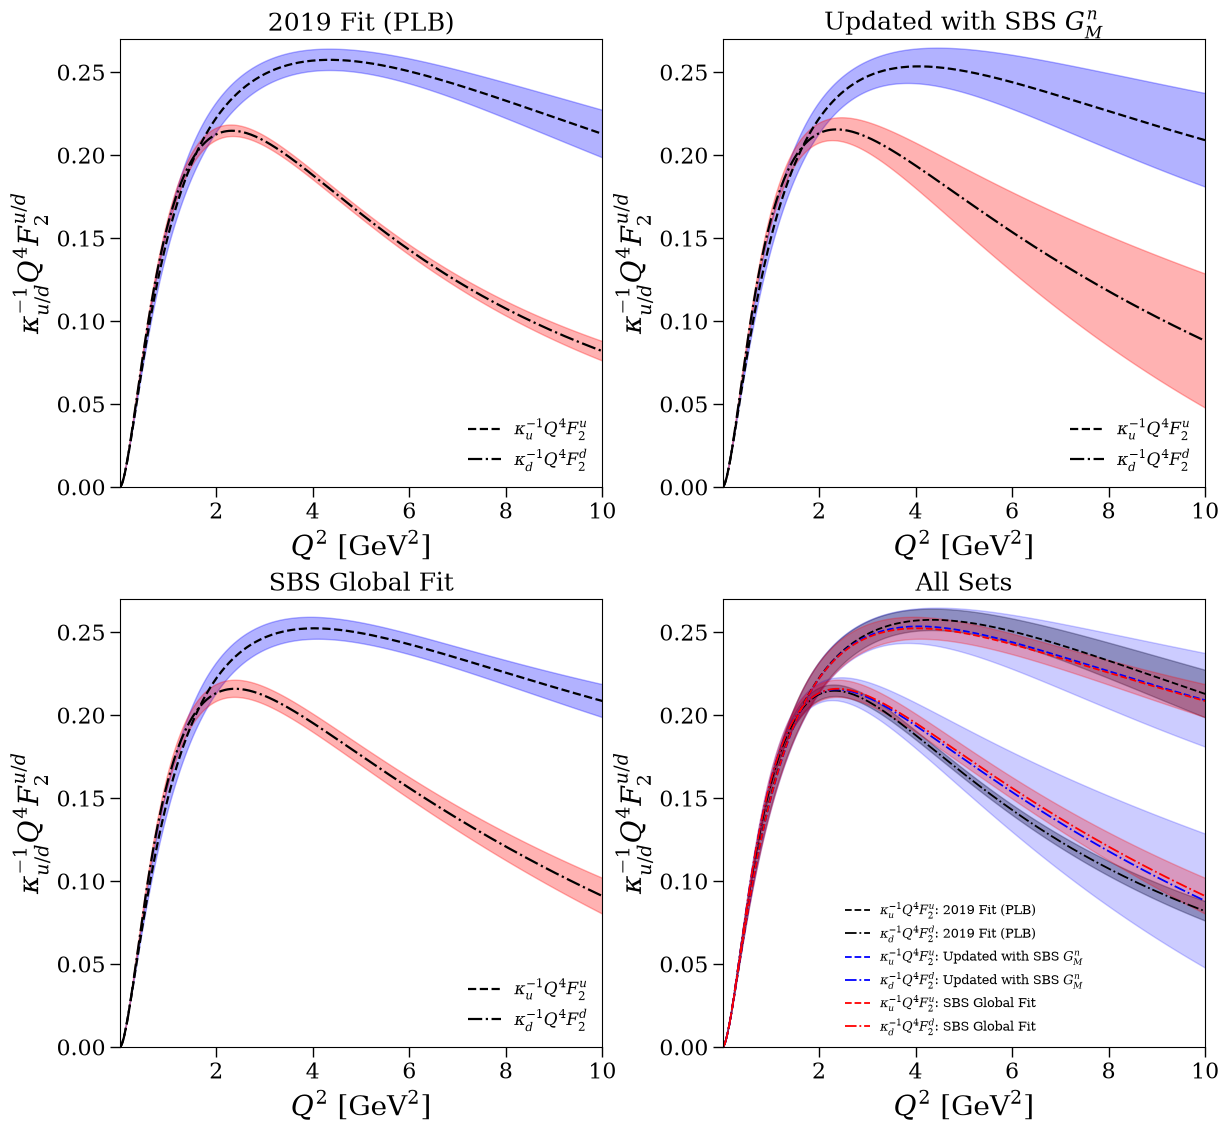

In [40]:
## kappa^{-1} Q^4 F2u/F2d (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = 0.
ymax1 = 0.27
Q2plot1 = 10

com1u = r'$\kappa_u^{-1} Q^4 F_2^u$: 2019 Fit (PLB)'
com1d = r'$\kappa_d^{-1} Q^4 F_2^d$: 2019 Fit (PLB)'
com2u = r'$\kappa_u^{-1} Q^4 F_2^u$: Updated with SBS $G_M^n$'
com2d = r'$\kappa_d^{-1} Q^4 F_2^d$: Updated with SBS $G_M^n$'
com3u = r'$\kappa_u^{-1} Q^4 F_2^u$: SBS Global Fit'
com3d = r'$\kappa_d^{-1} Q^4 F_2^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F2u_rat, 'k--', linewidth=1.6, label=r'$\kappa_u^{-1} Q^4 F_2^u$')
ax[0,0].fill_between(Q2, F2u_rat-dF2u_rat, F2u_rat+dF2u_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F2d_rat, 'k-.', linewidth=1.6, label=r'$\kappa_d^{-1} Q^4 F_2^d$')
ax[0,0].fill_between(Q2, F2d_rat-dF2d_rat, F2d_rat+dF2d_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F2u_rat_set2, 'k--', linewidth=1.6, label=r'$\kappa_u^{-1} Q^4 F_2^u$')
ax[0,1].fill_between(Q2, F2u_rat_set2-dF2u_rat_set2, F2u_rat_set2+dF2u_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F2d_rat_set2, 'k-.', linewidth=1.6, label=r'$\kappa_d^{-1} Q^4 F_2^d$')
ax[0,1].fill_between(Q2, F2d_rat_set2-dF2d_rat_set2, F2d_rat_set2+dF2d_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F2u_rat_set3, 'k--', linewidth=1.6, label=r'$\kappa_u^{-1} Q^4 F_2^u$')
ax[1,0].fill_between(Q2, F2u_rat_set3-dF2u_rat_set3, F2u_rat_set3+dF2u_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F2d_rat_set3, 'k-.', linewidth=1.6, label=r'$\kappa_d^{-1} Q^4 F_2^d$')
ax[1,0].fill_between(Q2, F2d_rat_set3-dF2d_rat_set3, F2d_rat_set3+dF2d_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F2u_rat, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F2u_rat-dF2u_rat, F2u_rat+dF2u_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F2d_rat, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F2d_rat-dF2d_rat, F2d_rat+dF2d_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F2u_rat_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F2u_rat_set2-dF2u_rat_set2, F2u_rat_set2+dF2u_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F2d_rat_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F2d_rat_set2-dF2d_rat_set2, F2d_rat_set2+dF2d_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F2u_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F2u_rat_set3-dF2u_rat_set3, F2u_rat_set3+dF2u_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F2d_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F2d_rat_set3-dF2d_rat_set3, F2d_rat_set3+dF2d_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel(r'$\kappa_{u/d}^{-1} Q^4 F_2^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F2rat_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F2rat_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F2rat_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


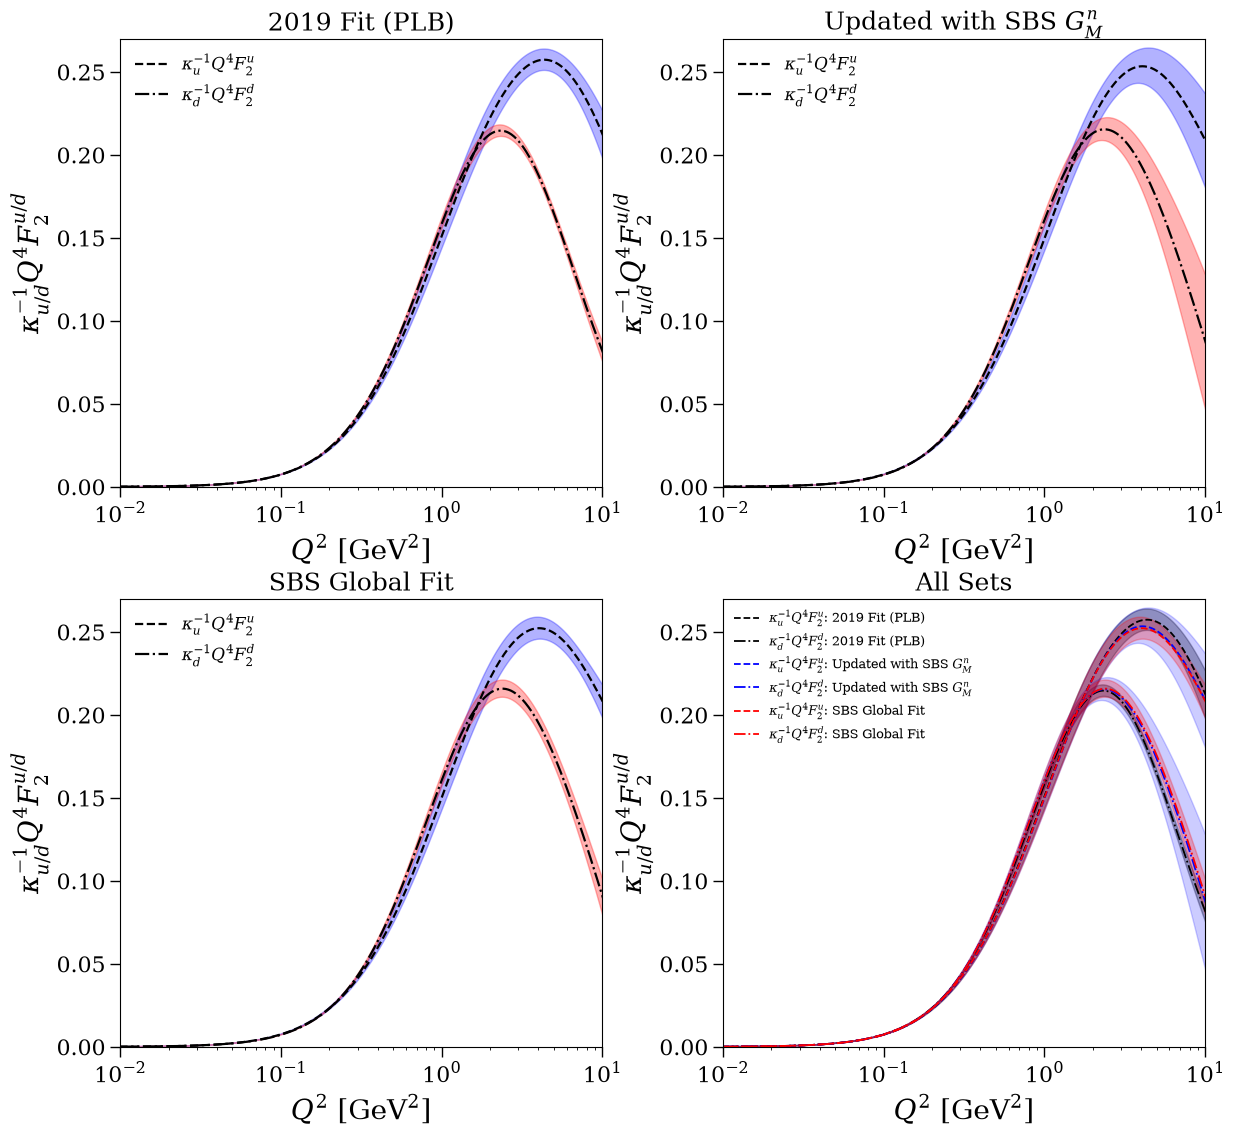

In [41]:
## kappa^{-1} Q^4 F2u/F2d (log Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = 0.
ymax1 = 0.27
Q2plot1 = 10

com1u = r'$\kappa_u^{-1} Q^4 F_2^u$: 2019 Fit (PLB)'
com1d = r'$\kappa_d^{-1} Q^4 F_2^d$: 2019 Fit (PLB)'
com2u = r'$\kappa_u^{-1} Q^4 F_2^u$: Updated with SBS $G_M^n$'
com2d = r'$\kappa_d^{-1} Q^4 F_2^d$: Updated with SBS $G_M^n$'
com3u = r'$\kappa_u^{-1} Q^4 F_2^u$: SBS Global Fit'
com3d = r'$\kappa_d^{-1} Q^4 F_2^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F2u_rat, 'k--', linewidth=1.6, label=r'$\kappa_u^{-1} Q^4 F_2^u$')
ax[0,0].fill_between(Q2, F2u_rat-dF2u_rat, F2u_rat+dF2u_rat, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F2d_rat, 'k-.', linewidth=1.6, label=r'$\kappa_d^{-1} Q^4 F_2^d$')
ax[0,0].fill_between(Q2, F2d_rat-dF2d_rat, F2d_rat+dF2d_rat, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F2u_rat_set2, 'k--', linewidth=1.6, label=r'$\kappa_u^{-1} Q^4 F_2^u$')
ax[0,1].fill_between(Q2, F2u_rat_set2-dF2u_rat_set2, F2u_rat_set2+dF2u_rat_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F2d_rat_set2, 'k-.', linewidth=1.6, label=r'$\kappa_d^{-1} Q^4 F_2^d$')
ax[0,1].fill_between(Q2, F2d_rat_set2-dF2d_rat_set2, F2d_rat_set2+dF2d_rat_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F2u_rat_set3, 'k--', linewidth=1.6, label=r'$\kappa_u^{-1} Q^4 F_2^u$')
ax[1,0].fill_between(Q2, F2u_rat_set3-dF2u_rat_set3, F2u_rat_set3+dF2u_rat_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F2d_rat_set3, 'k-.', linewidth=1.6, label=r'$\kappa_d^{-1} Q^4 F_2^d$')
ax[1,0].fill_between(Q2, F2d_rat_set3-dF2d_rat_set3, F2d_rat_set3+dF2d_rat_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F2u_rat, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F2u_rat-dF2u_rat, F2u_rat+dF2u_rat, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F2d_rat, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F2d_rat-dF2d_rat, F2d_rat+dF2d_rat, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F2u_rat_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F2u_rat_set2-dF2u_rat_set2, F2u_rat_set2+dF2u_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F2d_rat_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F2d_rat_set2-dF2d_rat_set2, F2d_rat_set2+dF2d_rat_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F2u_rat_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F2u_rat_set3-dF2u_rat_set3, F2u_rat_set3+dF2u_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F2d_rat_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F2d_rat_set3-dF2d_rat_set3, F2d_rat_set3+dF2d_rat_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='upper left', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel(r'$\kappa_{u/d}^{-1} Q^4 F_2^{u/d}$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F2rat_log_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F2rat_log_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F2rat_log_4panel.eps', bbox_inches='tight')

## $F_1^{u/d}/F_2^{u/d}$ and $F_{1/2}^{u}/F_{1/2}^{d}$

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


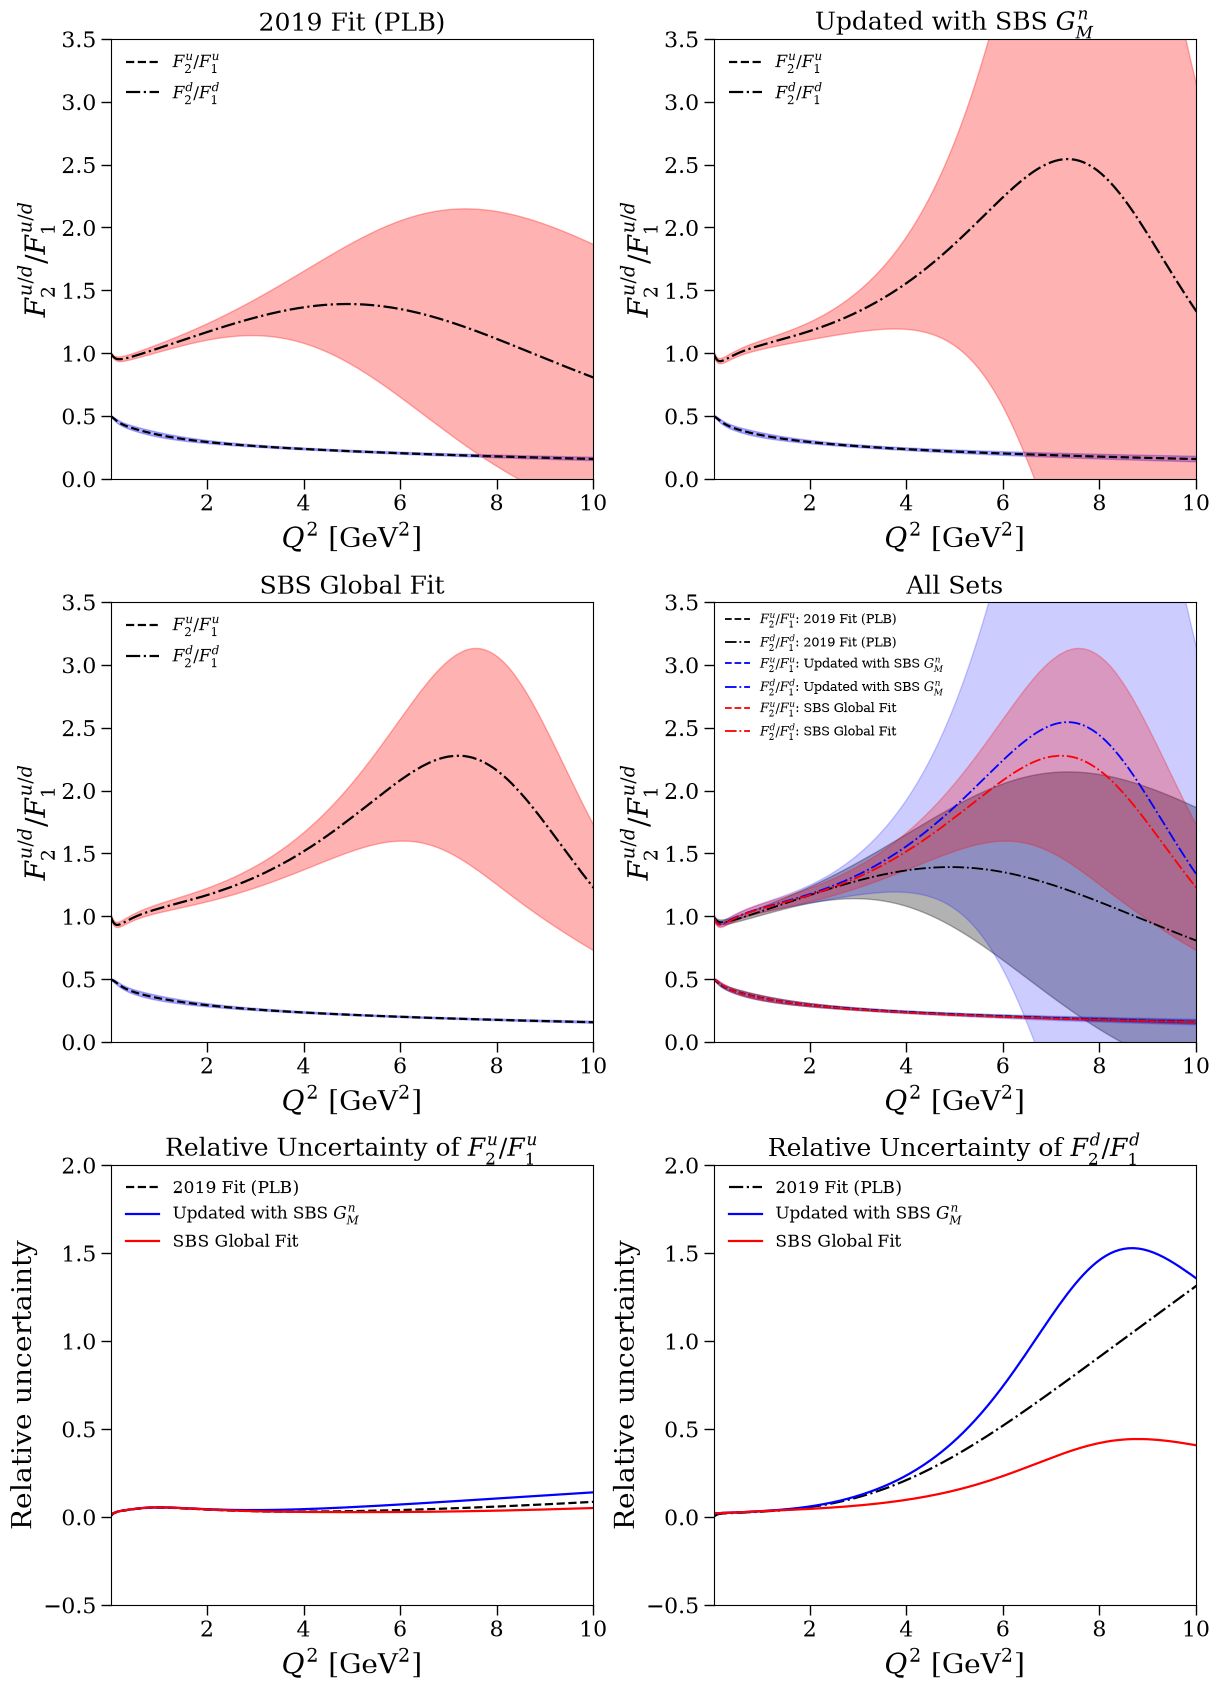

In [42]:
## (F2/F1)u/(F2/F1)d (vs Q2; 6 panels)
ymin1 = 0.
ymax1 = 3.5
Q2plot1 = 10

com1u = r'$F_2^u/F_1^u$: 2019 Fit (PLB)'
com1d = r'$F_2^d/F_1^d$: 2019 Fit (PLB)'
com2u = r'$F_2^u/F_1^u$: Updated with SBS $G_M^n$'
com2d = r'$F_2^d/F_1^d$: Updated with SBS $G_M^n$'
com3u = r'$F_2^u/F_1^u$: SBS Global Fit'
com3d = r'$F_2^d/F_1^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=3, ncols=2, figsize=(14,18))
f1.subplots_adjust(bottom=0.08, top=0.95, hspace=0.28, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1F2u, 'k--', linewidth=1.6, label=r'$F_2^u/F_1^u$')
ax[0,0].fill_between(Q2, F1F2u-dF1F2u, F1F2u+dF1F2u, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F1F2d, 'k-.', linewidth=1.6, label=r'$F_2^d/F_1^d$')
ax[0,0].fill_between(Q2, F1F2d-dF1F2d, F1F2d+dF1F2d, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1F2u_set2, 'k--', linewidth=1.6, label=r'$F_2^u/F_1^u$')
ax[0,1].fill_between(Q2, F1F2u_set2-dF1F2u_set2, F1F2u_set2+dF1F2u_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F1F2d_set2, 'k-.', linewidth=1.6, label=r'$F_2^d/F_1^d$')
ax[0,1].fill_between(Q2, F1F2d_set2-dF1F2d_set2, F1F2d_set2+dF1F2d_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1F2u_set3, 'k--', linewidth=1.6, label=r'$F_2^u/F_1^u$')
ax[1,0].fill_between(Q2, F1F2u_set3-dF1F2u_set3, F1F2u_set3+dF1F2u_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F1F2d_set3, 'k-.', linewidth=1.6, label=r'$F_2^d/F_1^d$')
ax[1,0].fill_between(Q2, F1F2d_set3-dF1F2d_set3, F1F2d_set3+dF1F2d_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1F2u, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F1F2u-dF1F2u, F1F2u+dF1F2u, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F1F2d, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F1F2d-dF1F2d, F1F2d+dF1F2d, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1F2u_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F1F2u_set2-dF1F2u_set2, F1F2u_set2+dF1F2u_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F1F2d_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F1F2d_set2-dF1F2d_set2, F1F2d_set2+dF1F2d_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1F2u_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F1F2u_set3-dF1F2u_set3, F1F2u_set3+dF1F2u_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F1F2d_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F1F2d_set3-dF1F2d_set3, F1F2d_set3+dF1F2d_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='upper left', fontsize=9, frameon=False)

# ============================================================
# Panel (2,0): relative uncertainty of u
# ============================================================
#########relative uncertainty of u{{{
ax[2,0].plot(Q2, dF1F2u/F1F2u, 'k--', linewidth=1.6, label='2019 Fit (PLB)')
ax[2,0].plot(Q2, dF1F2u_set2/F1F2u_set2, 'b-', linewidth=1.6, label=r'Updated with SBS $G_M^n$')
ax[2,0].plot(Q2, dF1F2u_set3/F1F2u_set3, 'r-', linewidth=1.6, label='SBS Global Fit')
#}}}
ax[2,0].set_title(r'Relative Uncertainty of $F_2^u/F_1^u$', fontsize=18)
ax[2,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (2,1): relative uncertainty of d
# ============================================================
#########relative uncertainty of d{{{
ax[2,1].plot(Q2, dF1F2d/F1F2d, 'k-.', linewidth=1.6, label='2019 Fit (PLB)')
ax[2,1].plot(Q2, dF1F2d_set2/F1F2d_set2, 'b-', linewidth=1.6, label=r'Updated with SBS $G_M^n$')
ax[2,1].plot(Q2, dF1F2d_set3/F1F2d_set3, 'r-', linewidth=1.6, label='SBS Global Fit')
#}}}
ax[2,1].set_title(r'Relative Uncertainty of $F_2^d/F_1^d$', fontsize=18)
ax[2,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Common axis formatting for top four panels
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel(r'$F_2^{u/d}/F_1^{u/d}$', fontsize=20)
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20)
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

# ============================================================
# Axis formatting for bottom panels
# ============================================================
for c in range(0, 2):
    ax[2,c].set_xlim(Q2_min, Q2plot1)
    ax[2,c].set_ylim(-0.5, 2)
    ax[2,c].set_ylabel('Relative uncertainty', fontsize=20)
    ax[2,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20)
    ax[2,c].xaxis.set_tick_params(width=1, length=7)
    ax[2,c].yaxis.set_tick_params(width=1, length=7)
    ax[2,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1F2_6panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1F2_6panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1F2_6panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


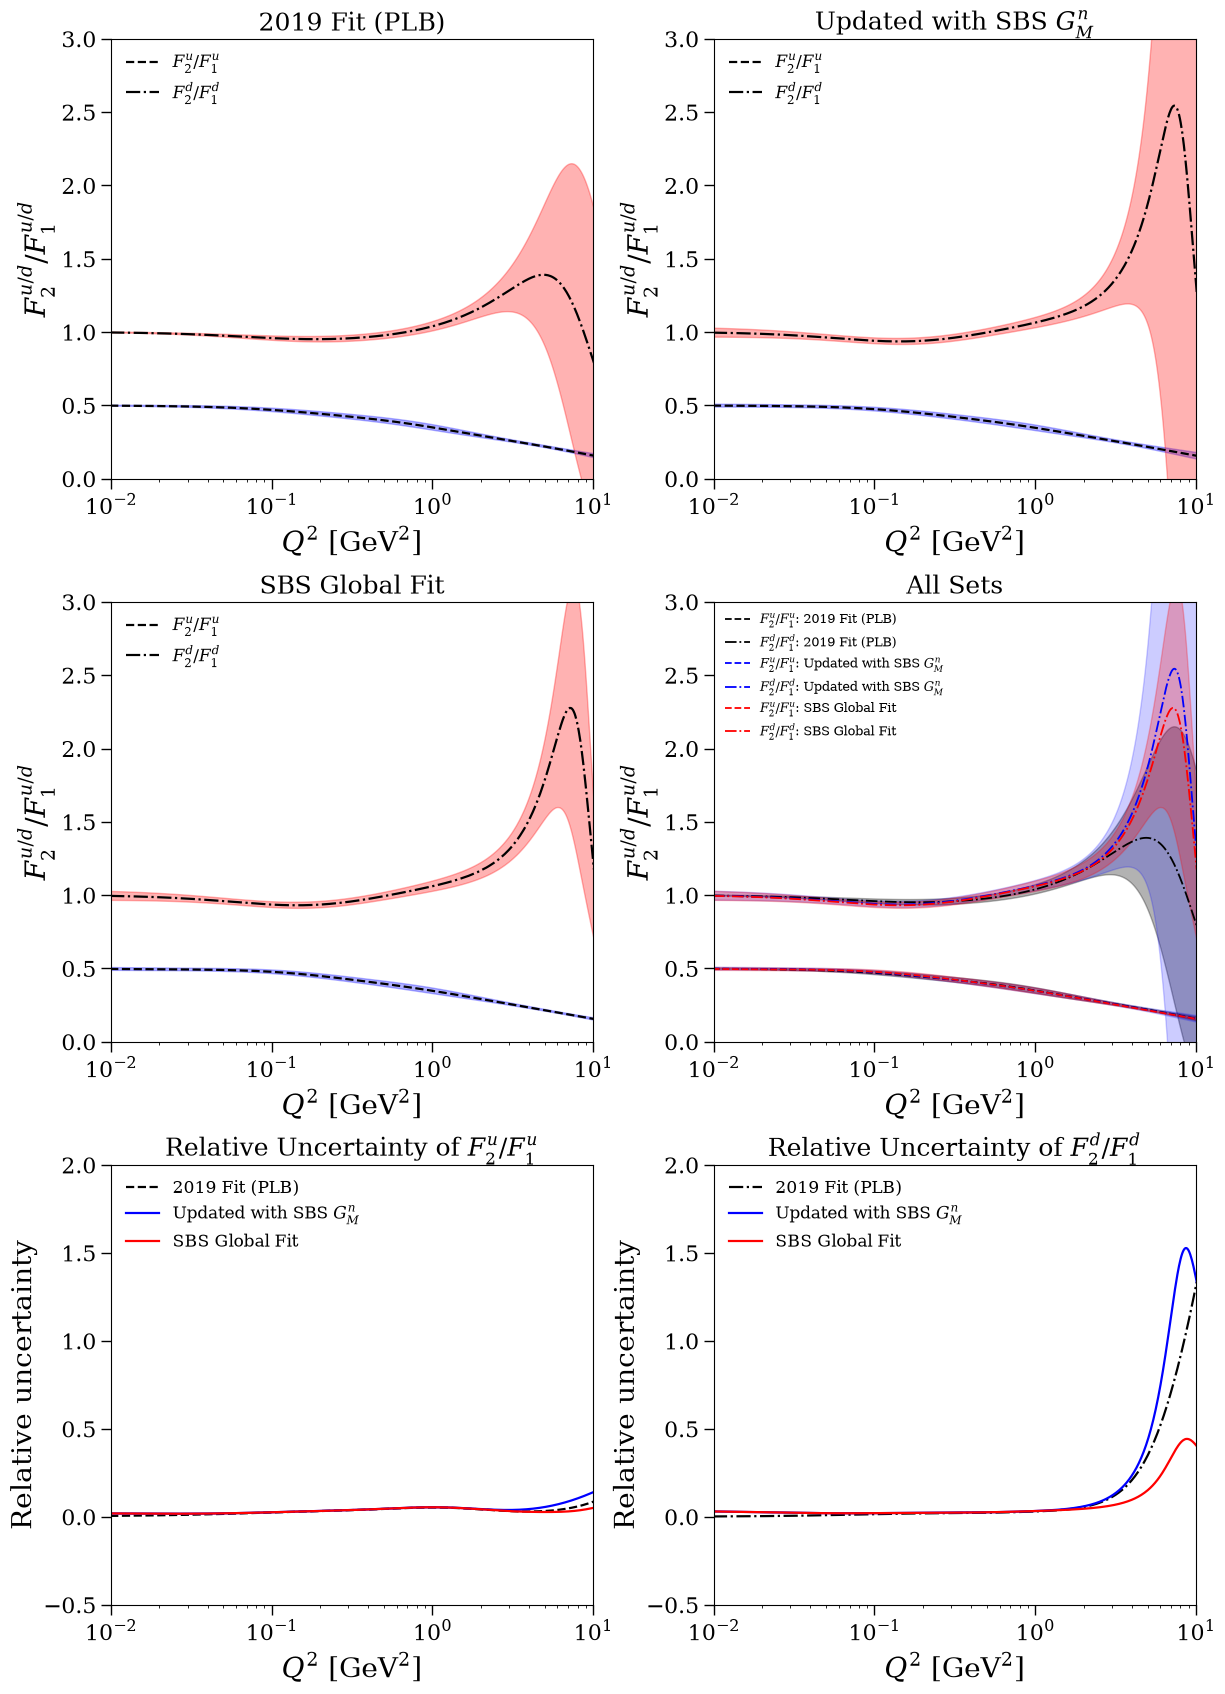

In [43]:
## (F2/F1)u/(F2/F1)d (log Q2; 6 panels)
ymin1 = 0.0
ymax1 = 3.0
Q2plot1 = 10

com1u = r'$F_2^u/F_1^u$: 2019 Fit (PLB)'
com1d = r'$F_2^d/F_1^d$: 2019 Fit (PLB)'
com2u = r'$F_2^u/F_1^u$: Updated with SBS $G_M^n$'
com2d = r'$F_2^d/F_1^d$: Updated with SBS $G_M^n$'
com3u = r'$F_2^u/F_1^u$: SBS Global Fit'
com3d = r'$F_2^d/F_1^d$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=3, ncols=2, figsize=(14,18))
f1.subplots_adjust(bottom=0.08, top=0.95, hspace=0.28, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1F2u, 'k--', linewidth=1.6, label=r'$F_2^u/F_1^u$')
ax[0,0].fill_between(Q2, F1F2u-dF1F2u, F1F2u+dF1F2u, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F1F2d, 'k-.', linewidth=1.6, label=r'$F_2^d/F_1^d$')
ax[0,0].fill_between(Q2, F1F2d-dF1F2d, F1F2d+dF1F2d, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1F2u_set2, 'k--', linewidth=1.6, label=r'$F_2^u/F_1^u$')
ax[0,1].fill_between(Q2, F1F2u_set2-dF1F2u_set2, F1F2u_set2+dF1F2u_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F1F2d_set2, 'k-.', linewidth=1.6, label=r'$F_2^d/F_1^d$')
ax[0,1].fill_between(Q2, F1F2d_set2-dF1F2d_set2, F1F2d_set2+dF1F2d_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1F2u_set3, 'k--', linewidth=1.6, label=r'$F_2^u/F_1^u$')
ax[1,0].fill_between(Q2, F1F2u_set3-dF1F2u_set3, F1F2u_set3+dF1F2u_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F1F2d_set3, 'k-.', linewidth=1.6, label=r'$F_2^d/F_1^d$')
ax[1,0].fill_between(Q2, F1F2d_set3-dF1F2d_set3, F1F2d_set3+dF1F2d_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1F2u, 'k--', linewidth=1.3, label=com1u)
ax[1,1].fill_between(Q2, F1F2u-dF1F2u, F1F2u+dF1F2u, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F1F2d, 'k-.', linewidth=1.3, label=com1d)
ax[1,1].fill_between(Q2, F1F2d-dF1F2d, F1F2d+dF1F2d, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1F2u_set2, 'b--', linewidth=1.3, label=com2u)
ax[1,1].fill_between(Q2, F1F2u_set2-dF1F2u_set2, F1F2u_set2+dF1F2u_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F1F2d_set2, 'b-.', linewidth=1.3, label=com2d)
ax[1,1].fill_between(Q2, F1F2d_set2-dF1F2d_set2, F1F2d_set2+dF1F2d_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1F2u_set3, 'r--', linewidth=1.3, label=com3u)
ax[1,1].fill_between(Q2, F1F2u_set3-dF1F2u_set3, F1F2u_set3+dF1F2u_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F1F2d_set3, 'r-.', linewidth=1.3, label=com3d)
ax[1,1].fill_between(Q2, F1F2d_set3-dF1F2d_set3, F1F2d_set3+dF1F2d_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='upper left', fontsize=9, frameon=False)

# ============================================================
# Panel (2,0): relative uncertainty of u
# ============================================================
#########relative uncertainty of u{{{
ax[2,0].plot(Q2, dF1F2u/F1F2u, 'k--', linewidth=1.6, label='2019 Fit (PLB)')
ax[2,0].plot(Q2, dF1F2u_set2/F1F2u_set2, 'b-', linewidth=1.6, label=r'Updated with SBS $G_M^n$')
ax[2,0].plot(Q2, dF1F2u_set3/F1F2u_set3, 'r-', linewidth=1.6, label='SBS Global Fit')
#}}}
ax[2,0].set_title(r'Relative Uncertainty of $F_2^u/F_1^u$', fontsize=18)
ax[2,0].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Panel (2,1): relative uncertainty of d
# ============================================================
#########relative uncertainty of d{{{
ax[2,1].plot(Q2, dF1F2d/F1F2d, 'k-.', linewidth=1.6, label='2019 Fit (PLB)')
ax[2,1].plot(Q2, dF1F2d_set2/F1F2d_set2, 'b-', linewidth=1.6, label=r'Updated with SBS $G_M^n$')
ax[2,1].plot(Q2, dF1F2d_set3/F1F2d_set3, 'r-', linewidth=1.6, label='SBS Global Fit')
#}}}
ax[2,1].set_title(r'Relative Uncertainty of $F_2^d/F_1^d$', fontsize=18)
ax[2,1].legend(loc='upper left', fontsize=12, frameon=False)

# ============================================================
# Common axis formatting for top four panels
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel(r'$F_2^{u/d}/F_1^{u/d}$', fontsize=20)
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20)
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

# ============================================================
# Axis formatting for bottom panels
# ============================================================
for c in range(0, 2):
    ax[2,c].set_xlim(Q2_min, Q2plot1)
    ax[2,c].set_ylim(-0.5, 2)
    ax[2,c].set_xscale('log')
    ax[2,c].set_ylabel('Relative uncertainty', fontsize=20)
    ax[2,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20)
    ax[2,c].xaxis.set_tick_params(width=1, length=7)
    ax[2,c].yaxis.set_tick_params(width=1, length=7)
    ax[2,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1F2_log_6panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1F2_log_6panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1F2_log_6panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


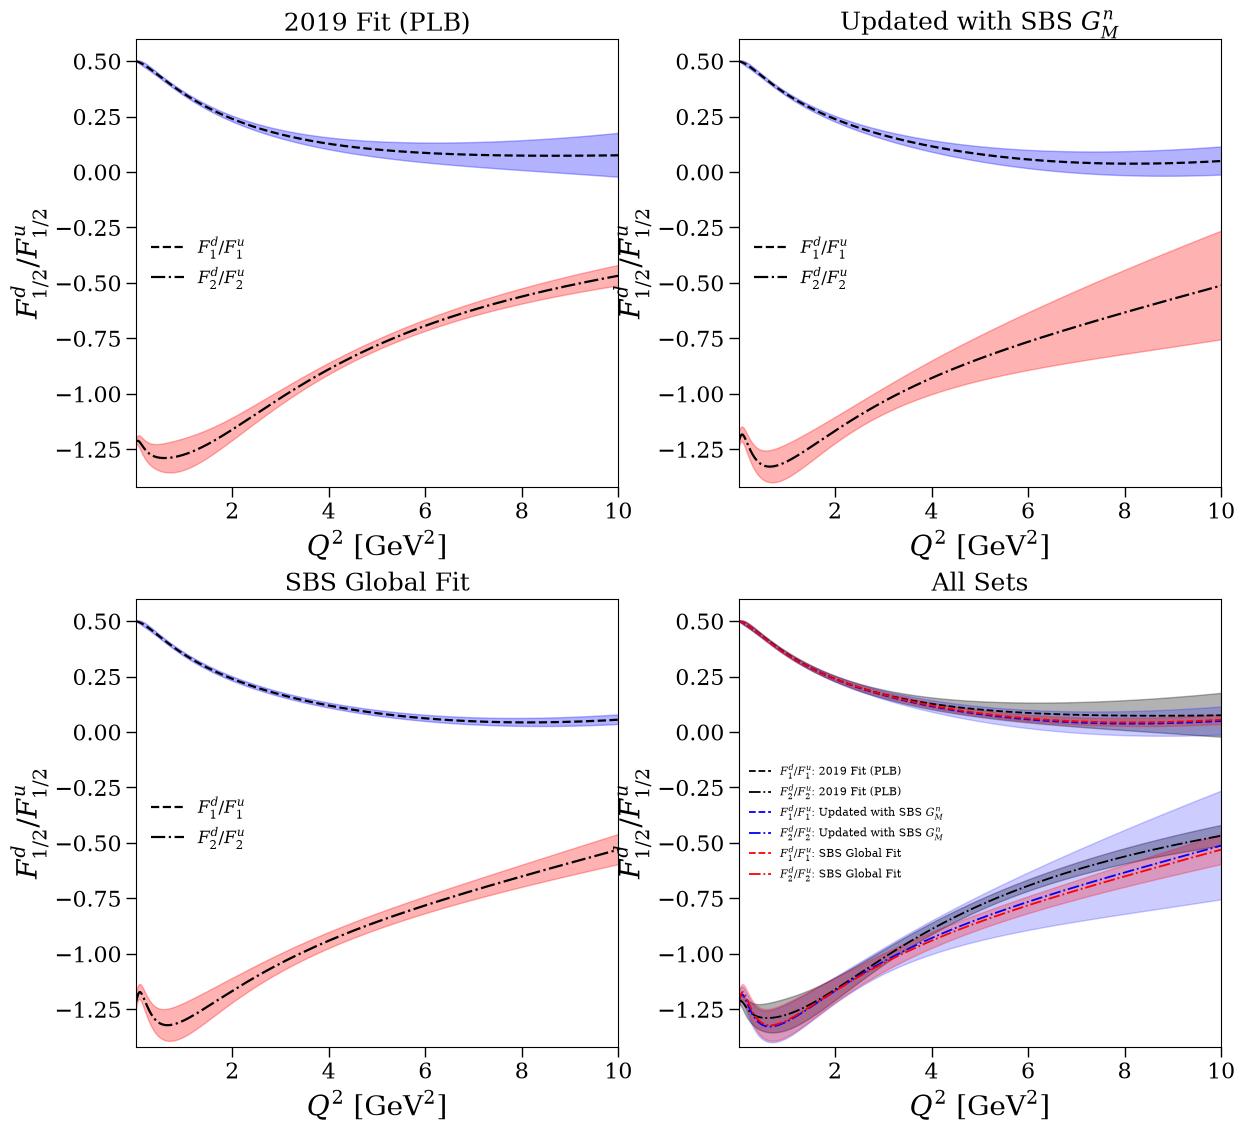

In [44]:
## F1d/F1u and F2d/F2u (vs Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = -1.42
ymax1 = 0.6
Q2plot1 = 10

com1f1 = r'$F_1^d/F_1^u$: 2019 Fit (PLB)'
com1f2 = r'$F_2^d/F_2^u$: 2019 Fit (PLB)'
com2f1 = r'$F_1^d/F_1^u$: Updated with SBS $G_M^n$'
com2f2 = r'$F_2^d/F_2^u$: Updated with SBS $G_M^n$'
com3f1 = r'$F_1^d/F_1^u$: SBS Global Fit'
com3f2 = r'$F_2^d/F_2^u$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1uF1d, 'k--', linewidth=1.6, label=r'$F_1^d/F_1^u$')
ax[0,0].fill_between(Q2, F1uF1d-dF1uF1d, F1uF1d+dF1uF1d, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F2uF2d, 'k-.', linewidth=1.6, label=r'$F_2^d/F_2^u$')
ax[0,0].fill_between(Q2, F2uF2d-dF2uF2d, F2uF2d+dF2uF2d, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='center left', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1uF1d_set2, 'k--', linewidth=1.6, label=r'$F_1^d/F_1^u$')
ax[0,1].fill_between(Q2, F1uF1d_set2-dF1uF1d_set2, F1uF1d_set2+dF1uF1d_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F2uF2d_set2, 'k-.', linewidth=1.6, label=r'$F_2^d/F_2^u$')
ax[0,1].fill_between(Q2, F2uF2d_set2-dF2uF2d_set2, F2uF2d_set2+dF2uF2d_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='center left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1uF1d_set3, 'k--', linewidth=1.6, label=r'$F_1^d/F_1^u$')
ax[1,0].fill_between(Q2, F1uF1d_set3-dF1uF1d_set3, F1uF1d_set3+dF1uF1d_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F2uF2d_set3, 'k-.', linewidth=1.6, label=r'$F_2^d/F_2^u$')
ax[1,0].fill_between(Q2, F2uF2d_set3-dF2uF2d_set3, F2uF2d_set3+dF2uF2d_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='center left', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1uF1d, 'k--', linewidth=1.3, label=com1f1)
ax[1,1].fill_between(Q2, F1uF1d-dF1uF1d, F1uF1d+dF1uF1d, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F2uF2d, 'k-.', linewidth=1.3, label=com1f2)
ax[1,1].fill_between(Q2, F2uF2d-dF2uF2d, F2uF2d+dF2uF2d, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1uF1d_set2, 'b--', linewidth=1.3, label=com2f1)
ax[1,1].fill_between(Q2, F1uF1d_set2-dF1uF1d_set2, F1uF1d_set2+dF1uF1d_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F2uF2d_set2, 'b-.', linewidth=1.3, label=com2f2)
ax[1,1].fill_between(Q2, F2uF2d_set2-dF2uF2d_set2, F2uF2d_set2+dF2uF2d_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1uF1d_set3, 'r--', linewidth=1.3, label=com3f1)
ax[1,1].fill_between(Q2, F1uF1d_set3-dF1uF1d_set3, F1uF1d_set3+dF1uF1d_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F2uF2d_set3, 'r-.', linewidth=1.3, label=com3f2)
ax[1,1].fill_between(Q2, F2uF2d_set3-dF2uF2d_set3, F2uF2d_set3+dF2uF2d_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='center left', fontsize=8, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_ylabel(r'$F_{1/2}^d/F_{1/2}^u$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1F2_du_ratio_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1F2_du_ratio_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1F2_du_ratio_4panel.eps', bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


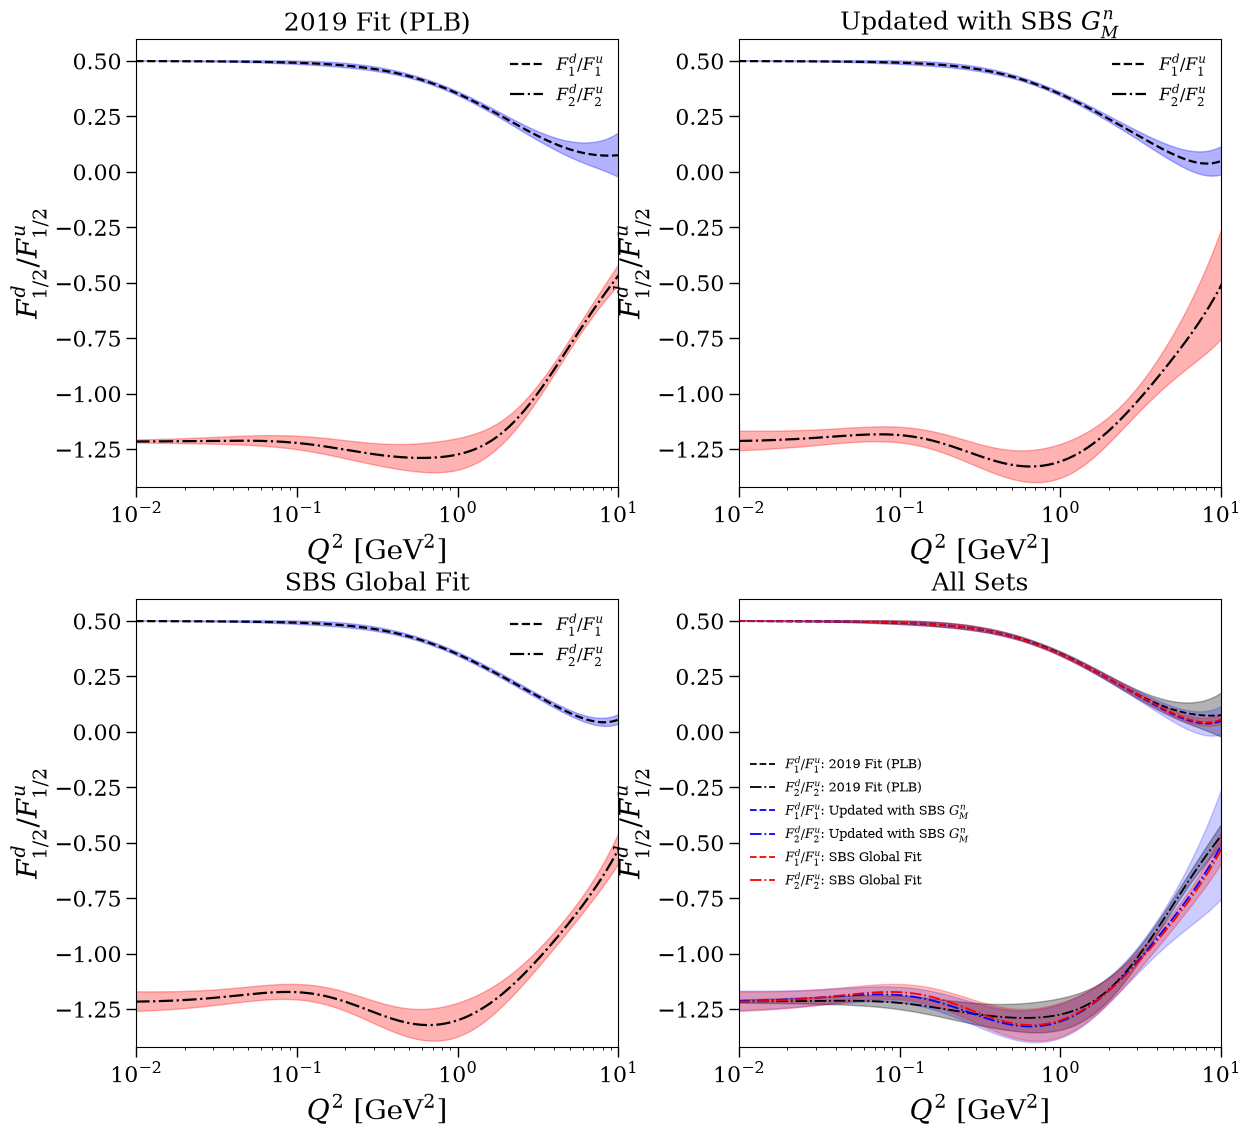

In [45]:
## F1d/F1u and F2d/F2u (log Q2; 4 panels in one page; overlay in bottom-right)
ymin1 = -1.42
ymax1 = 0.6
Q2plot1 = 10

com1f1 = r'$F_1^d/F_1^u$: 2019 Fit (PLB)'
com1f2 = r'$F_2^d/F_2^u$: 2019 Fit (PLB)'
com2f1 = r'$F_1^d/F_1^u$: Updated with SBS $G_M^n$'
com2f2 = r'$F_2^d/F_2^u$: Updated with SBS $G_M^n$'
com3f1 = r'$F_1^d/F_1^u$: SBS Global Fit'
com3f2 = r'$F_2^d/F_2^u$: SBS Global Fit'

font_prop = font_manager.FontProperties(size=12)
font_prop1 = font_manager.FontProperties(size=18)

f1, ax = plt.subplots(nrows=2, ncols=2, figsize=(14,12))
f1.subplots_adjust(bottom=0.10, top=0.94, hspace=0.25, wspace=0.25)

# ============================================================
# Panel (0,0): 2019 Fit (PLB)
# ============================================================
#########2019 Fit (PLB){{{
ax[0,0].plot(Q2, F1uF1d, 'k--', linewidth=1.6, label=r'$F_1^d/F_1^u$')
ax[0,0].fill_between(Q2, F1uF1d-dF1uF1d, F1uF1d+dF1uF1d, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,0].plot(Q2, F2uF2d, 'k-.', linewidth=1.6, label=r'$F_2^d/F_2^u$')
ax[0,0].fill_between(Q2, F2uF2d-dF2uF2d, F2uF2d+dF2uF2d, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,0].set_title('2019 Fit (PLB)', fontsize=18)
ax[0,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (0,1): Updated with SBS GMn
# ============================================================
#########Updated with SBS GMn{{{
ax[0,1].plot(Q2, F1uF1d_set2, 'k--', linewidth=1.6, label=r'$F_1^d/F_1^u$')
ax[0,1].fill_between(Q2, F1uF1d_set2-dF1uF1d_set2, F1uF1d_set2+dF1uF1d_set2, edgecolor='b', facecolor='b', alpha=0.30)

ax[0,1].plot(Q2, F2uF2d_set2, 'k-.', linewidth=1.6, label=r'$F_2^d/F_2^u$')
ax[0,1].fill_between(Q2, F2uF2d_set2-dF2uF2d_set2, F2uF2d_set2+dF2uF2d_set2, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[0,1].set_title(r'Updated with SBS $G_M^n$', fontsize=18)
ax[0,1].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,0): SBS Global Fit
# ============================================================
#########SBS Global Fit{{{
ax[1,0].plot(Q2, F1uF1d_set3, 'k--', linewidth=1.6, label=r'$F_1^d/F_1^u$')
ax[1,0].fill_between(Q2, F1uF1d_set3-dF1uF1d_set3, F1uF1d_set3+dF1uF1d_set3, edgecolor='b', facecolor='b', alpha=0.30)

ax[1,0].plot(Q2, F2uF2d_set3, 'k-.', linewidth=1.6, label=r'$F_2^d/F_2^u$')
ax[1,0].fill_between(Q2, F2uF2d_set3-dF2uF2d_set3, F2uF2d_set3+dF2uF2d_set3, edgecolor='r', facecolor='r', alpha=0.30)
#}}}
ax[1,0].set_title('SBS Global Fit', fontsize=18)
ax[1,0].legend(loc='best', fontsize=12, frameon=False)

# ============================================================
# Panel (1,1): overlay (all three sets)
# ============================================================
#########2019 Fit (PLB){{{
ax[1,1].plot(Q2, F1uF1d, 'k--', linewidth=1.3, label=com1f1)
ax[1,1].fill_between(Q2, F1uF1d-dF1uF1d, F1uF1d+dF1uF1d, edgecolor='black', facecolor='black', alpha=0.30)

ax[1,1].plot(Q2, F2uF2d, 'k-.', linewidth=1.3, label=com1f2)
ax[1,1].fill_between(Q2, F2uF2d-dF2uF2d, F2uF2d+dF2uF2d, edgecolor='black', facecolor='black', alpha=0.30)
#}}}

#########Updated with SBS GMn{{{
ax[1,1].plot(Q2, F1uF1d_set2, 'b--', linewidth=1.3, label=com2f1)
ax[1,1].fill_between(Q2, F1uF1d_set2-dF1uF1d_set2, F1uF1d_set2+dF1uF1d_set2, edgecolor='b', facecolor='b', alpha=0.20)

ax[1,1].plot(Q2, F2uF2d_set2, 'b-.', linewidth=1.3, label=com2f2)
ax[1,1].fill_between(Q2, F2uF2d_set2-dF2uF2d_set2, F2uF2d_set2+dF2uF2d_set2, edgecolor='b', facecolor='b', alpha=0.20)
#}}}

#########SBS Global Fit{{{
ax[1,1].plot(Q2, F1uF1d_set3, 'r--', linewidth=1.3, label=com3f1)
ax[1,1].fill_between(Q2, F1uF1d_set3-dF1uF1d_set3, F1uF1d_set3+dF1uF1d_set3, edgecolor='r', facecolor='r', alpha=0.25)

ax[1,1].plot(Q2, F2uF2d_set3, 'r-.', linewidth=1.3, label=com3f2)
ax[1,1].fill_between(Q2, F2uF2d_set3-dF2uF2d_set3, F2uF2d_set3+dF2uF2d_set3, edgecolor='r', facecolor='r', alpha=0.25)
#}}}

ax[1,1].set_title('All Sets', fontsize=18)
ax[1,1].legend(loc='best', fontsize=9, frameon=False)

# ============================================================
# Common axis formatting
# ============================================================
for r in range(0, 2):
    for c in range(0, 2):
        ax[r,c].set_xlim(Q2_min, Q2plot1)
        ax[r,c].set_ylim(ymin1, ymax1)
        ax[r,c].set_xscale('log')
        ax[r,c].set_ylabel(r'$F_{1/2}^d/F_{1/2}^u$', fontsize=20) # label, y-axis
        ax[r,c].set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=20) # label, x-axis
        ax[r,c].xaxis.set_tick_params(width=1, length=7)
        ax[r,c].yaxis.set_tick_params(width=1, length=7)
        ax[r,c].tick_params(labelsize=16)

plt.savefig('Quarks_F1uF1d_log_4panel.pdf', bbox_inches='tight')
plt.savefig('Quarks_F1uF1d_log_4panel.png', bbox_inches='tight')
#plt.savefig('Quarks_F1uF1d_log_4panel.eps', bbox_inches='tight')